<a href="https://colab.research.google.com/github/AbdelrahmanBadwy/Dark-Net-Dataset-ML-DL/blob/main/Network_Security_Project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import gdown, shutil, os

In [ ]:
os.makedirs("Datasets", exist_ok=True)
dir = gdown.download(
        url = "https://drive.google.com/file/d/1xiKff5CXwZ74iKbMcoFk5I_9QCQn_-OY/view?usp=sharing",
        fuzzy=True, output="Datasets/Darknet.csv")


Downloading...
From: https://drive.google.com/uc?id=1xiKff5CXwZ74iKbMcoFk5I_9QCQn_-OY
To: /content/Datasets/Darknet.csv
100%|██████████| 73.3M/73.3M [00:00<00:00, 195MB/s]


In [ ]:
# import relevant libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline
import socket
import struct
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler


from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import TomekLinks

import warnings
warnings.filterwarnings('ignore')


In [ ]:
data = pd.read_csv('Datasets/Darknet.csv')

In [ ]:
data.head()

,Flow ID,Src IP,Src Port,Dst IP,Dst Port,Protocol,Timestamp,Flow Duration,Total Fwd Packet,Total Bwd packets,...,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min,Label,Label.1
0,10.152.152.11-216.58.220.99-57158-443-6,10.152.152.11,57158,216.58.220.99,443,6,24/07/2015 04:09:48 PM,229,1,1,...,0,0,0,0,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,Non-Tor,AUDIO-STREAMING
1,10.152.152.11-216.58.220.99-57159-443-6,10.152.152.11,57159,216.58.220.99,443,6,24/07/2015 04:09:48 PM,407,1,1,...,0,0,0,0,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,Non-Tor,AUDIO-STREAMING
2,10.152.152.11-216.58.220.99-57160-443-6,10.152.152.11,57160,216.58.220.99,443,6,24/07/2015 04:09:48 PM,431,1,1,...,0,0,0,0,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,Non-Tor,AUDIO-STREAMING
3,10.152.152.11-74.125.136.120-49134-443-6,10.152.152.11,49134,74.125.136.120,443,6,24/07/2015 04:09:48 PM,359,1,1,...,0,0,0,0,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,Non-Tor,AUDIO-STREAMING
4,10.152.152.11-173.194.65.127-34697-19305-6,10.152.152.11,34697,173.194.65.127,19305,6,24/07/2015 04:09:45 PM,10778451,591,400,...,0,0,0,0,1.437765e+15,3.117718e+06,1.437765e+15,1.437765e+15,Non-Tor,AUDIO-STREAMING


Some terms are mentionned in the dataset and need to be defiend:
* `Flow`:A network flow is a series of communications between two endpoints that are bounded by the opening and closing of the session
* `Packet`: In telecommunications and computer networking, a network packet is a formatted unit of data carried by a packet-switched network. A packet consists of control information and user data.
* `Payload`:In computing and telecommunications, the payload is the part of transmitted data that is the actual intended message.


In [ ]:
data.shape

(158616, 85)

In [ ]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 158616 entries, 0 to 158615
Data columns (total 85 columns):
 #   Column                      Non-Null Count   Dtype  
---  ------                      --------------   -----  
 0   Flow ID                     158616 non-null  object 
 1   Src IP                      158616 non-null  object 
 2   Src Port                    158616 non-null  int64  
 3   Dst IP                      158616 non-null  object 
 4   Dst Port                    158616 non-null  int64  
 5   Protocol                    158616 non-null  int64  
 6   Timestamp                   158616 non-null  object 
 7   Flow Duration               158616 non-null  int64  
 8   Total Fwd Packet            158616 non-null  int64  
 9   Total Bwd packets           158616 non-null  int64  
 10  Total Length of Fwd Packet  158616 non-null  int64  
 11  Total Length of Bwd Packet  158616 non-null  int64  
 12  Fwd Packet Length Max       158616 non-null  int64  
 13  Fwd Packet Len

In [ ]:
# Renaming the two target columns Label and Label.1
data.rename(columns = {'Label':'traffic', 'Label.1':'application'}, inplace = True)

## Recap
* In this part we found that the data has the shape of (141530, 85)
* 141530 rows
* 85 features
* It contains 6 categorical columns and 79 numerical columns
* We have two target columns which are Label and Label.1
* the two target columns were renamad respectively traffic and application

## Data Cleaning

In [ ]:
def show_missing(df):
    """Return a Pandas dataframe describing the contents of a source dataframe including missing values."""

    variables = []
    dtypes = []
    count = []
    unique = []
    missing = []
    infinity = []

    for item in df.columns:
        variables.append(item)
        dtypes.append(df[item].dtype)
        count.append(len(df[item]))
        unique.append(len(df[item].unique()))
        missing.append(df[item].isna().sum())
        if df[item].dtypes=='float64'or df[item].dtypes=='int64':
            infinity.append(np.isinf(df[item]).values.sum())
        else:
            infinity.append('not_supported')



    output = pd.DataFrame({
        'variable': variables,
        'dtype': dtypes,
        'count': count,
        'unique': unique,
        'missing': missing,
        'infinity':infinity

    })

    return output

In [ ]:
show_missing(data)

,variable,dtype,count,unique,missing,infinity
0,Flow ID,object,158616,79160,0,not_supported
1,Src IP,object,158616,4026,0,not_supported
2,Src Port,int64,158616,34524,0,0
3,Dst IP,object,158616,7553,0,not_supported
4,Dst Port,int64,158616,13346,0,0
...,...,...,...,...,...,...
80,Idle Std,float64,158616,51094,0,0
81,Idle Max,float64,158616,58226,0,0
82,Idle Min,float64,158616,58169,0,0
83,traffic,object,158616,4,0,not_supported


In [ ]:
table = show_missing(data)

In [ ]:
# data with infinity values
table.loc[(table['infinity']!=0) & (table['infinity']!='not_supported')]

,variable,dtype,count,unique,missing,infinity
20,Flow Bytes/s,float64,158616,75576,48,2
21,Flow Packets/s,float64,158616,84466,0,50


In [ ]:
# data with missing values
table.loc[(table['missing']!=0) ]

,variable,dtype,count,unique,missing,infinity
20,Flow Bytes/s,float64,158616,75576,48,2


### Removing missing and infinity values

In [ ]:
# Drop data with NaN values
data.dropna(axis=0 ,inplace=True)

In [ ]:
# Drop Infinity data

# Replace infinite updated data with nan
data.replace([np.inf, -np.inf], np.nan, inplace=True)
# Drop rows with NaN
data.dropna(inplace=True)

### Drop duplicates

In [ ]:
data = data.drop_duplicates()

In [ ]:
data.shape

(119562, 85)

In [ ]:
data.describe()

,Src Port,Dst Port,Protocol,Flow Duration,Total Fwd Packet,Total Bwd packets,Total Length of Fwd Packet,Total Length of Bwd Packet,Fwd Packet Length Max,Fwd Packet Length Min,...,Fwd Act Data Pkts,Fwd Seg Size Min,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min
count,119562.000000,119562.000000,119562.000000,1.195620e+05,119562.000000,119562.000000,1.195620e+05,1.195620e+05,119562.000000,119562.000000,...,119562.000000,119562.000000,119562.0,119562.0,119562.0,119562.0,1.195620e+05,1.195620e+05,1.195620e+05,1.195620e+05
mean,38339.805774,14328.978764,10.773799,2.027572e+07,160.949440,163.315752,1.152542e+05,1.369468e+05,203.162769,17.278742,...,100.972851,15.445911,0.0,0.0,0.0,0.0,6.603232e+14,5.378494e+13,6.881815e+14,5.598509e+14
std,19495.480859,20838.292467,5.514803,3.800140e+07,2505.268202,3675.695984,3.464760e+06,4.928046e+06,681.502538,31.230507,...,1635.104089,7.418281,0.0,0.0,0.0,0.0,7.028320e+14,1.935532e+14,7.229211e+14,7.048755e+14
min,0.000000,0.000000,0.000000,1.000000e+00,1.000000,0.000000,0.000000e+00,0.000000e+00,0.000000,0.000000,...,0.000000,0.000000,0.0,0.0,0.0,0.0,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
25%,30764.500000,53.000000,6.000000,9.050000e+02,1.000000,0.000000,0.000000e+00,0.000000e+00,0.000000,0.000000,...,0.000000,8.000000,0.0,0.0,0.0,0.0,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
50%,43536.000000,443.000000,6.000000,4.112905e+05,2.000000,1.000000,4.400000e+01,2.000000e+01,34.000000,0.000000,...,0.000000,20.000000,0.0,0.0,0.0,0.0,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
75%,53540.750000,32558.750000,17.000000,1.066277e+07,4.000000,3.000000,2.020000e+02,2.340000e+02,90.000000,33.000000,...,2.000000,20.000000,0.0,0.0,0.0,0.0,1.438014e+15,7.586270e+06,1.456253e+15,1.438011e+15
max,65534.000000,65535.000000,17.000000,1.200000e+08,238161.000000,470862.000000,7.693074e+08,6.704287e+08,64240.000000,1350.000000,...,113325.000000,44.000000,0.0,0.0,0.0,0.0,1.456417e+15,1.029836e+15,1.456417e+15,1.456417e+15


## Recap
* In this part we search for missing and infinity values
* The `Flow Bytes/s` columns has 47 missing and 2 infinity values
* The `Flow Packets/s` columns has 49 missing values
* The approach chosen to deal with missing values was to delete them
* Latter on and depending on the model accuracy we will try imputing this missing and infinity values

## Data visualisations

In [ ]:
!pip install sweetviz

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 15.1/15.1 MB 30.5 MB/s eta 0:00:00


                                             |          | [  0%]   00:00 -> (? left)


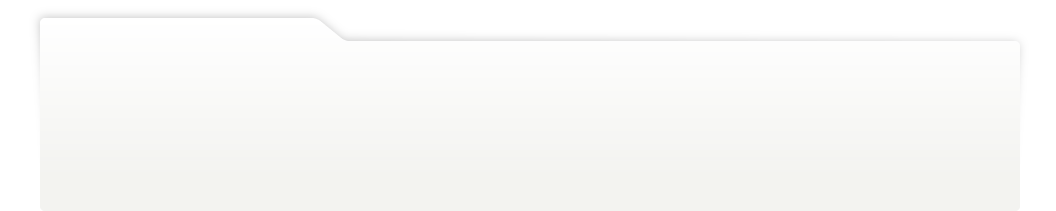
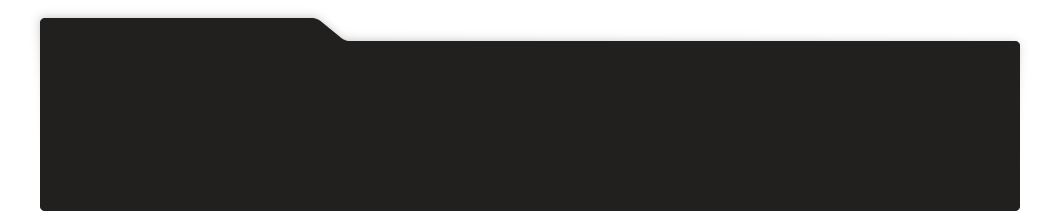
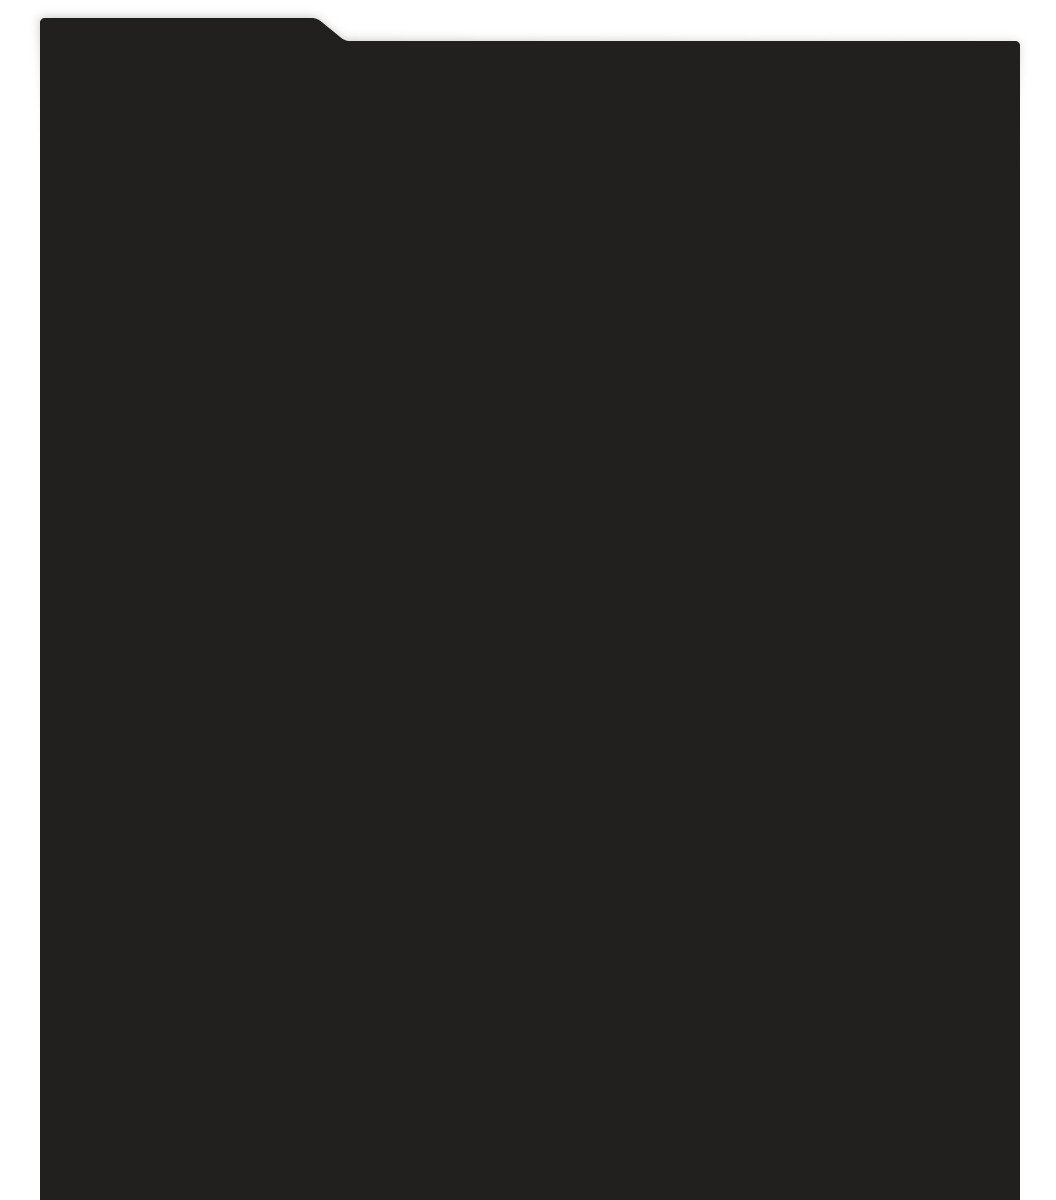
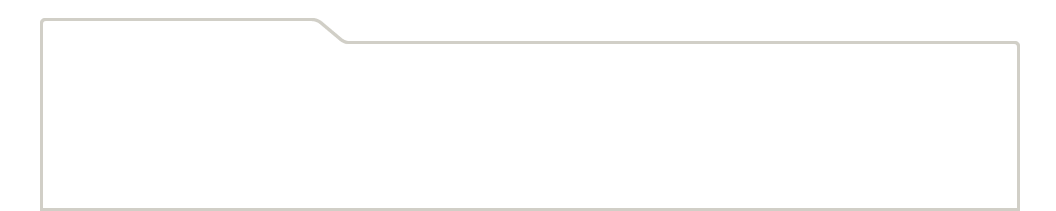
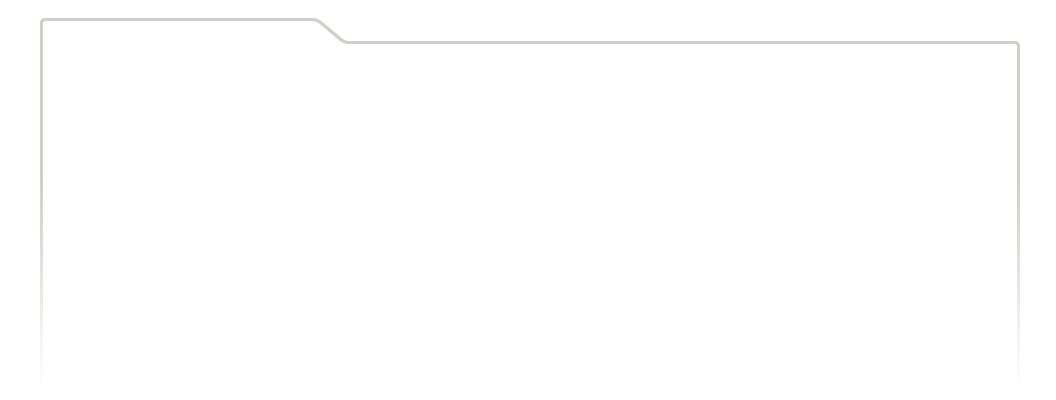
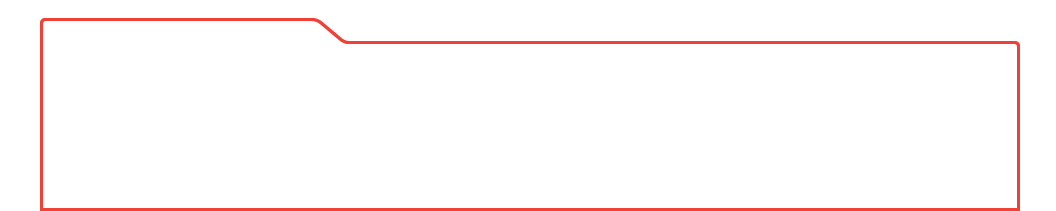
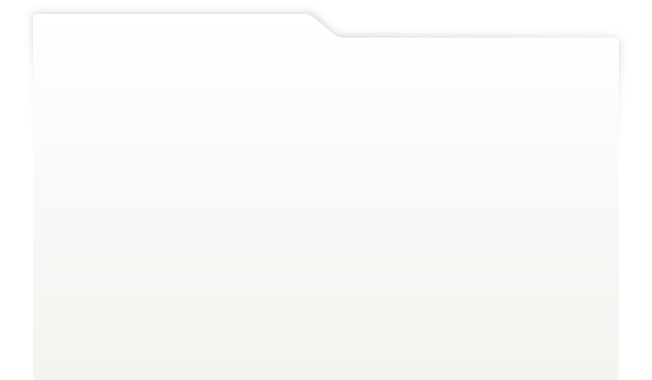
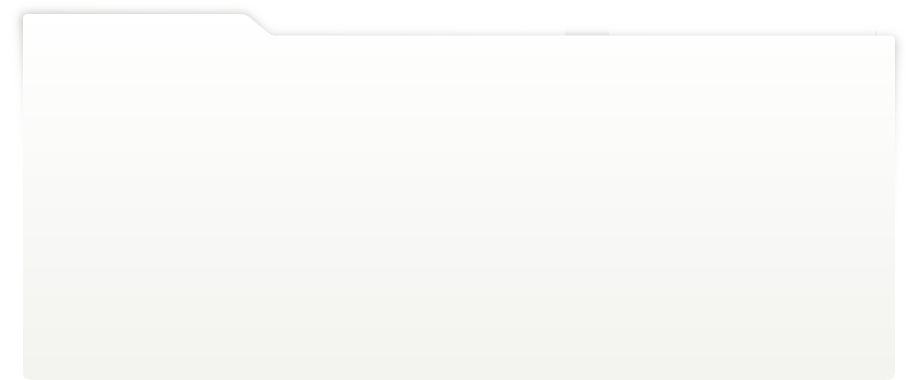
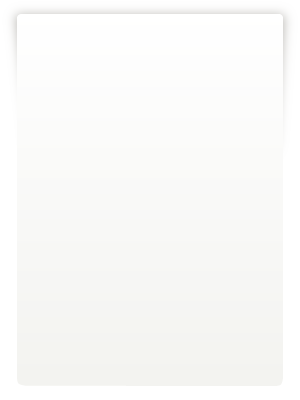
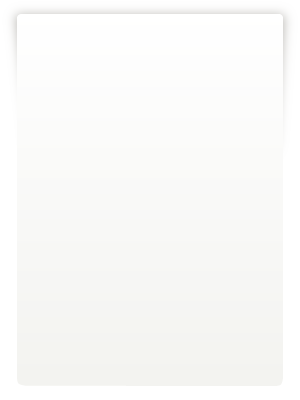
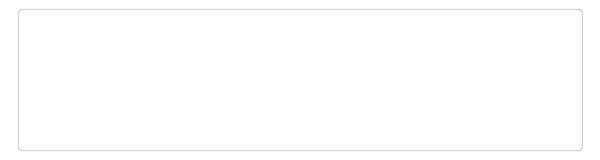
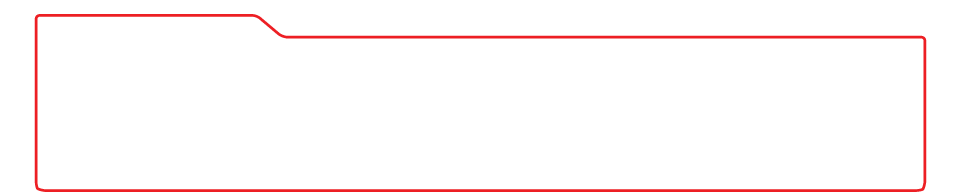
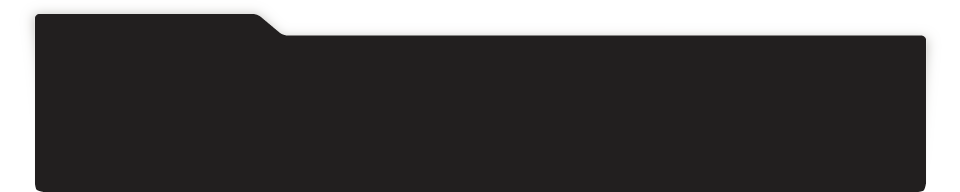
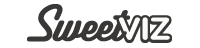
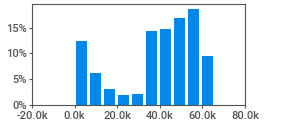
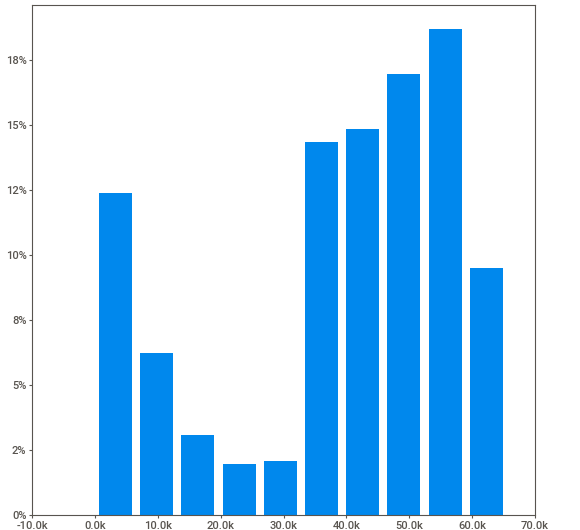
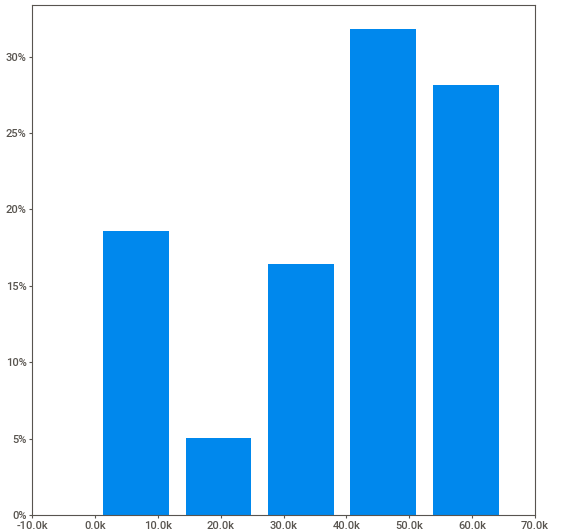
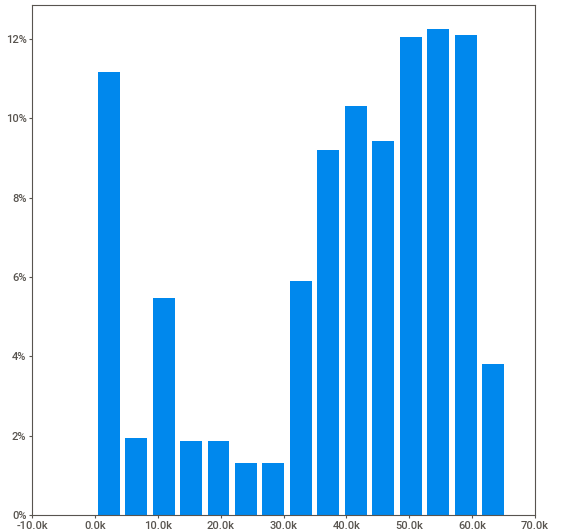
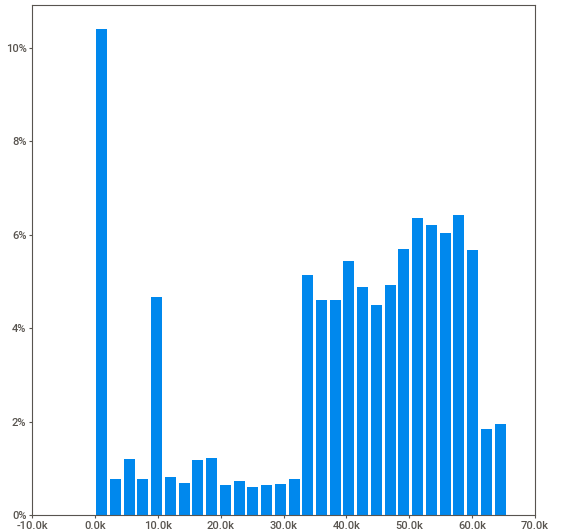
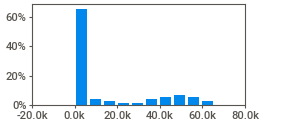
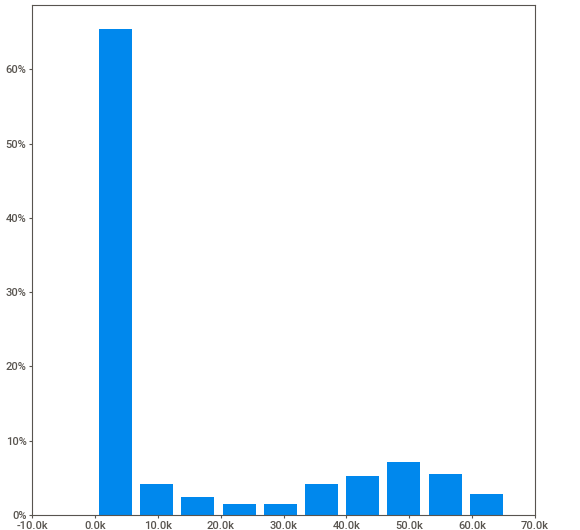
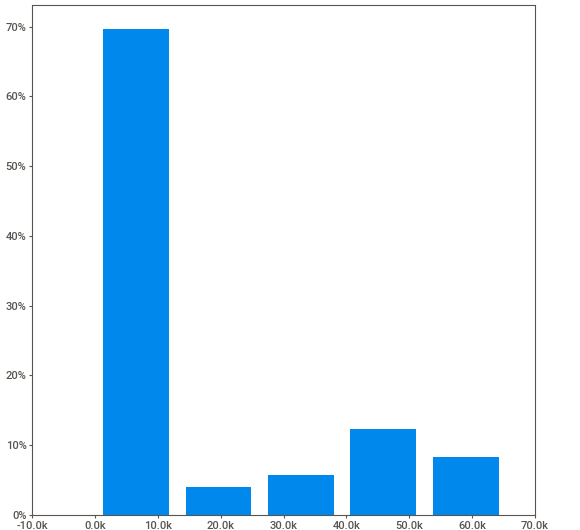
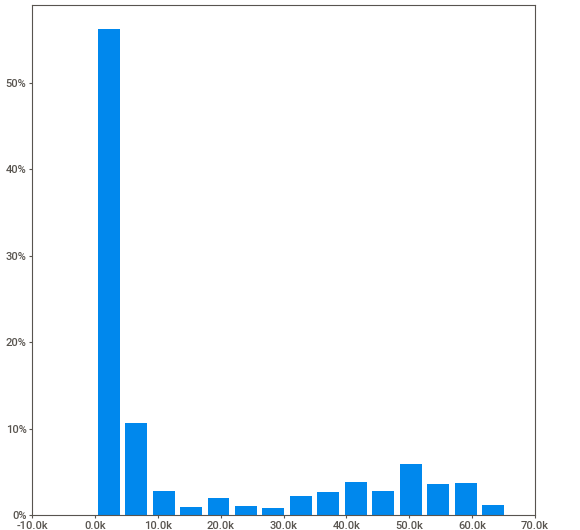
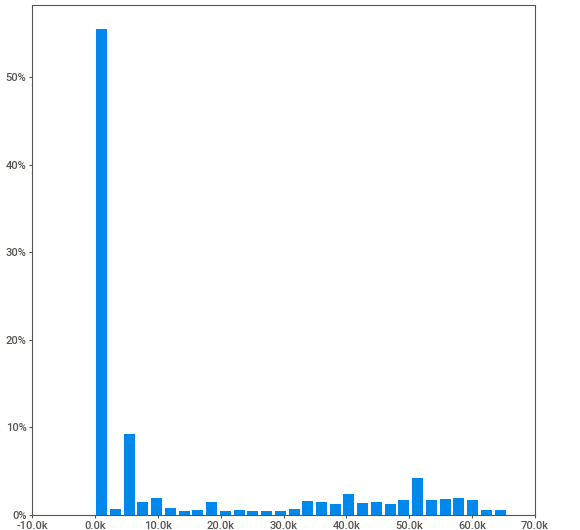
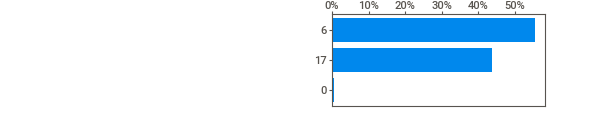
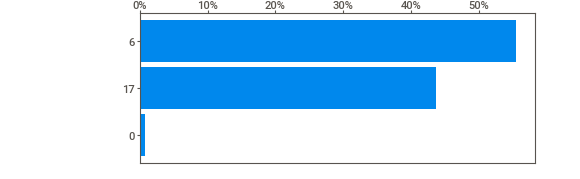
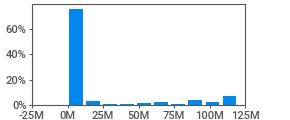
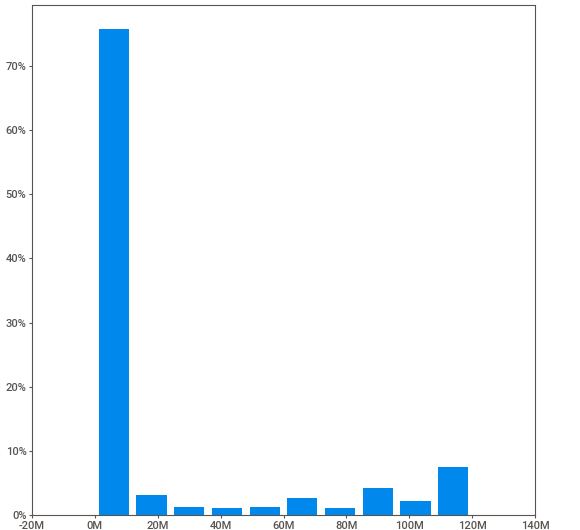
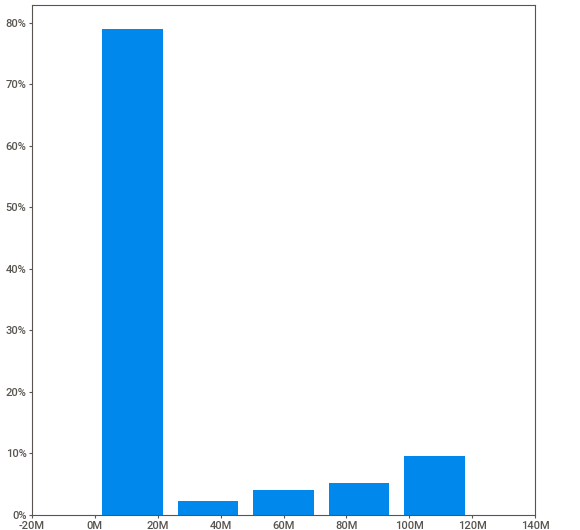
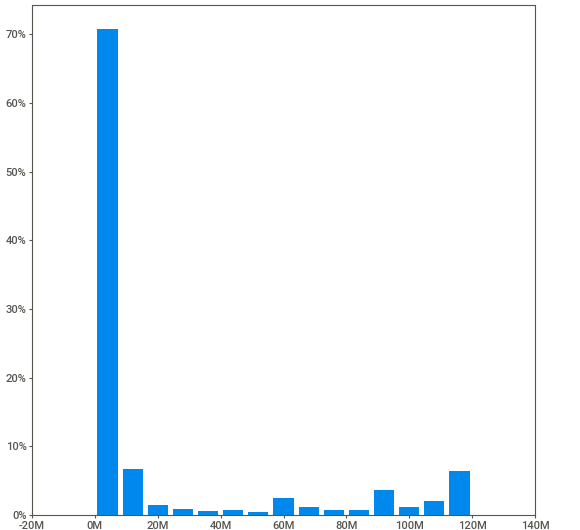
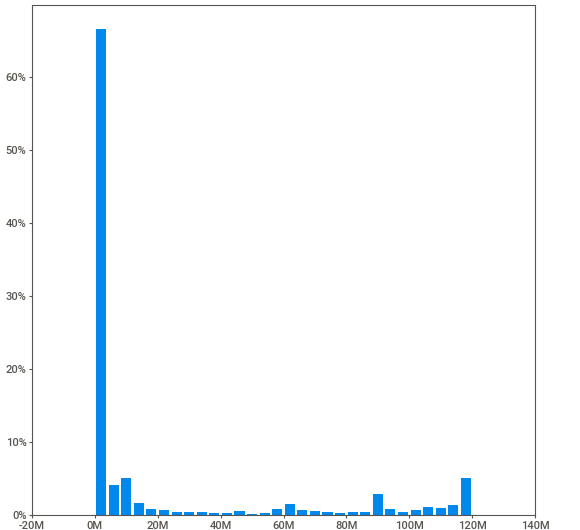
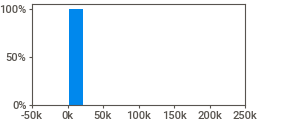
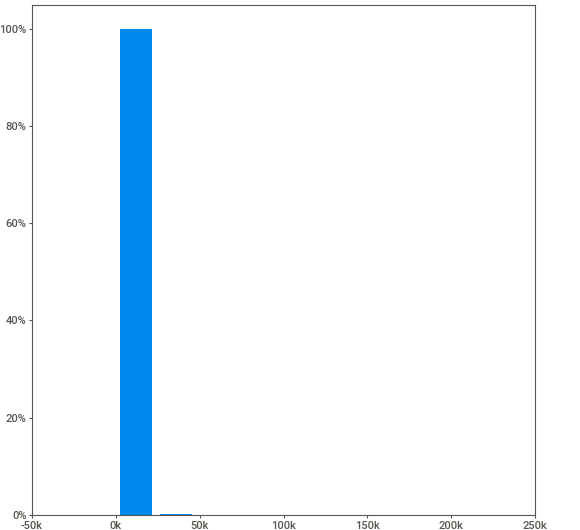
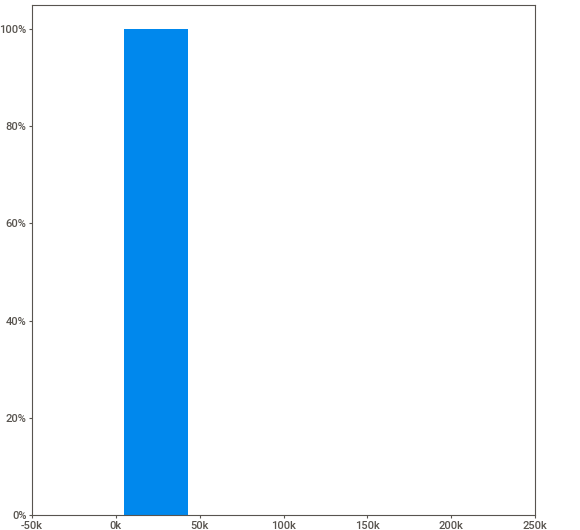
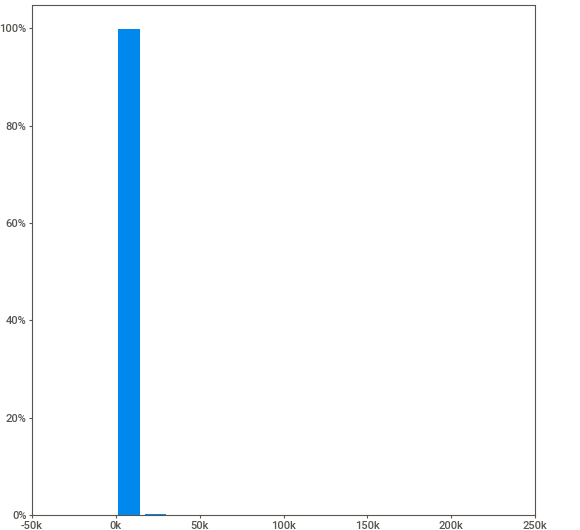
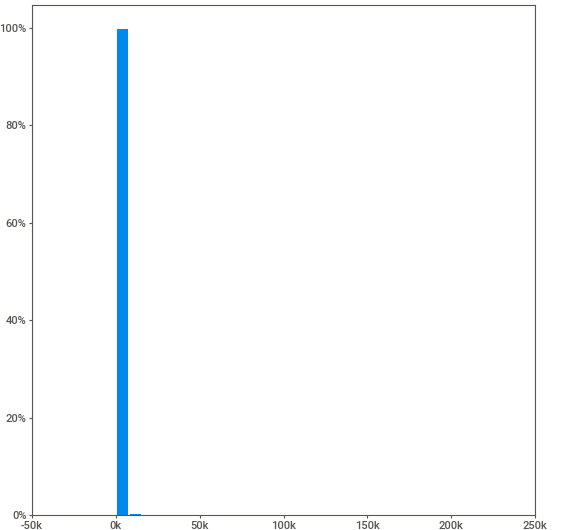
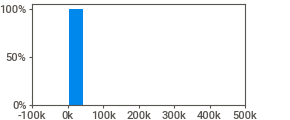
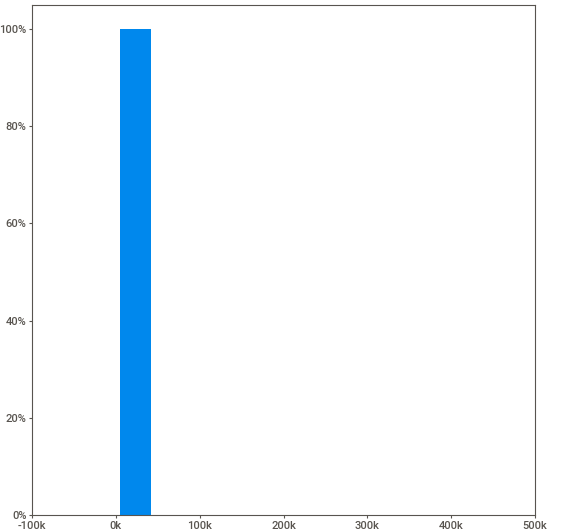
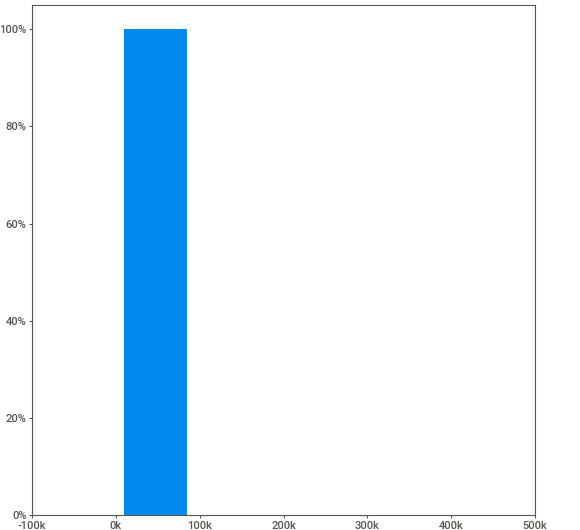
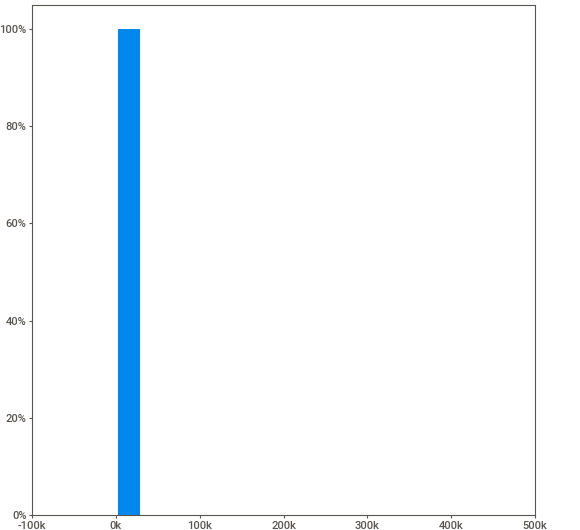
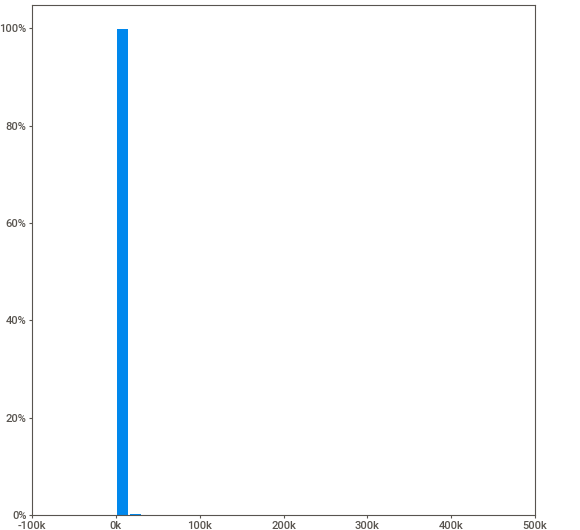
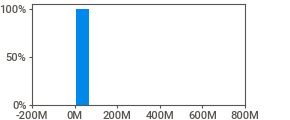
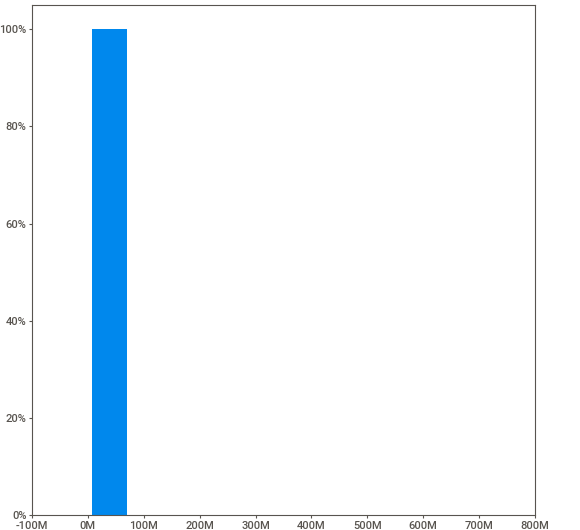
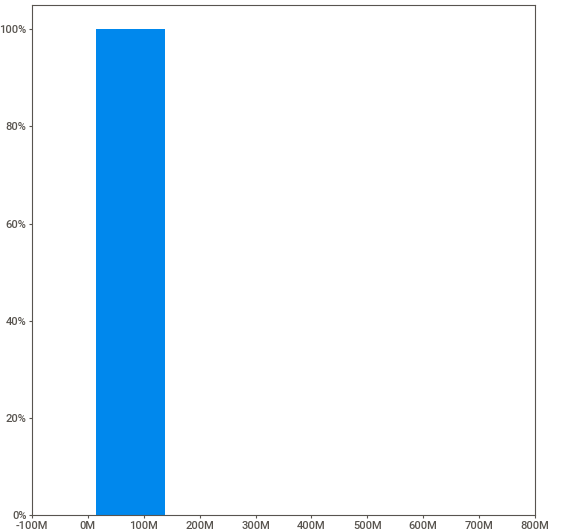
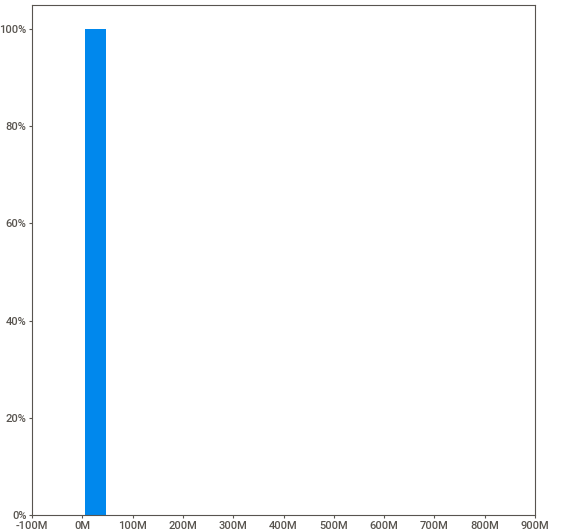
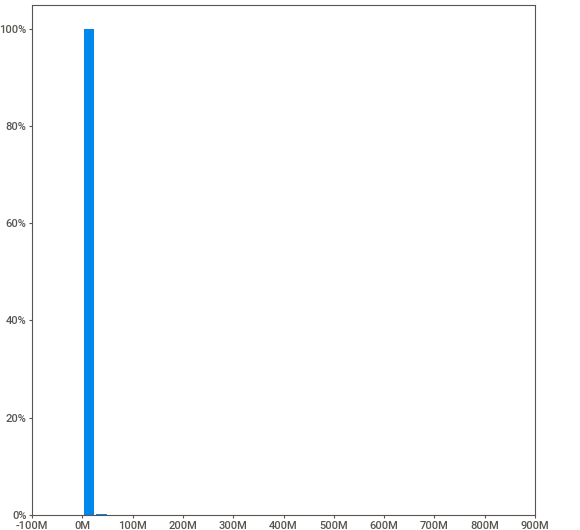
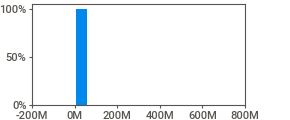
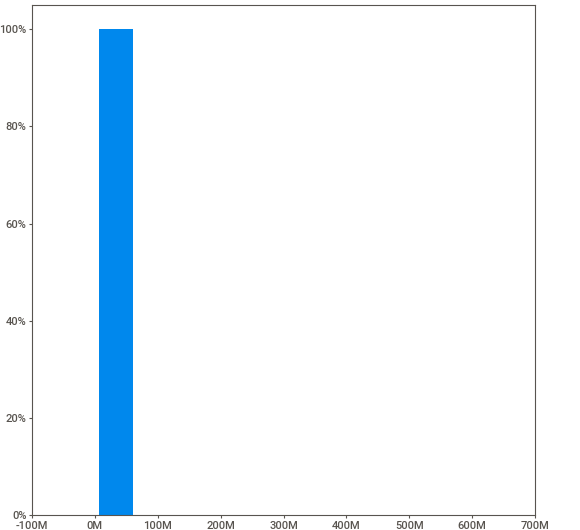
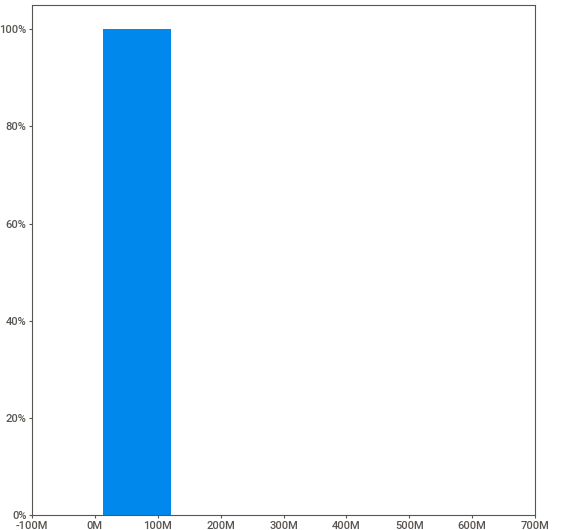
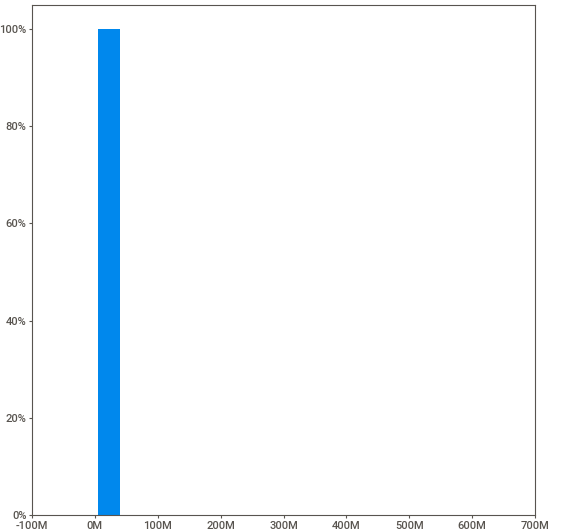
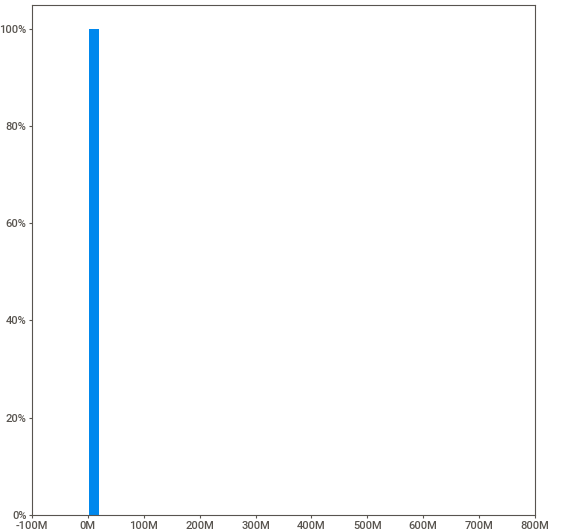
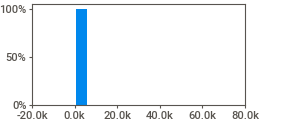
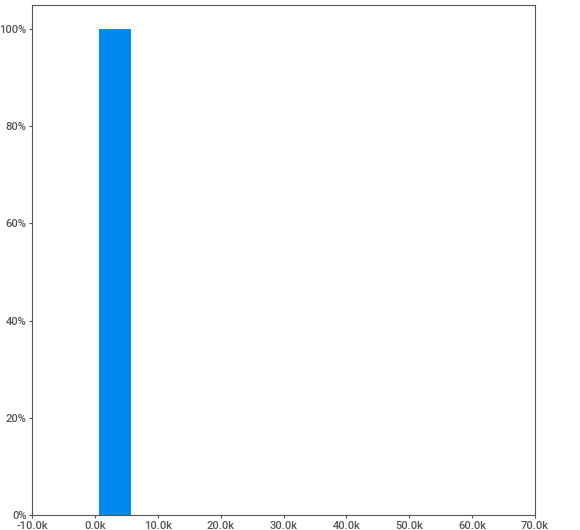
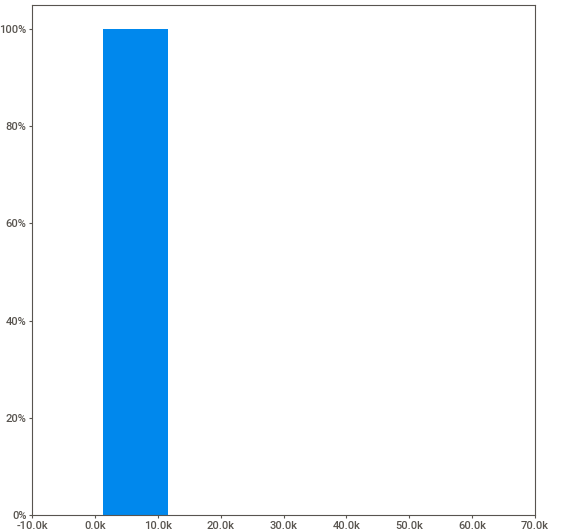
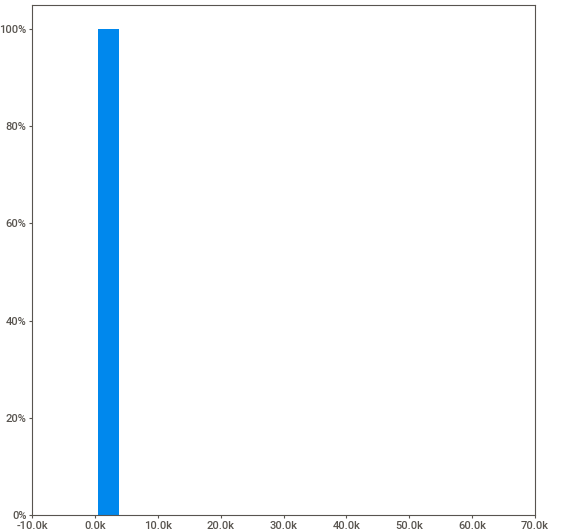
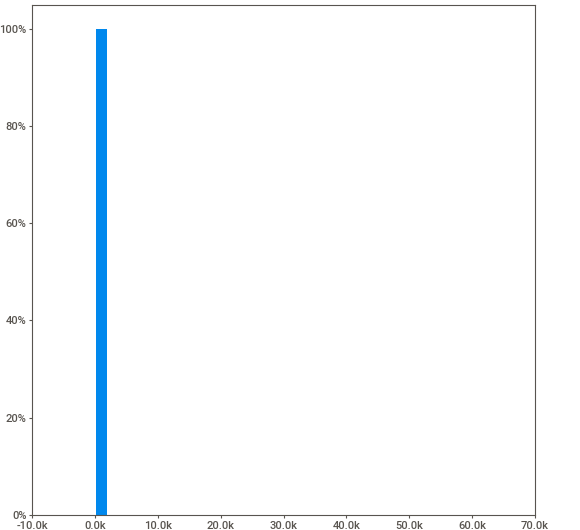
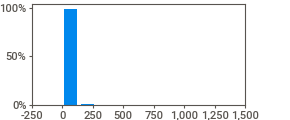
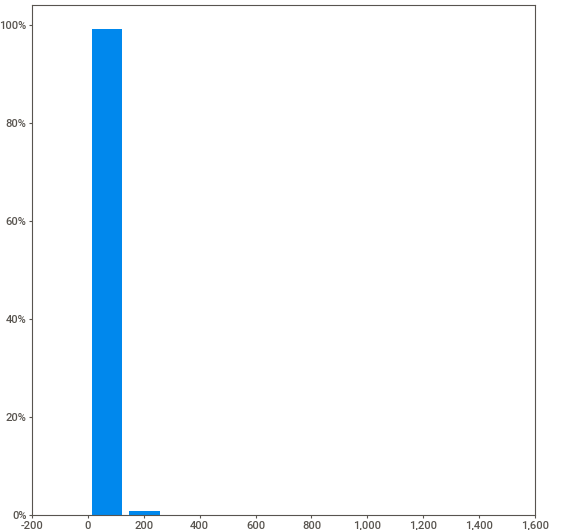
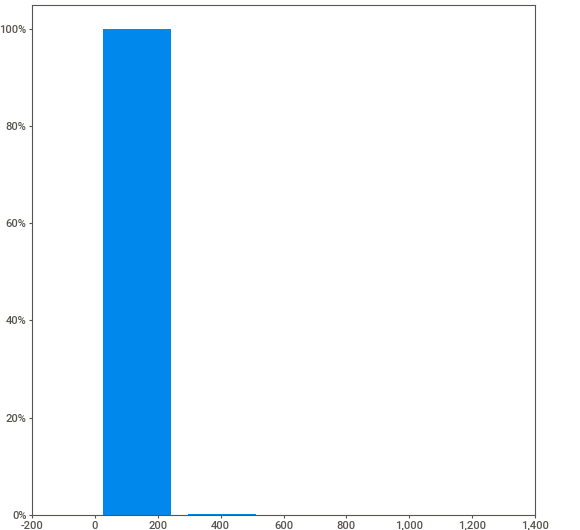
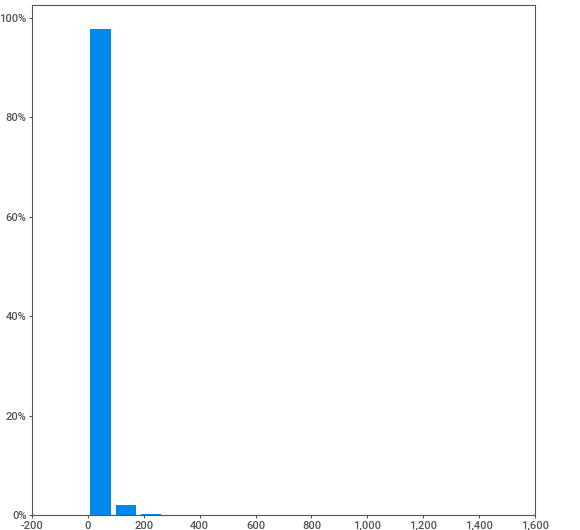
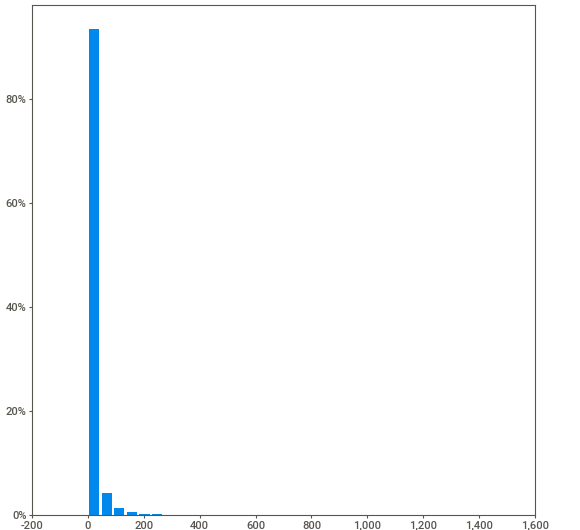
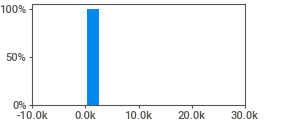
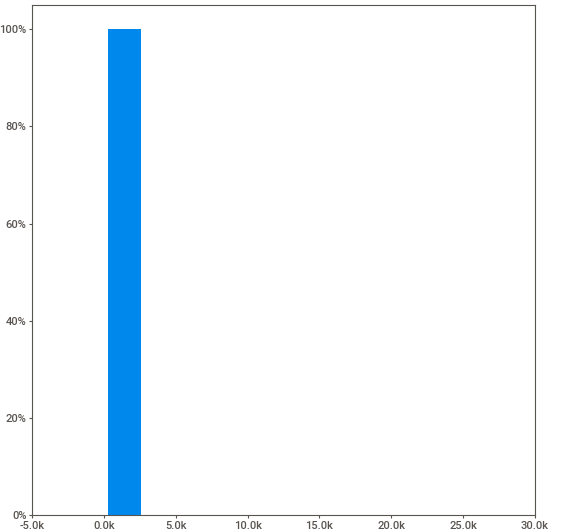
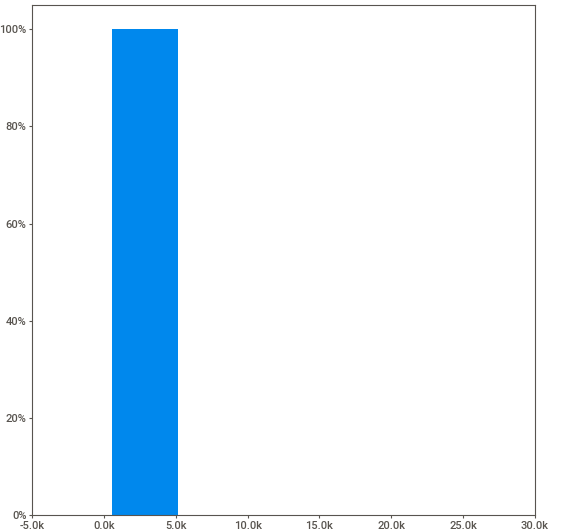
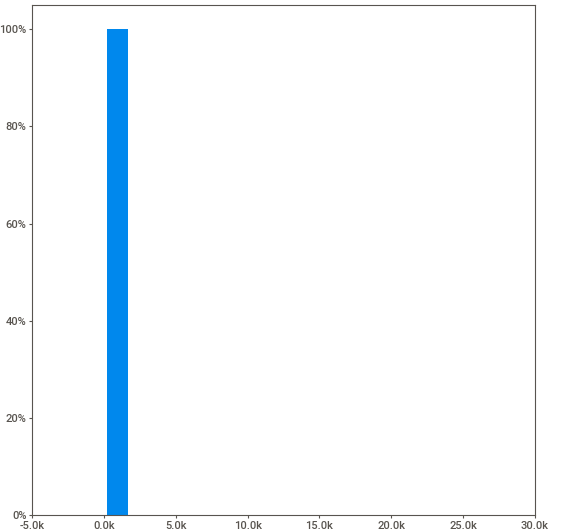
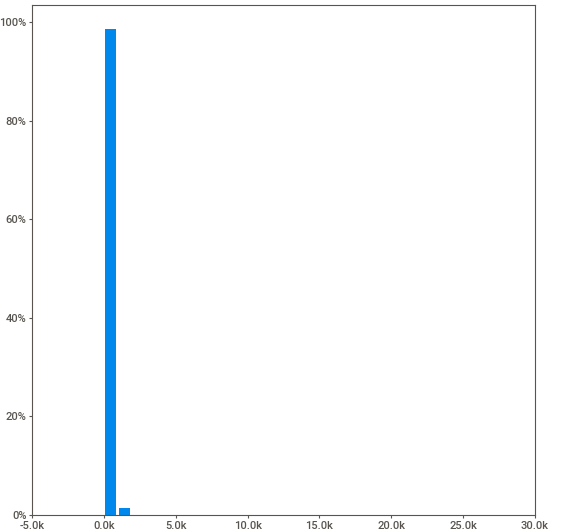
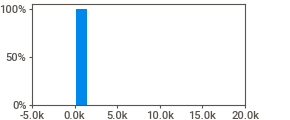
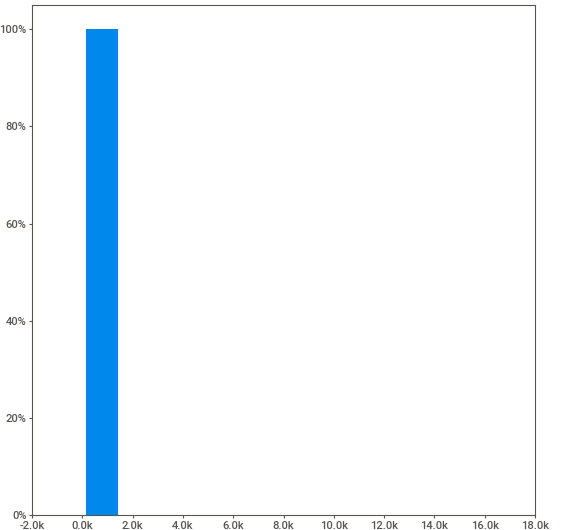
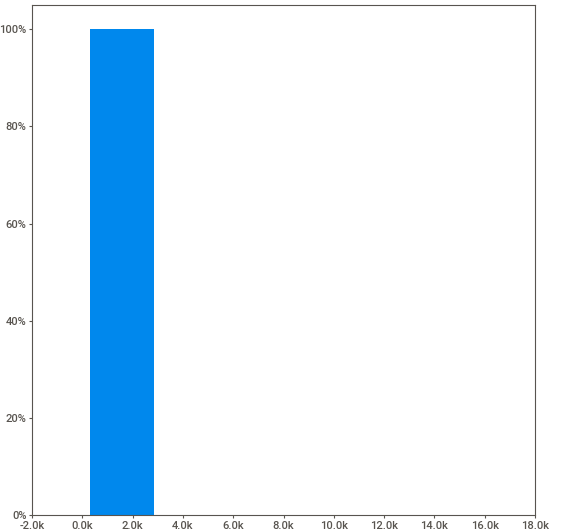
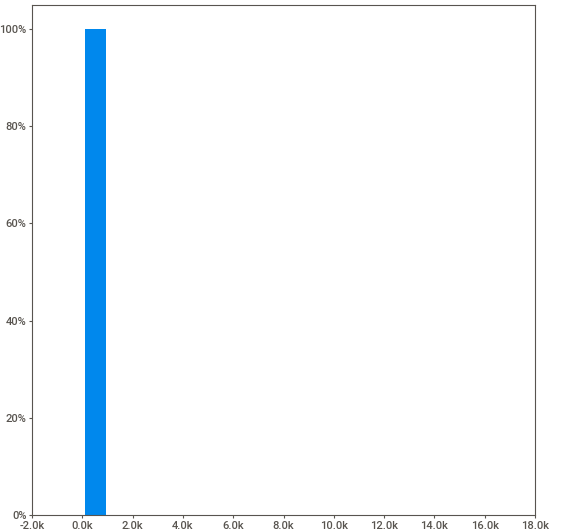
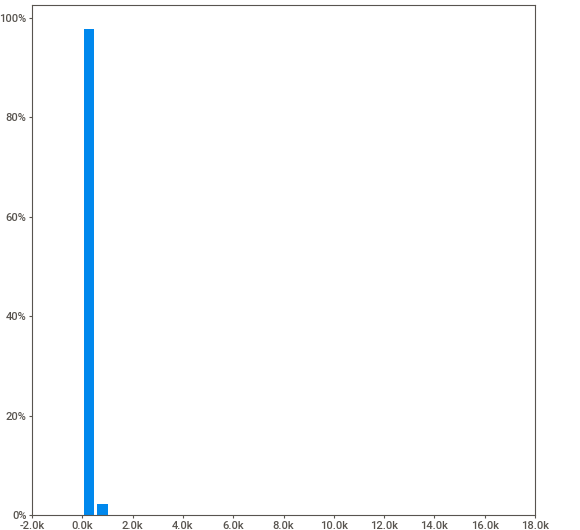
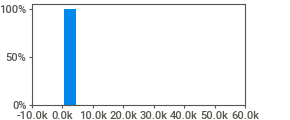
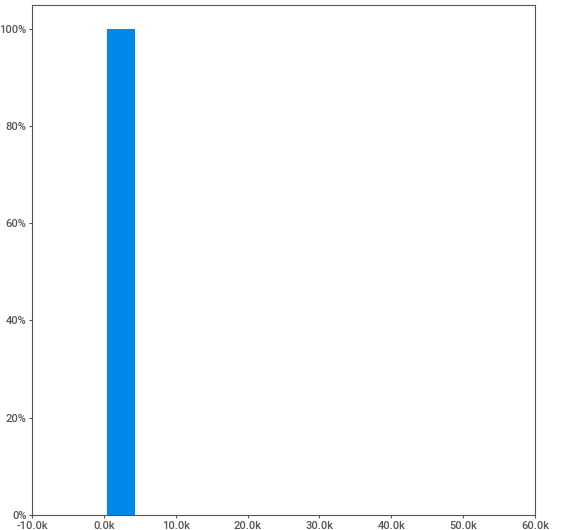
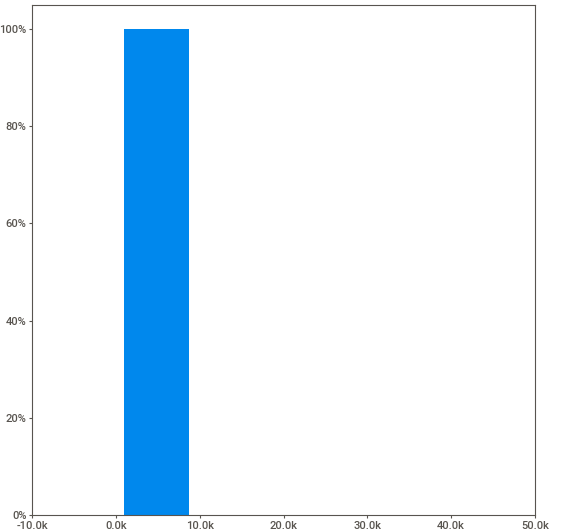
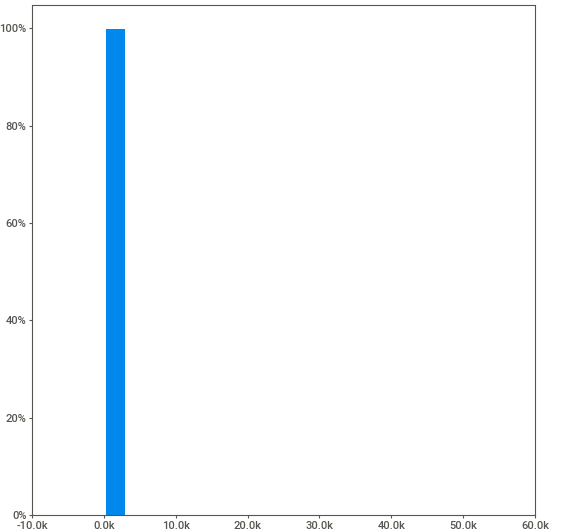
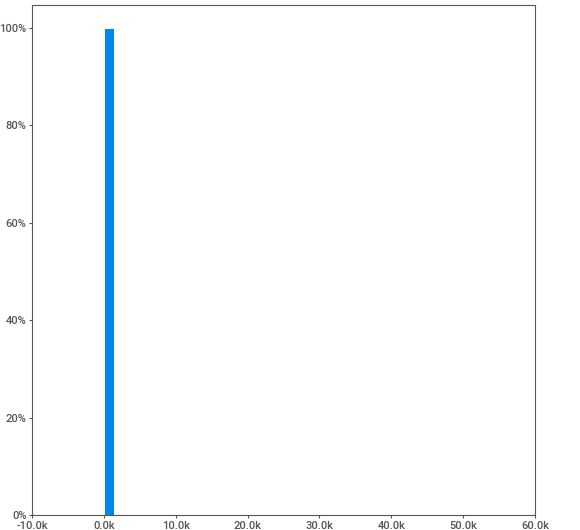
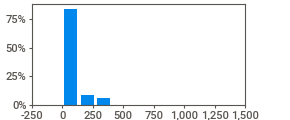
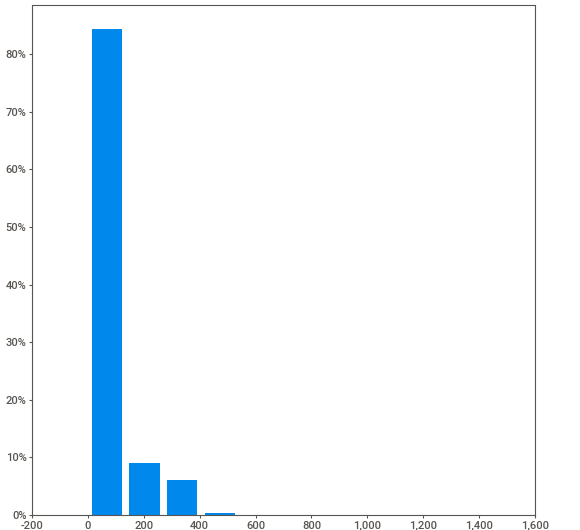
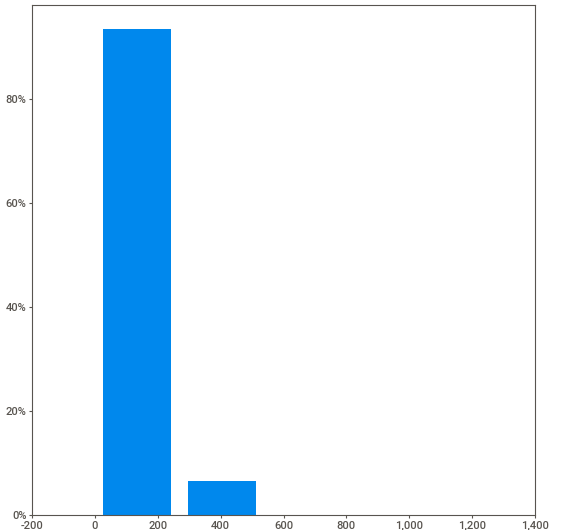
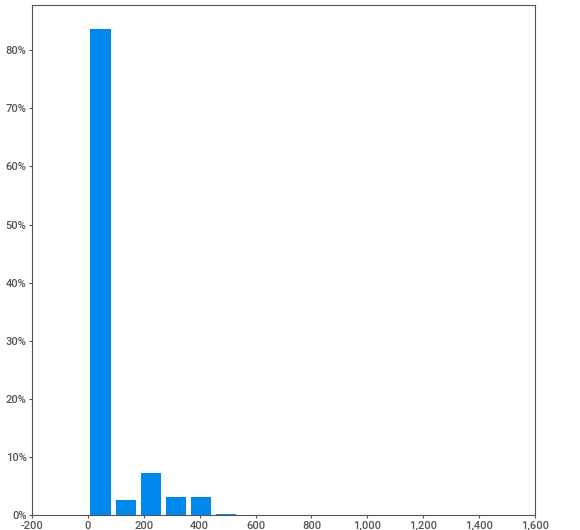
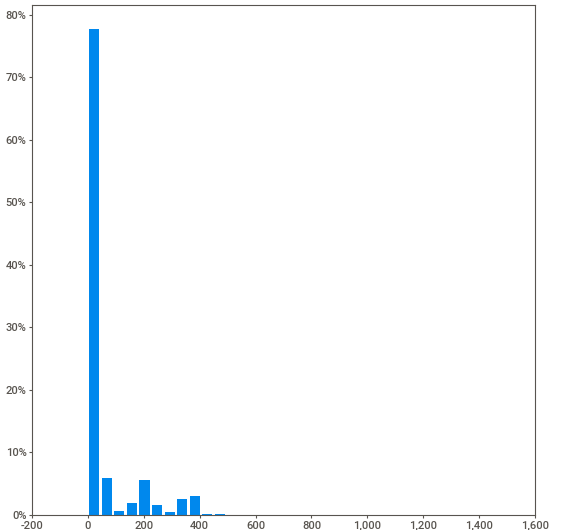
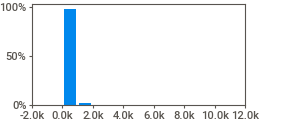
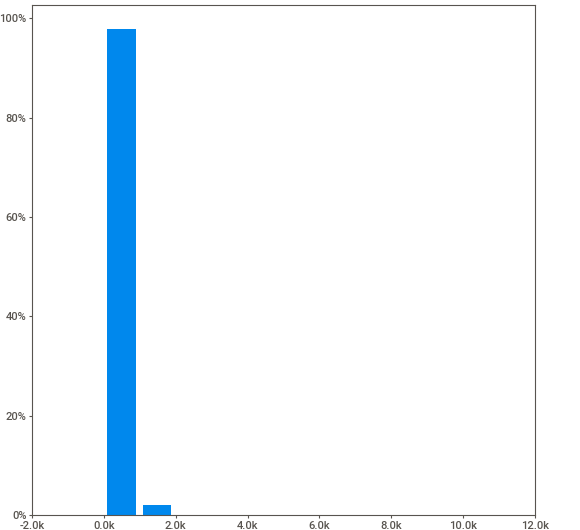
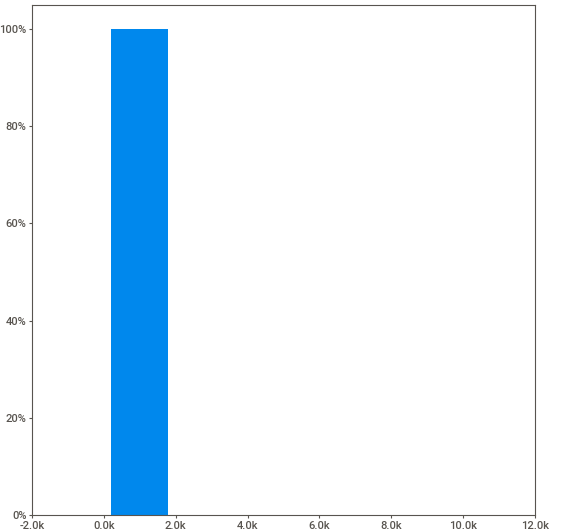
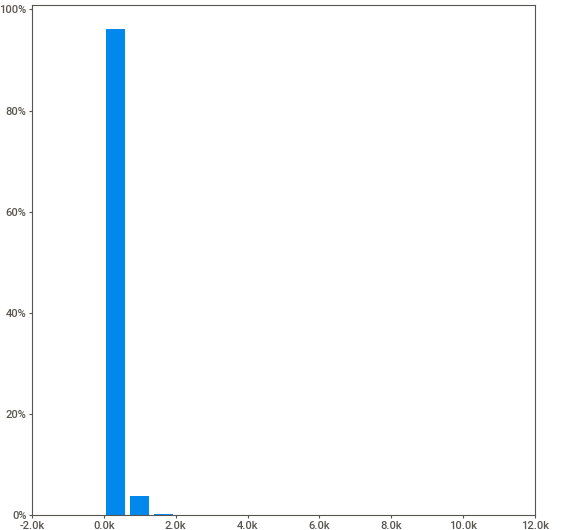
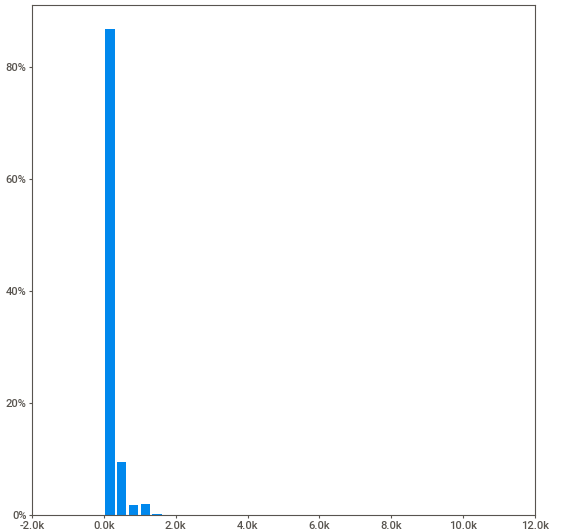
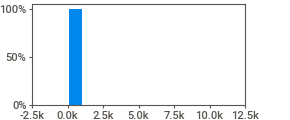
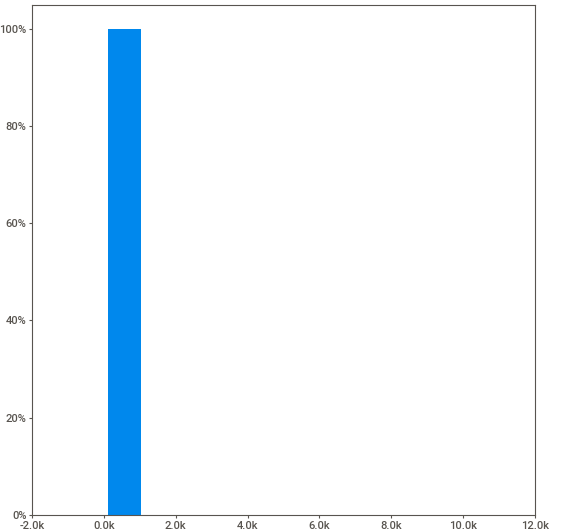
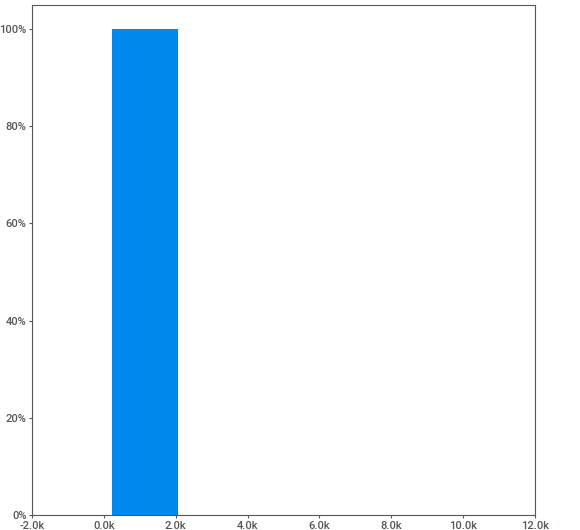
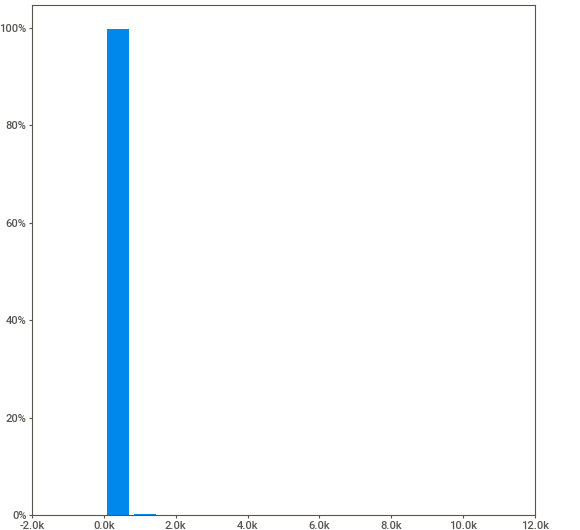
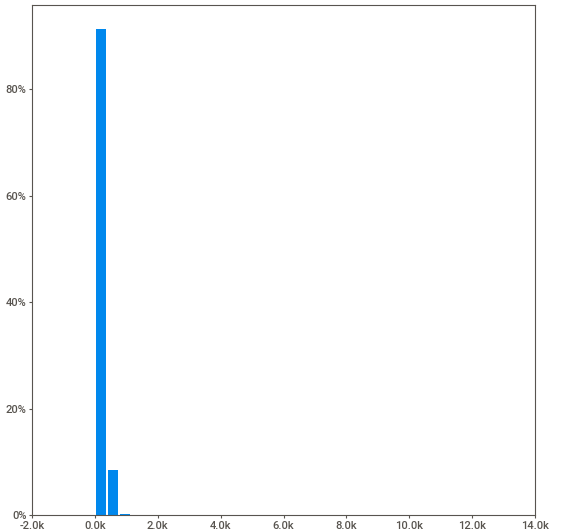
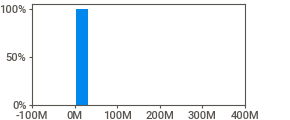
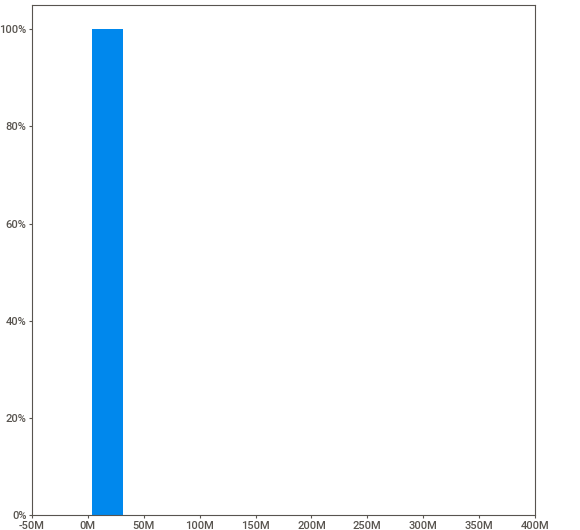
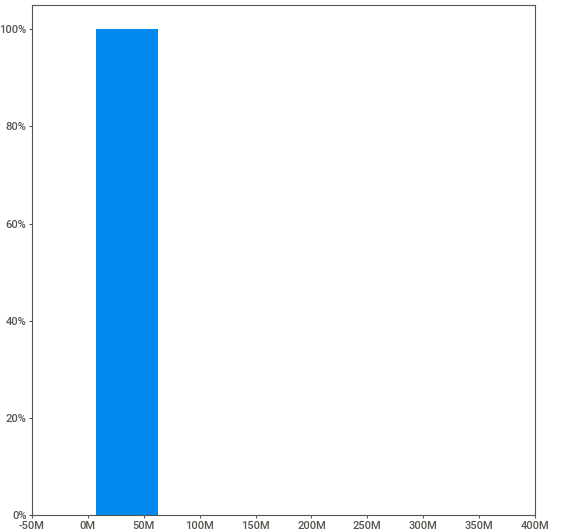
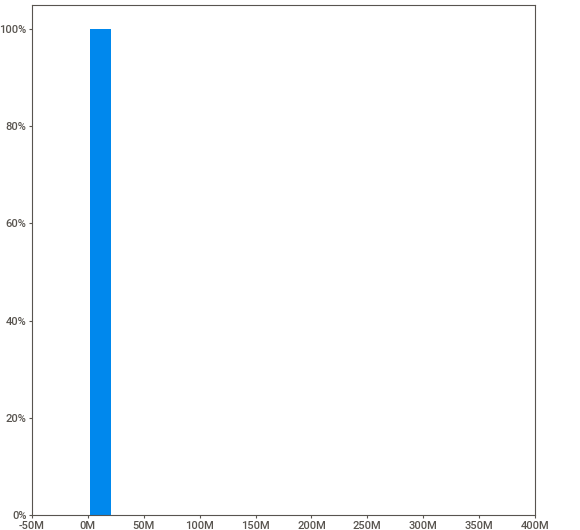
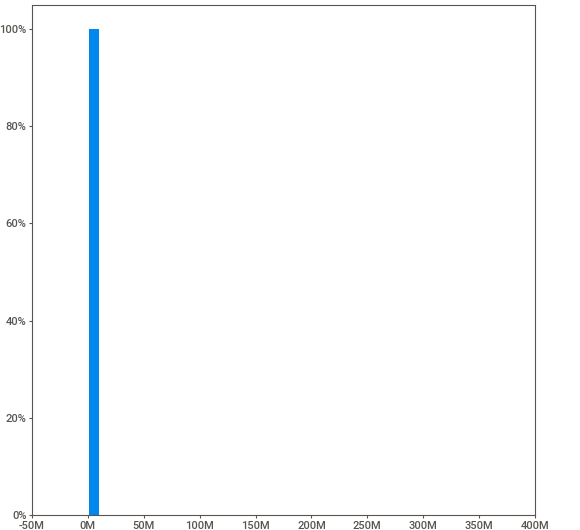
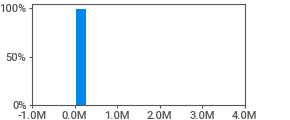
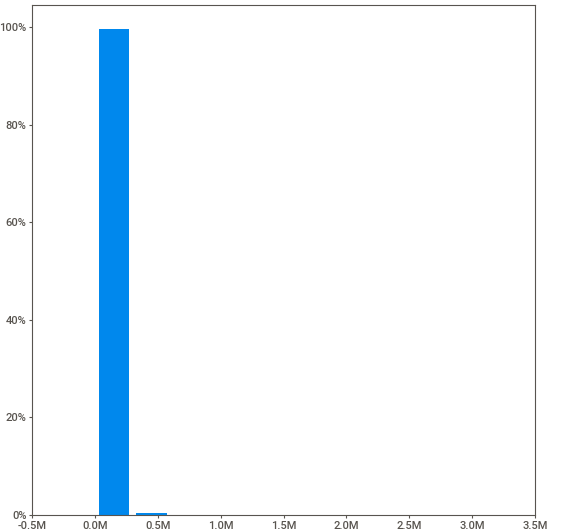
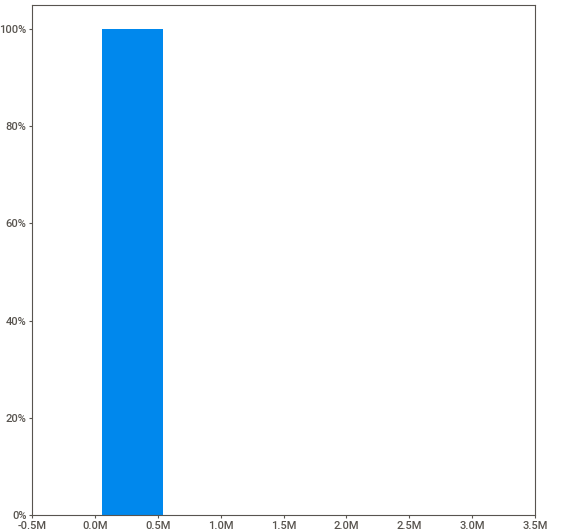
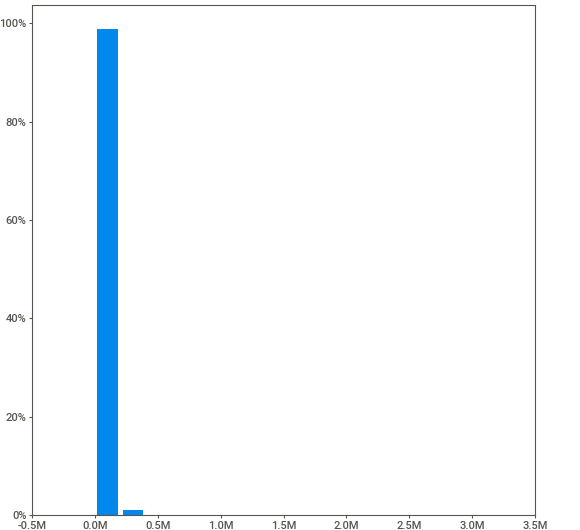
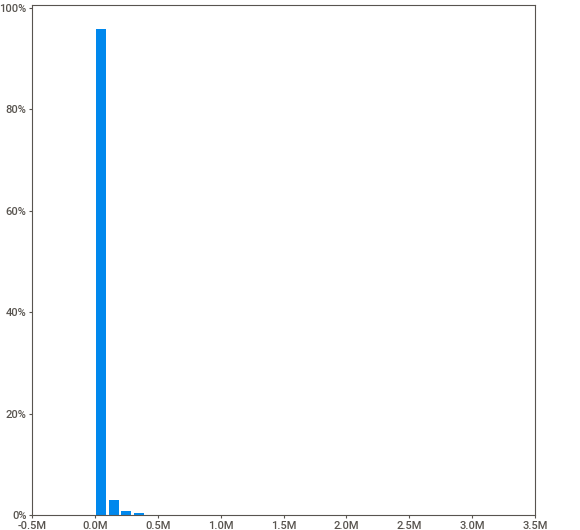
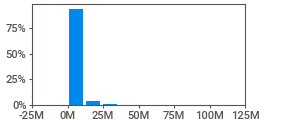
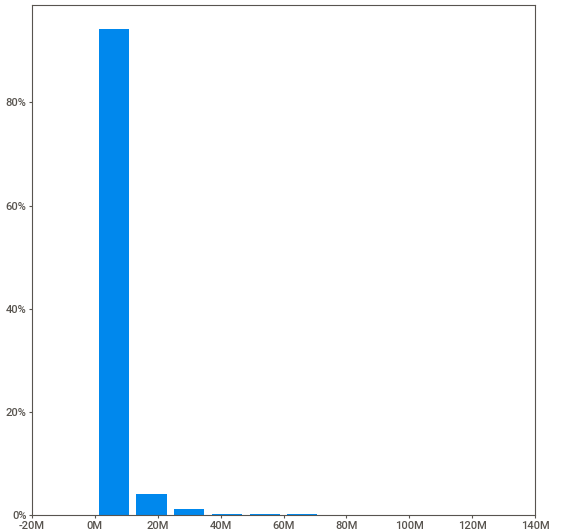
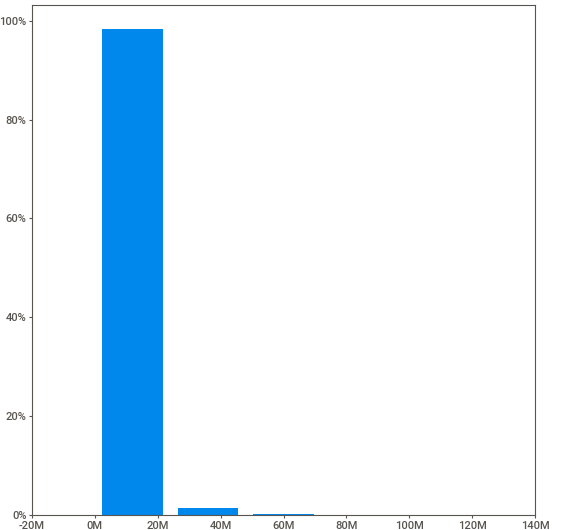
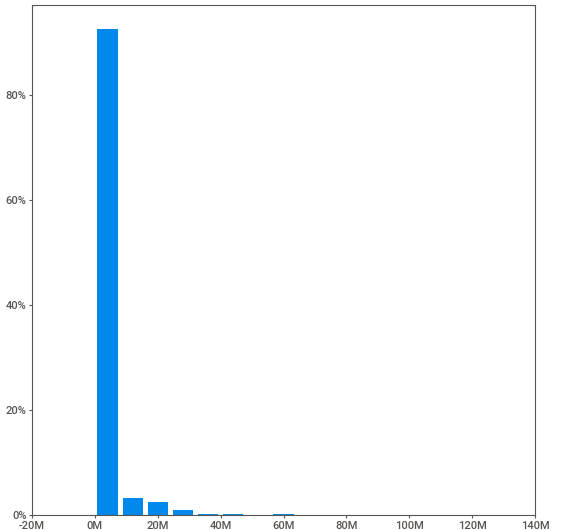
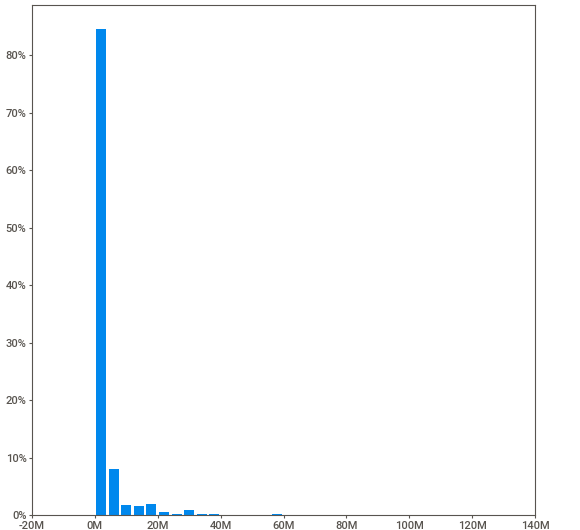
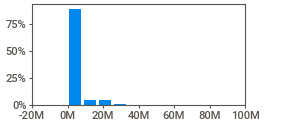
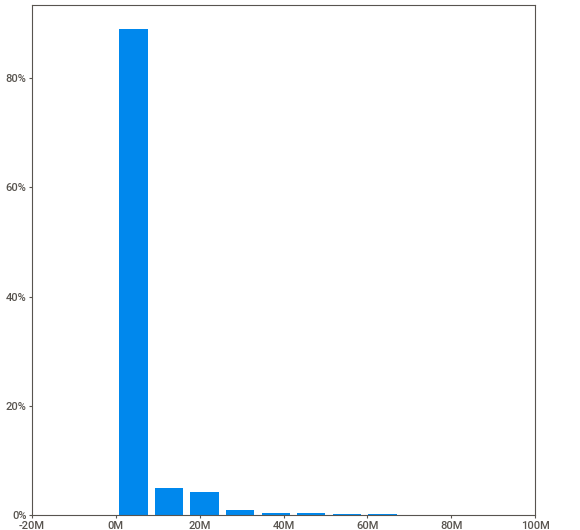
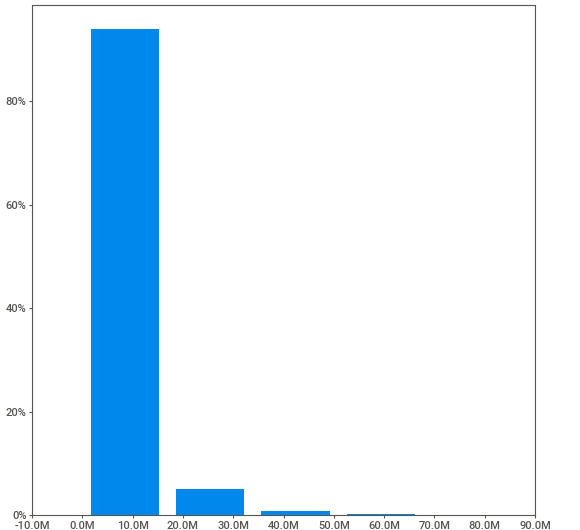
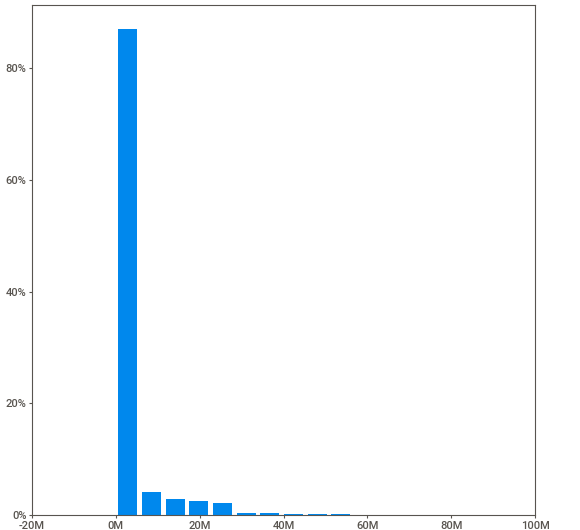
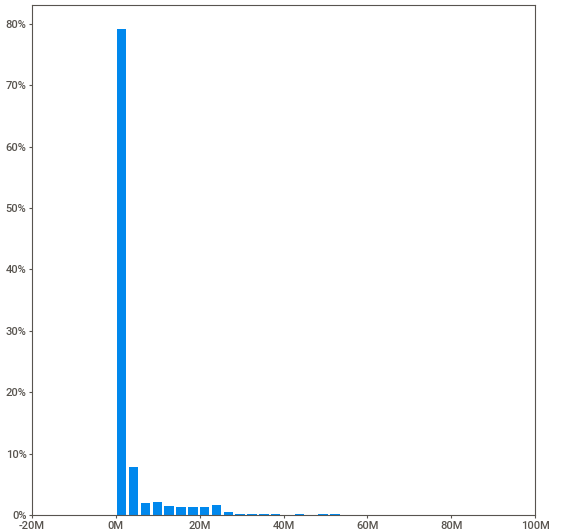
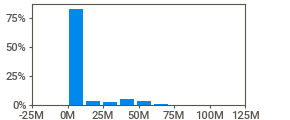
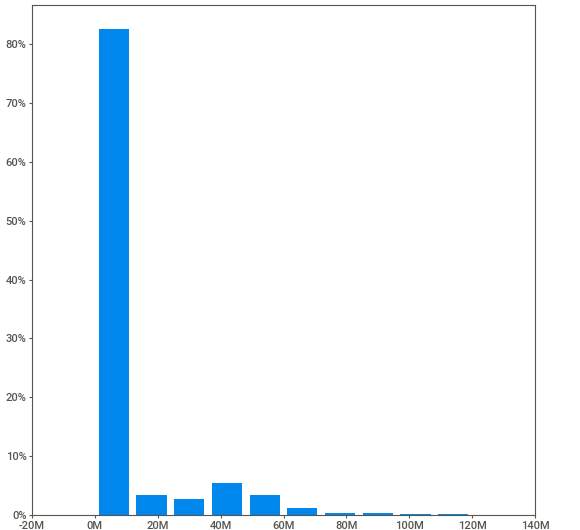
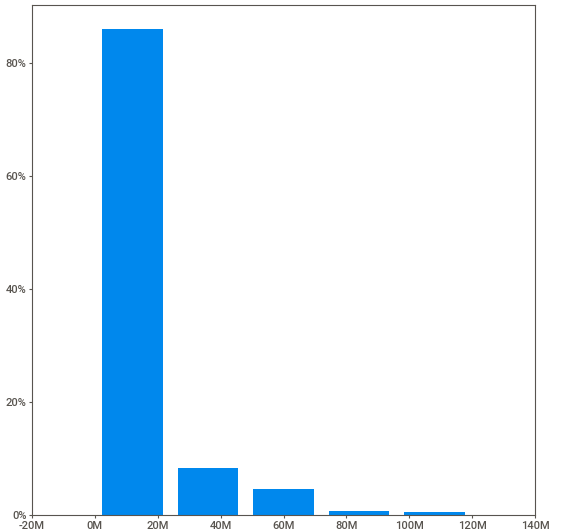
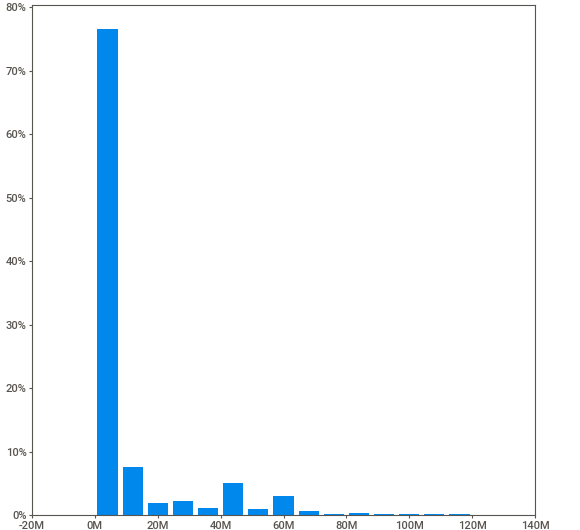
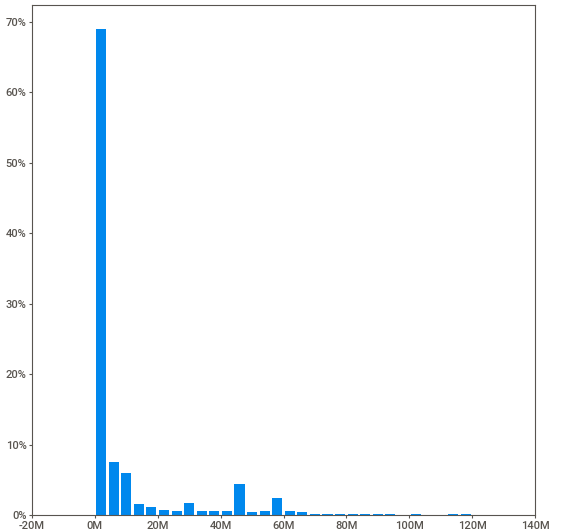
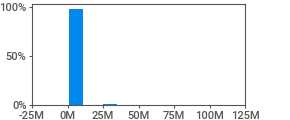
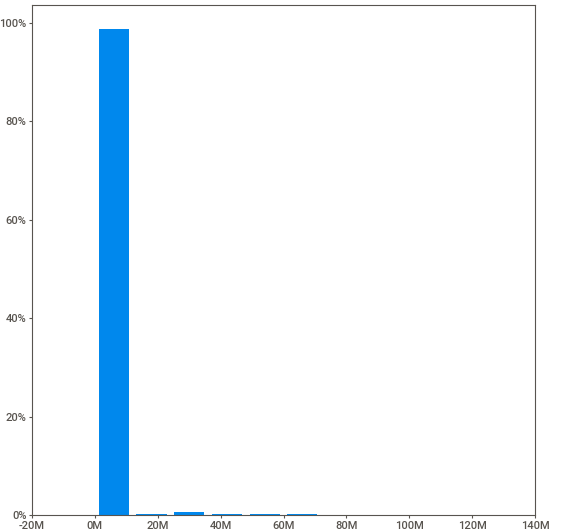
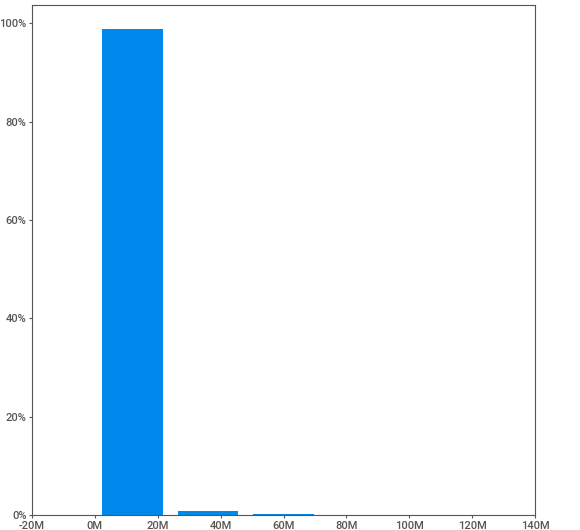
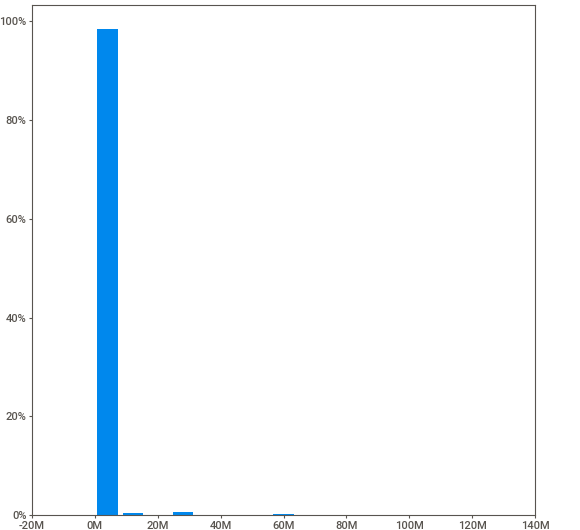
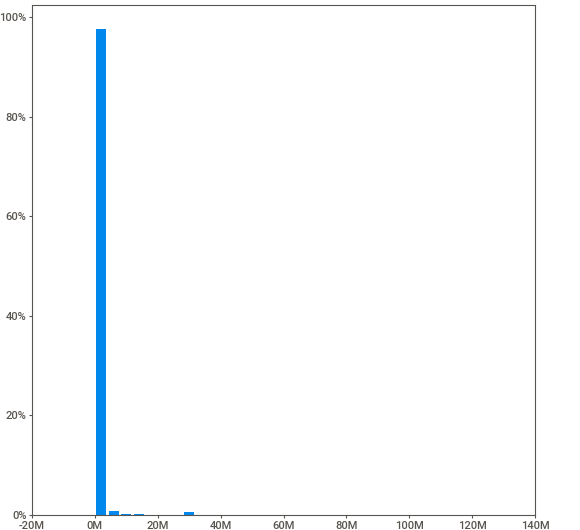
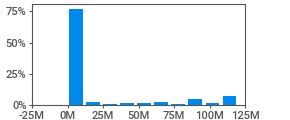
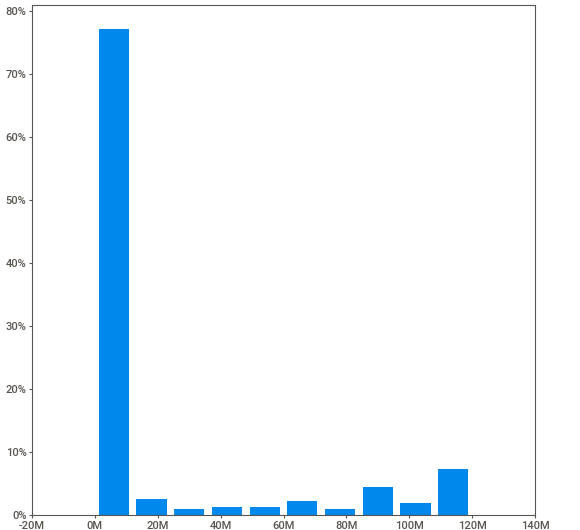
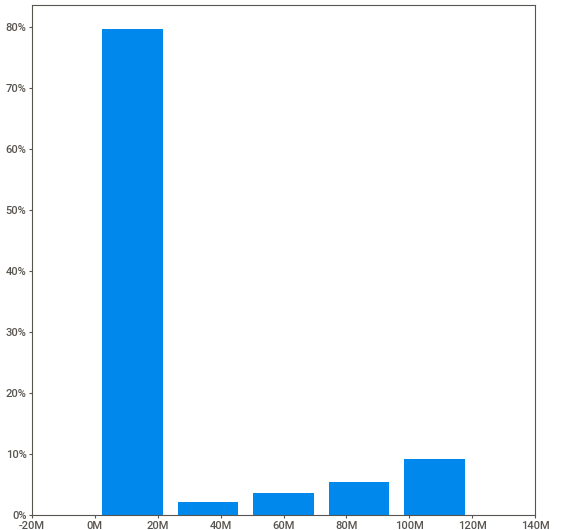
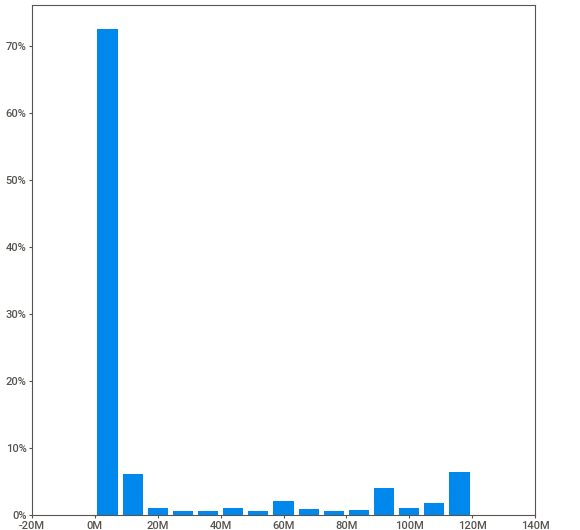
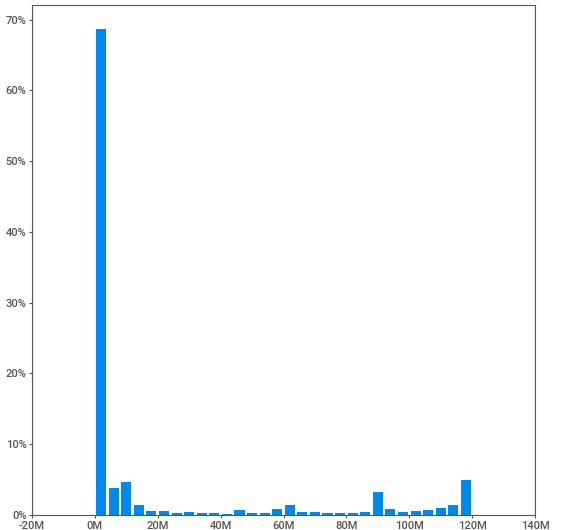
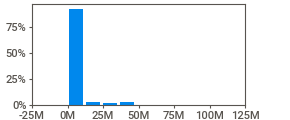
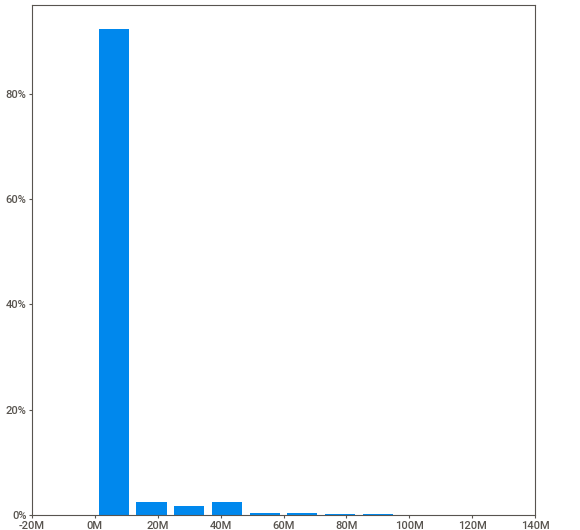
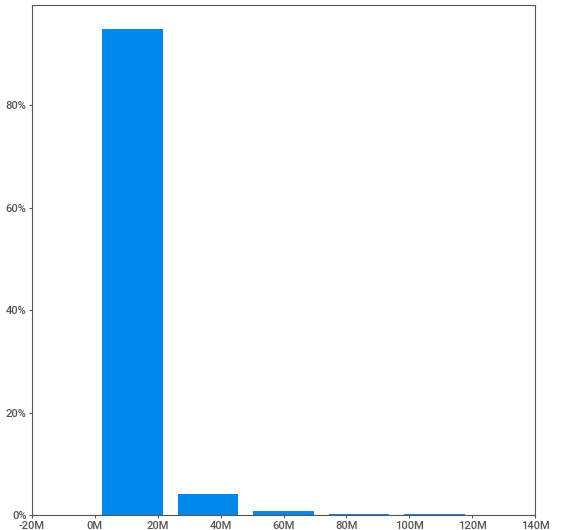
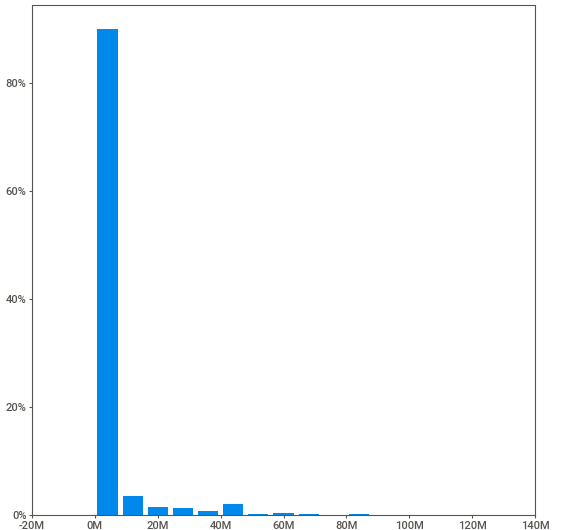
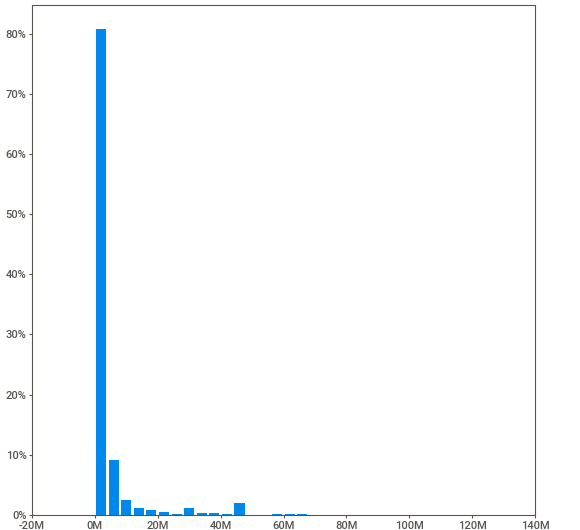
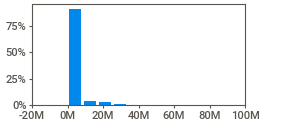
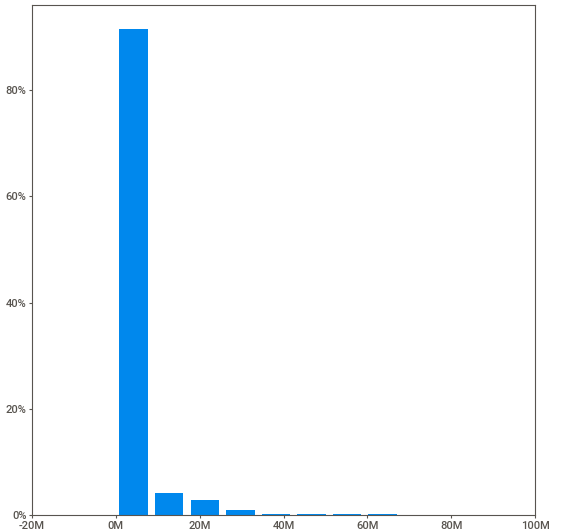
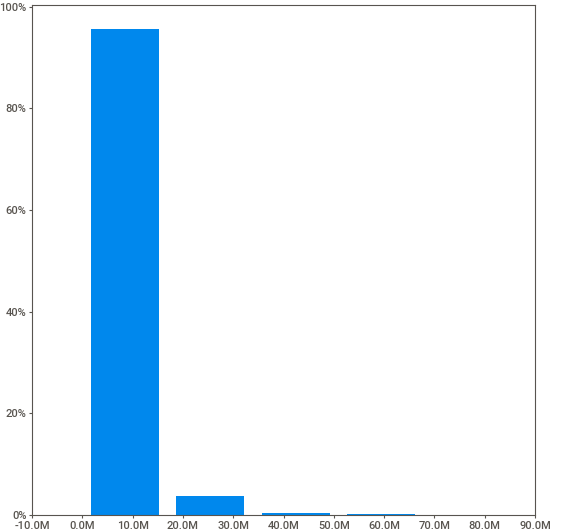
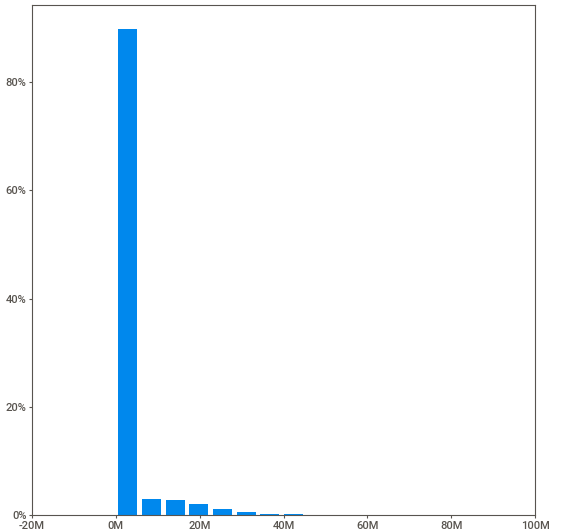
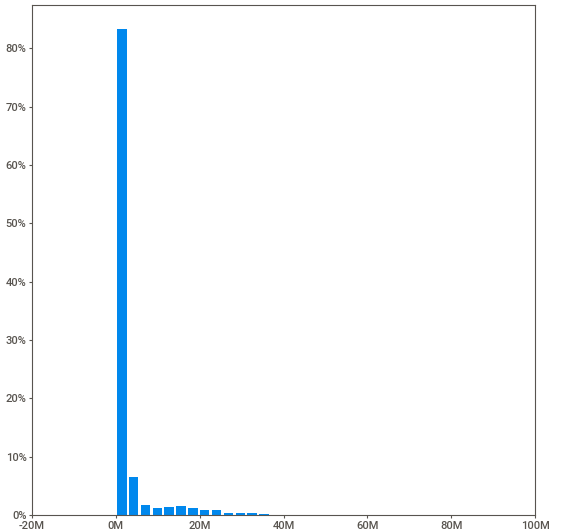
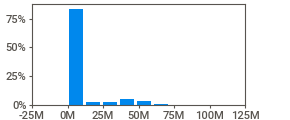
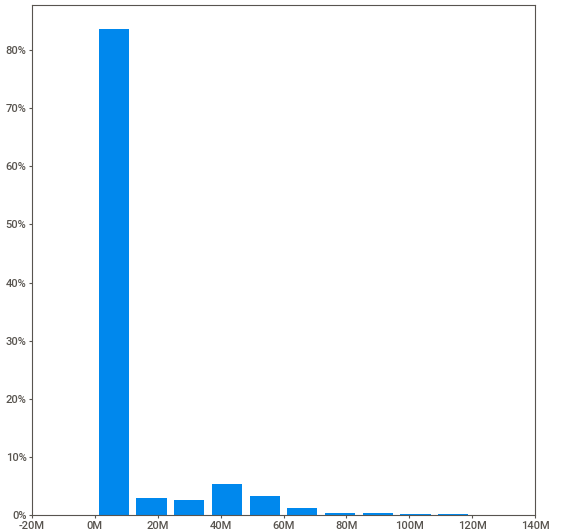
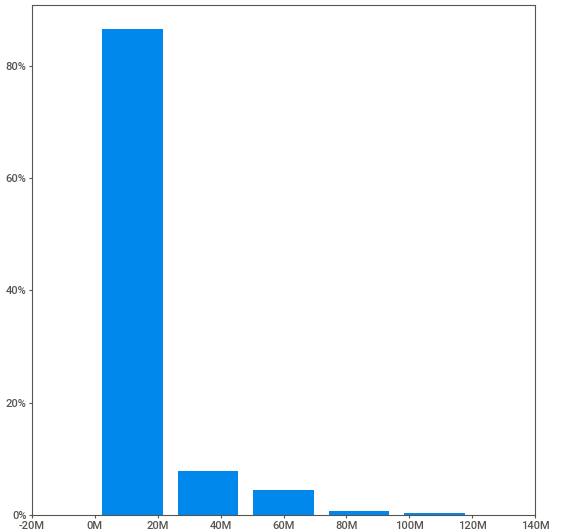
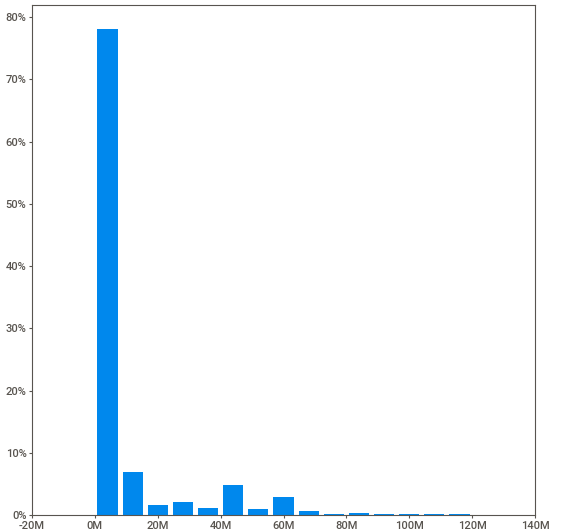
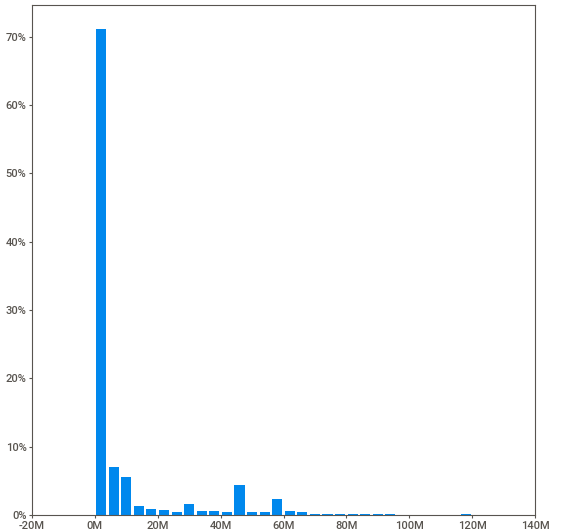
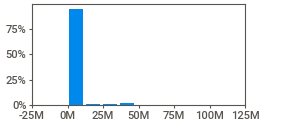
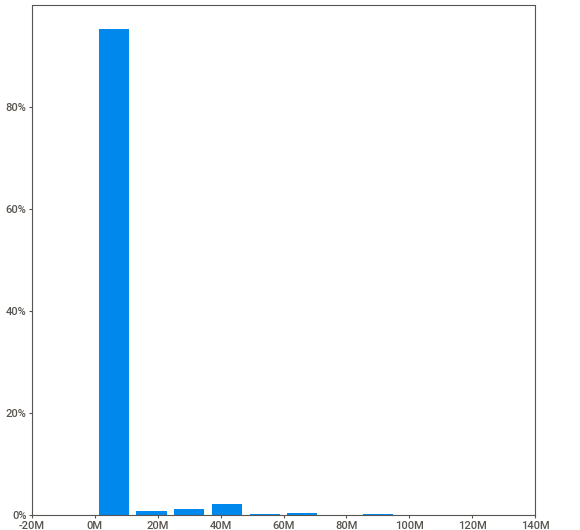
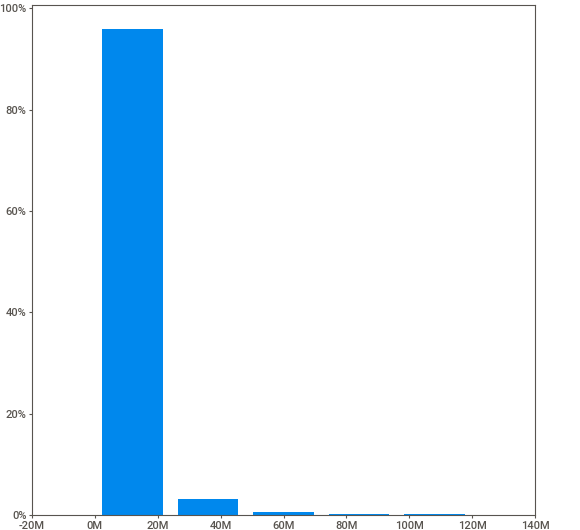
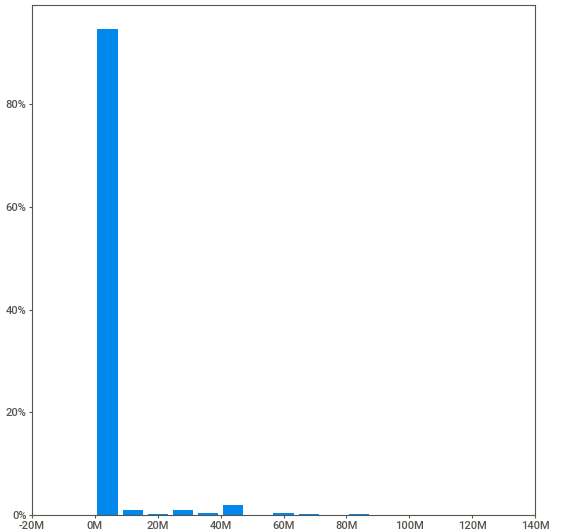
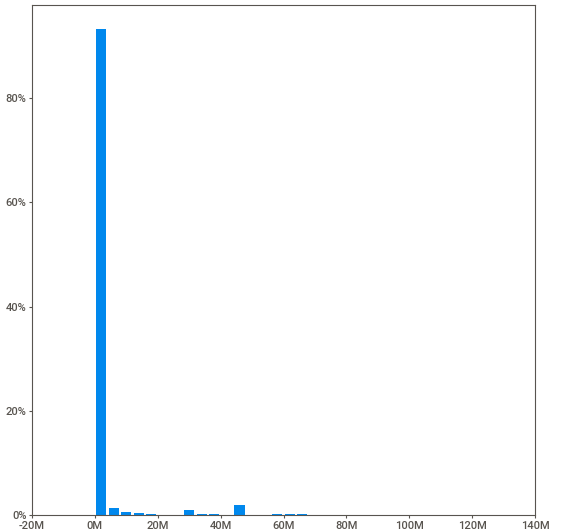
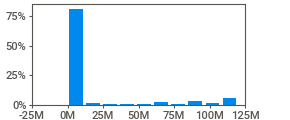
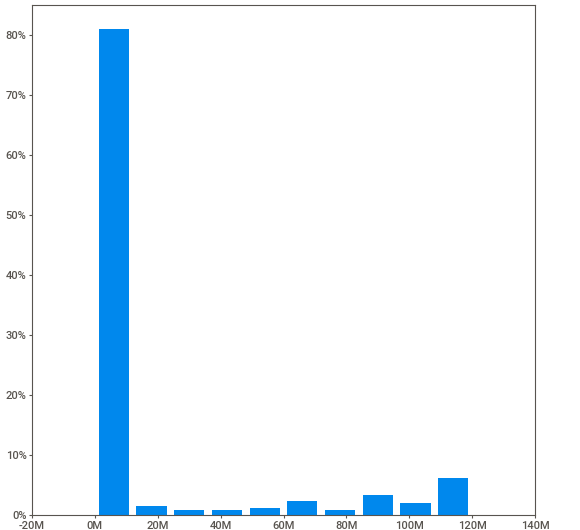
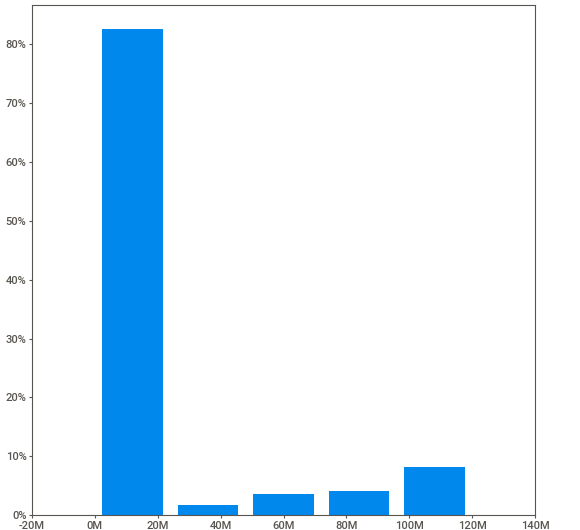
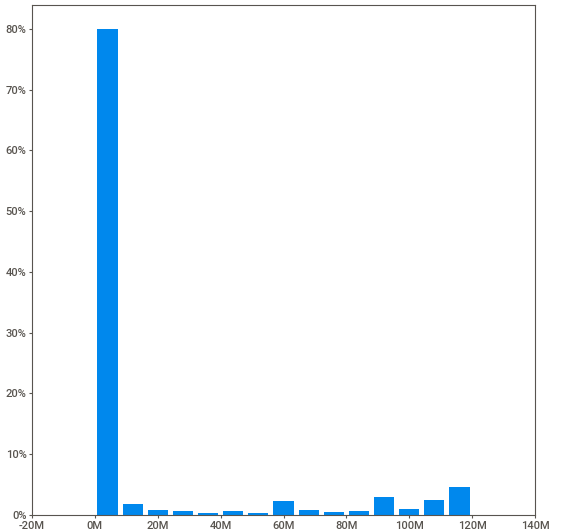
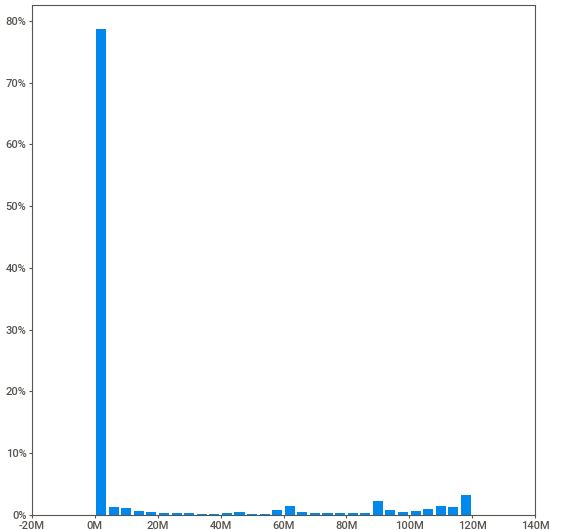
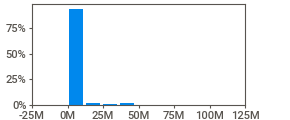
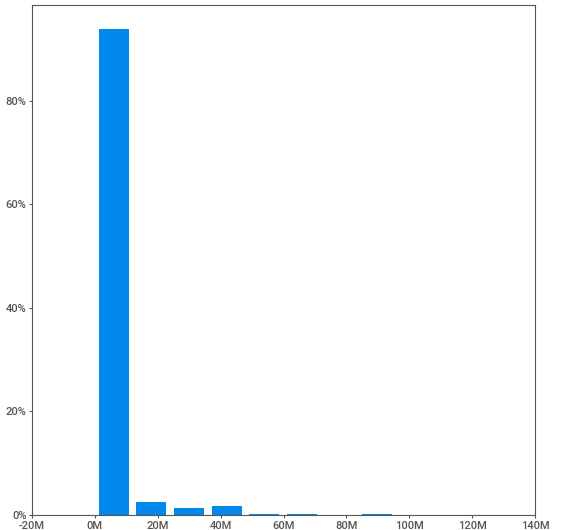
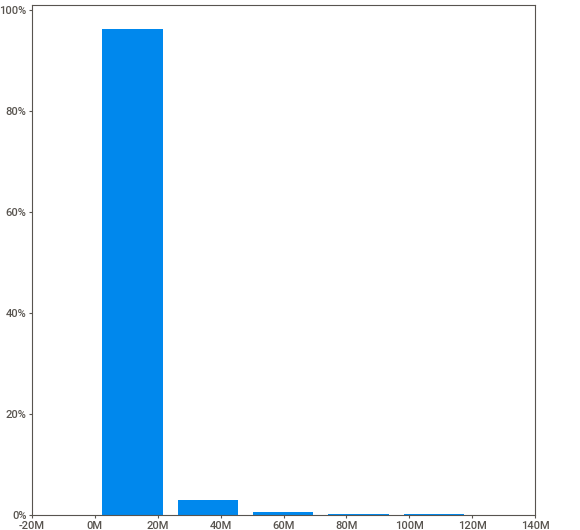
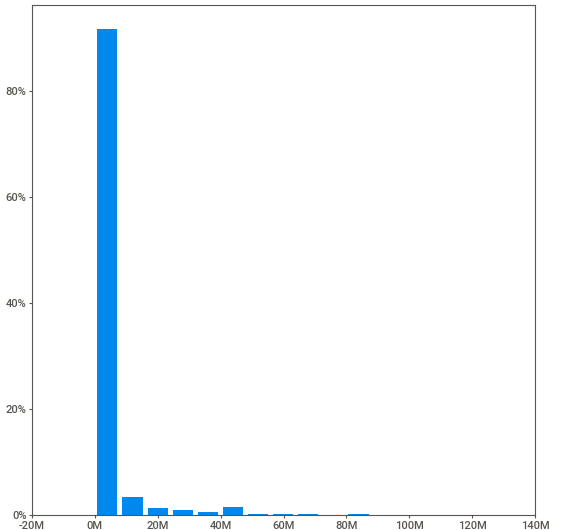
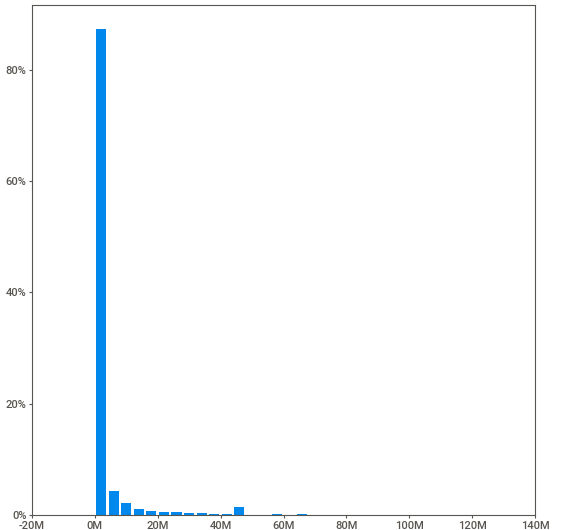
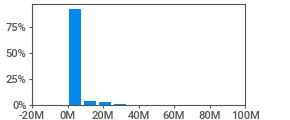
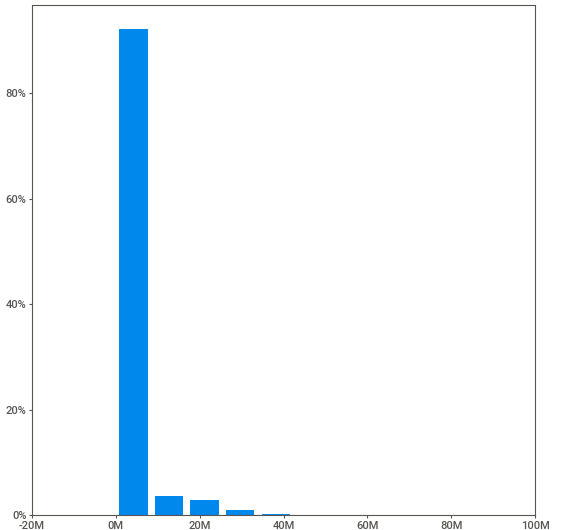
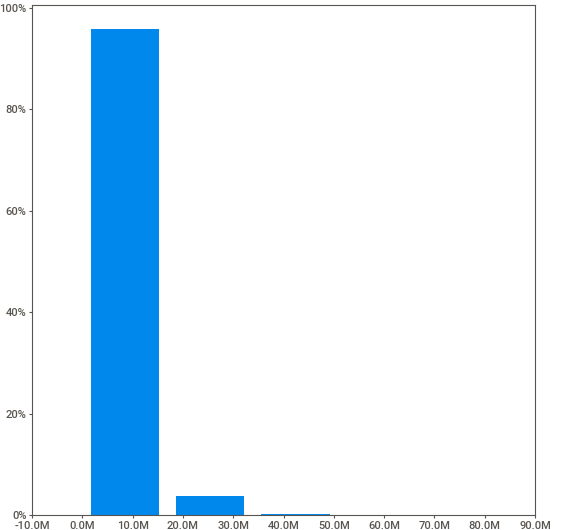
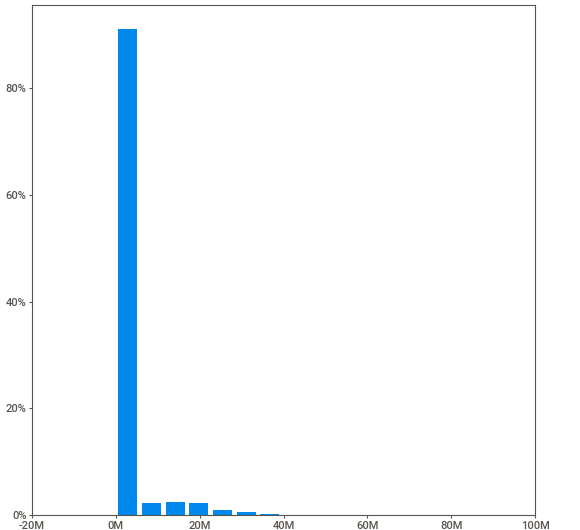
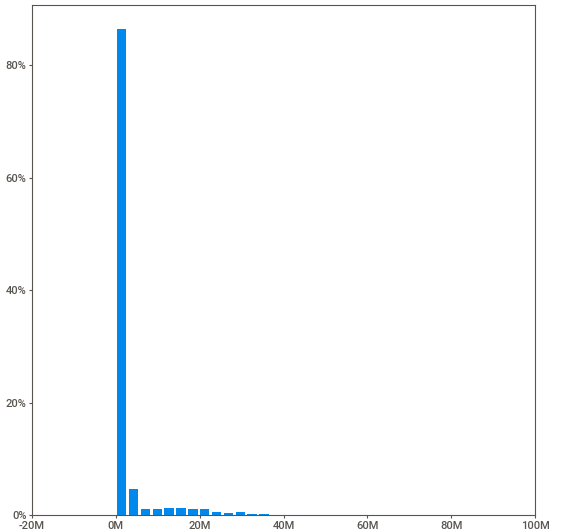
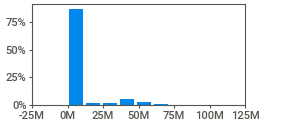
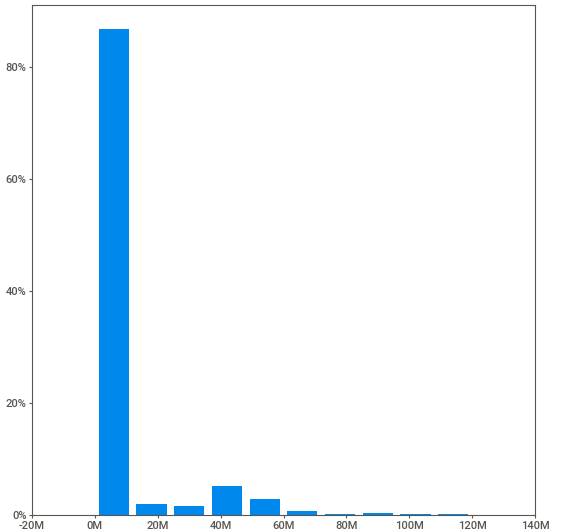
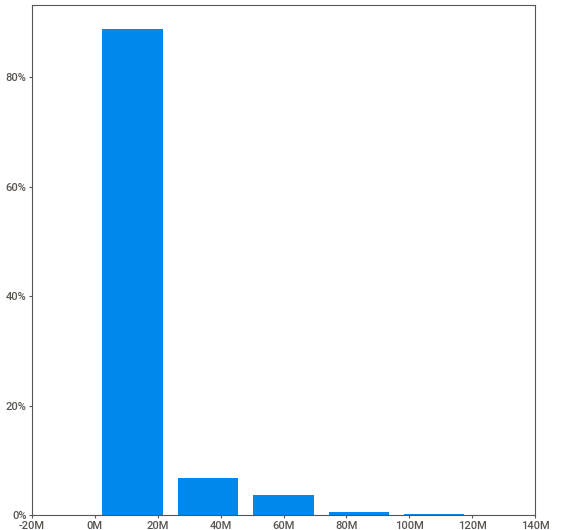
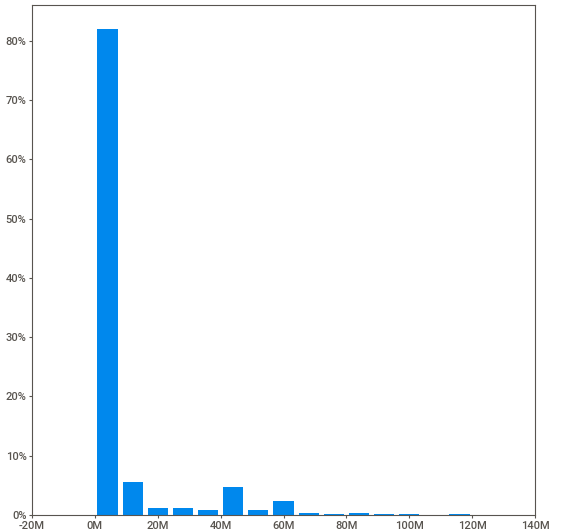
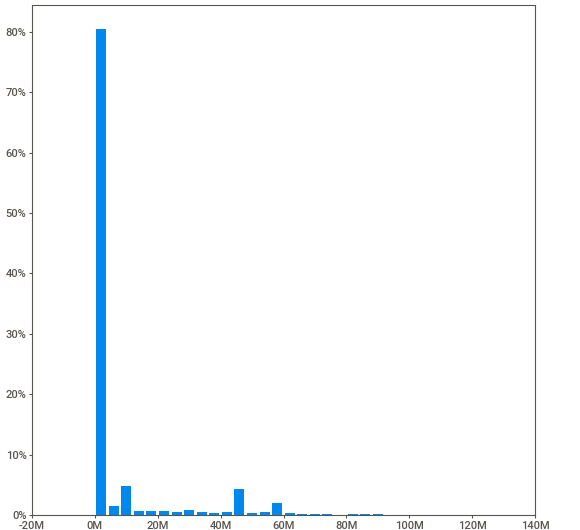
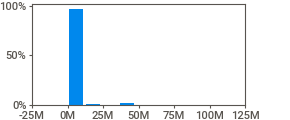
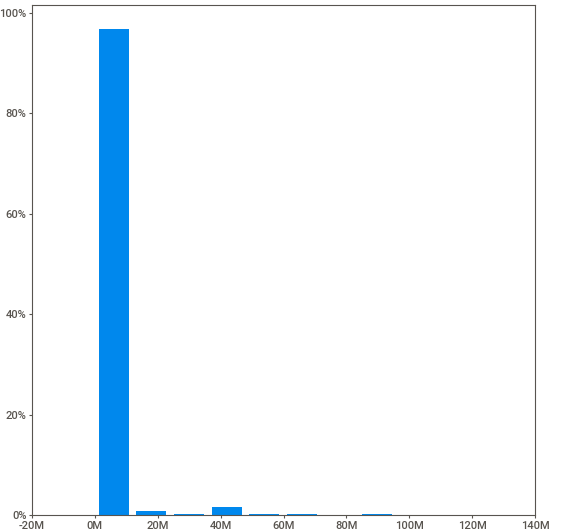
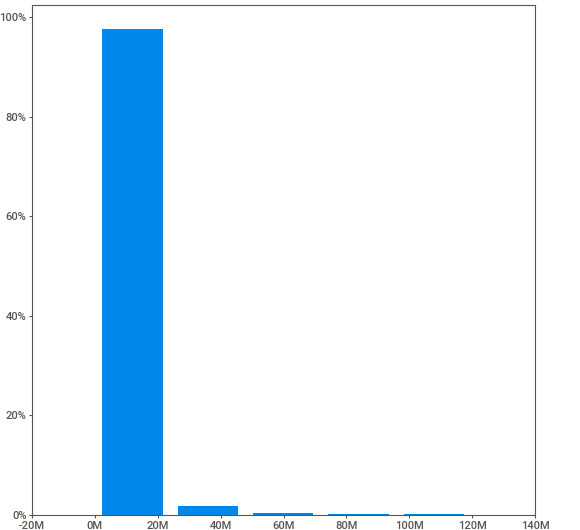
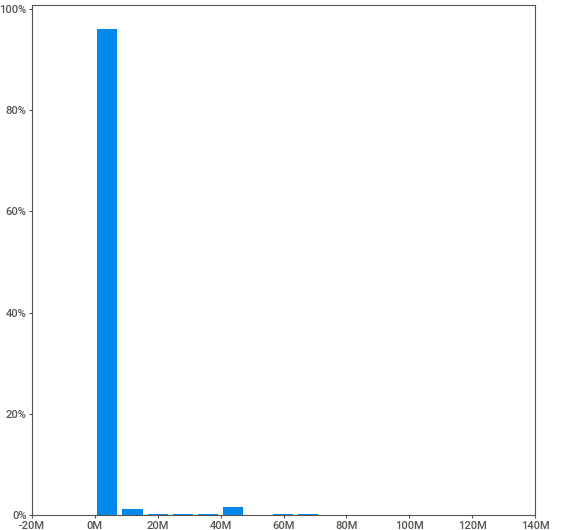
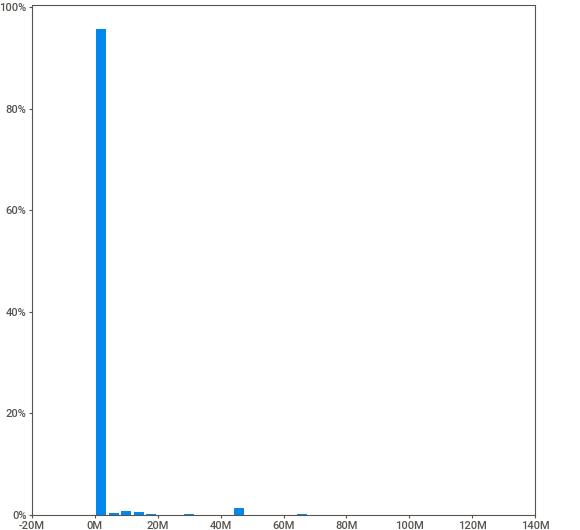
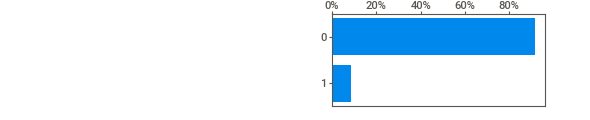
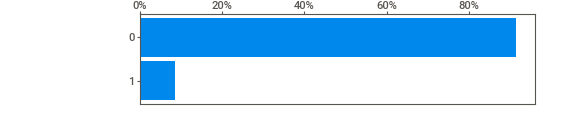
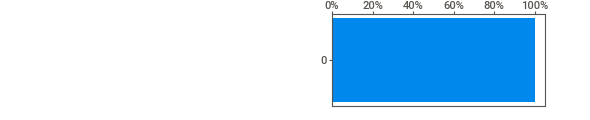
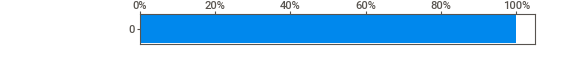
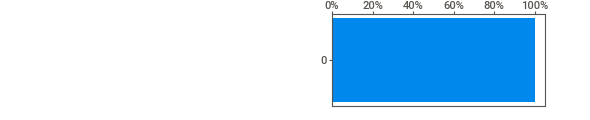
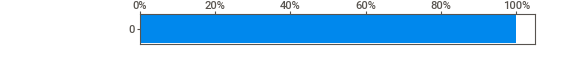
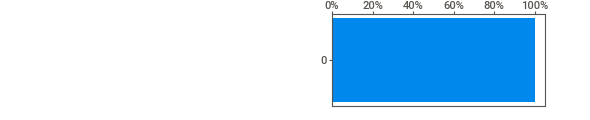
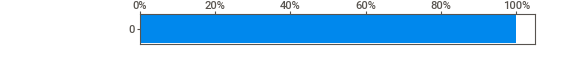
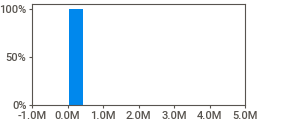
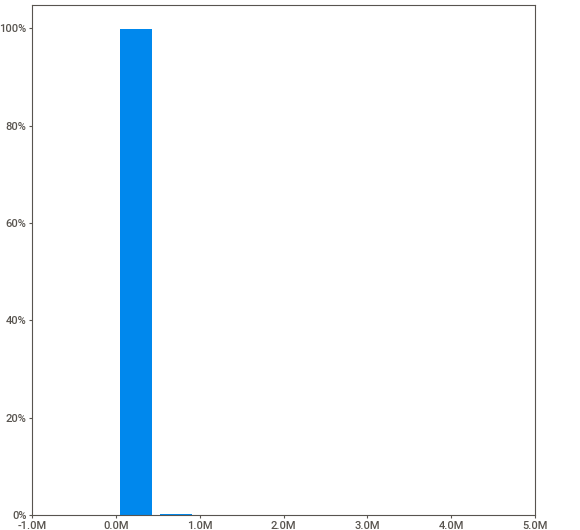
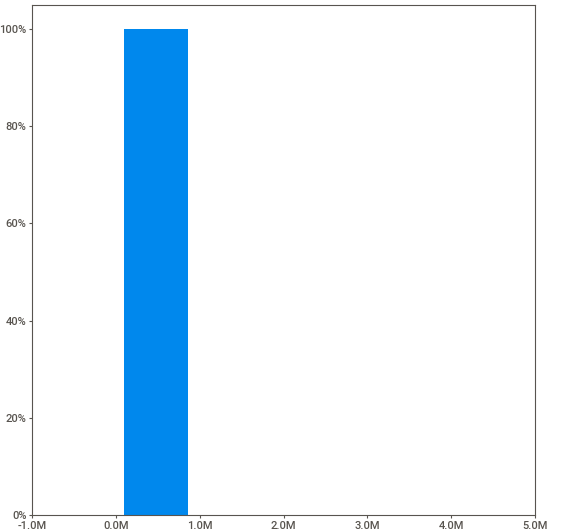
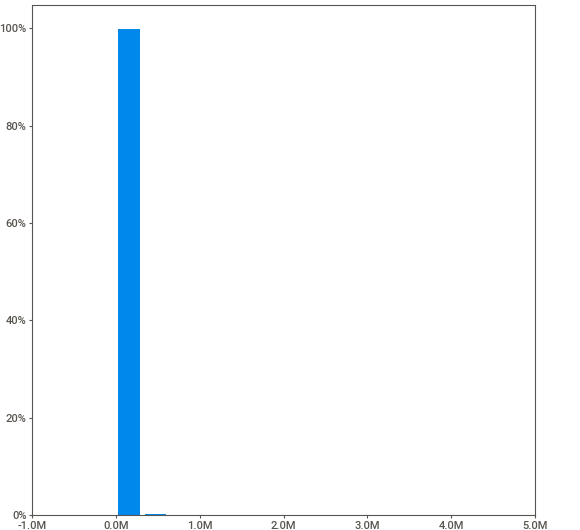
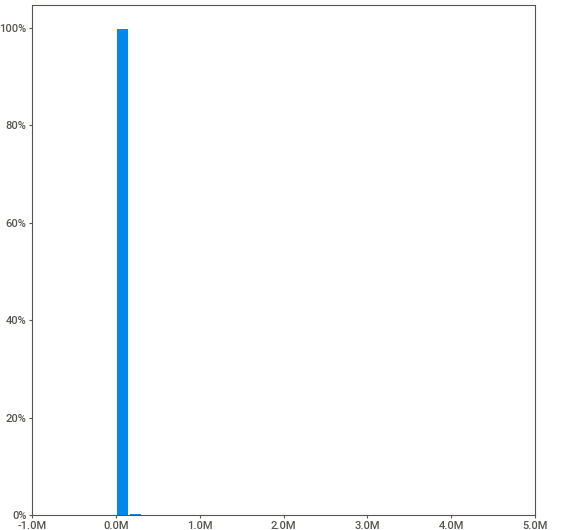
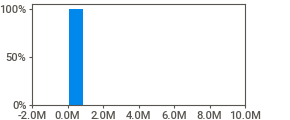
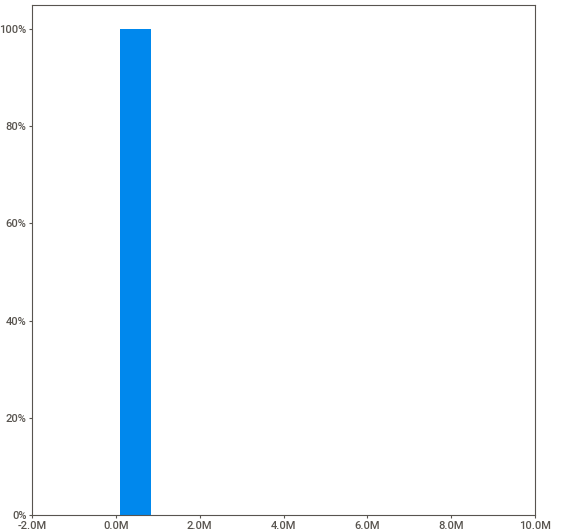
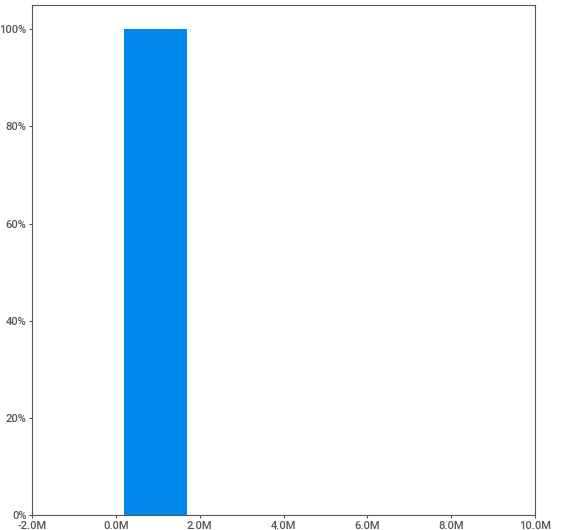
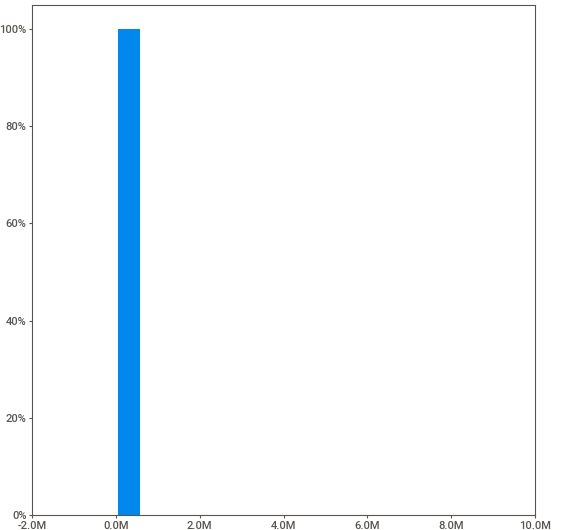
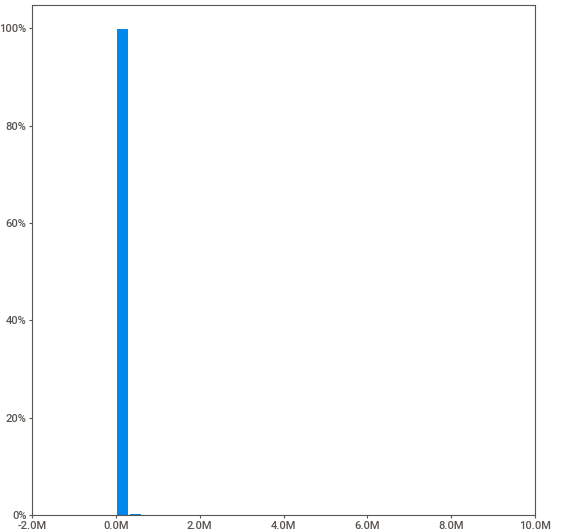
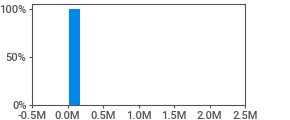
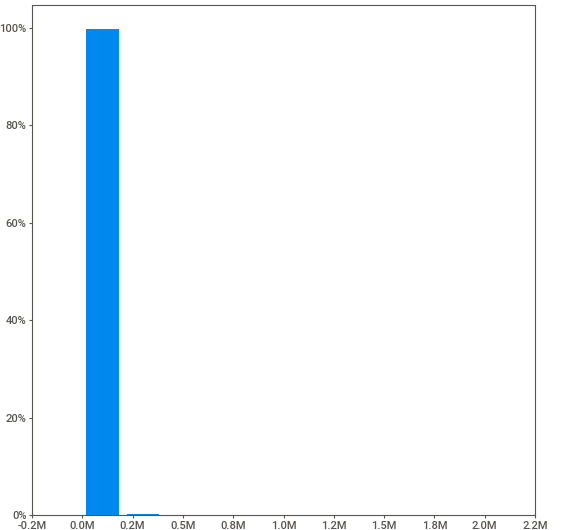
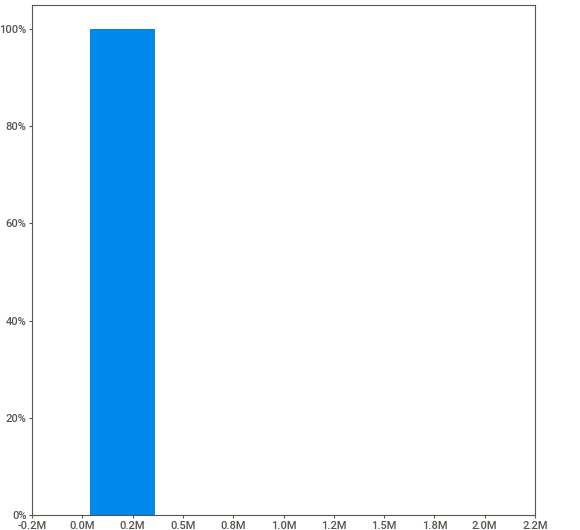
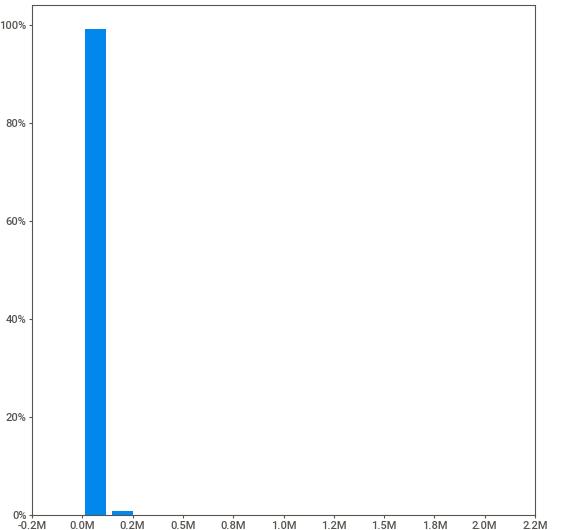
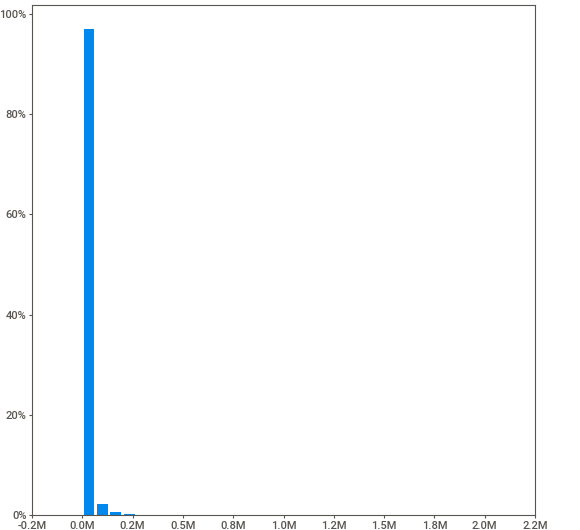
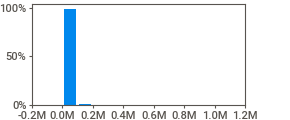
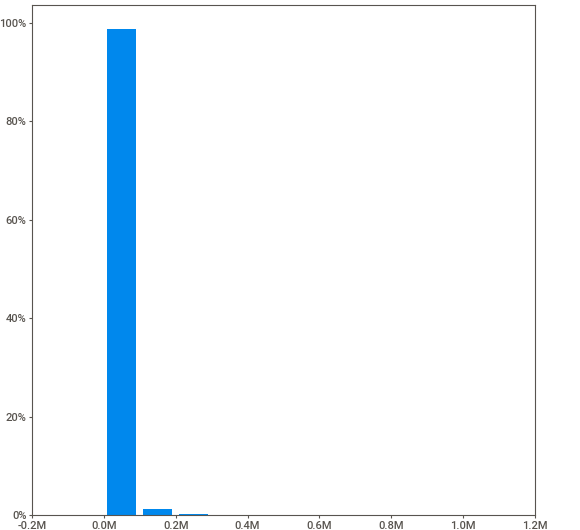
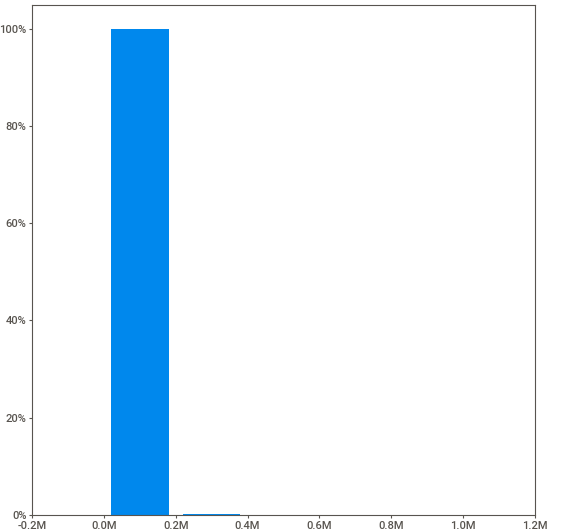
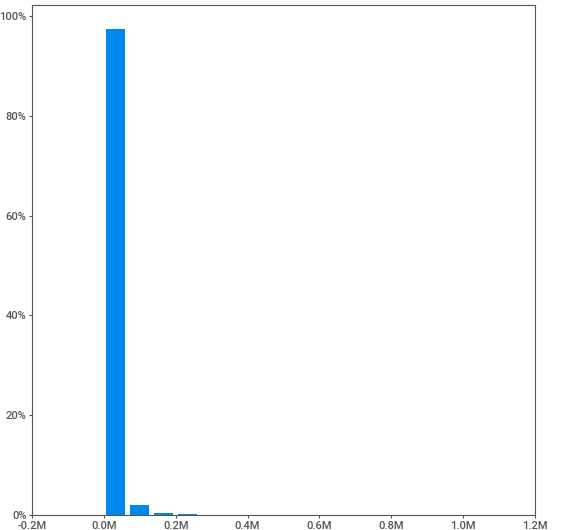
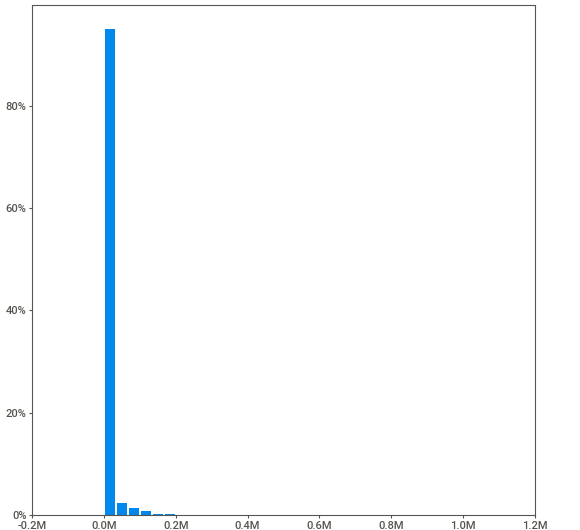
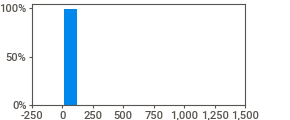
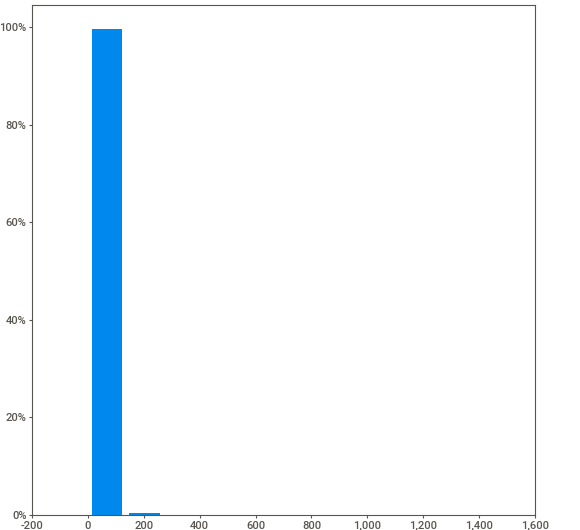
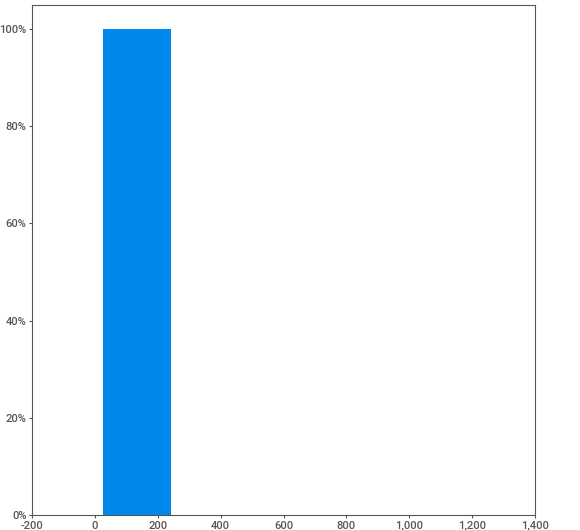
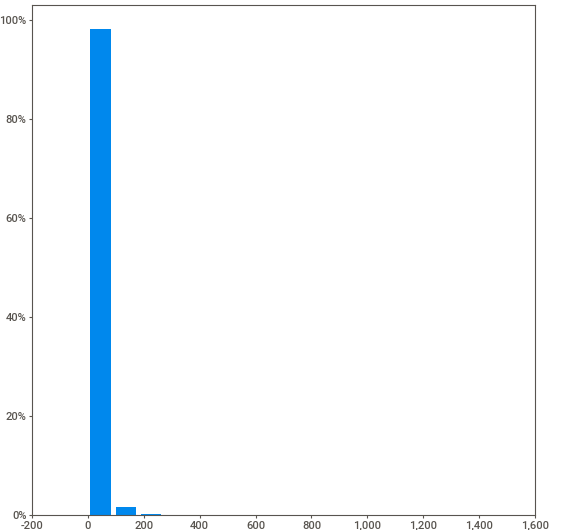
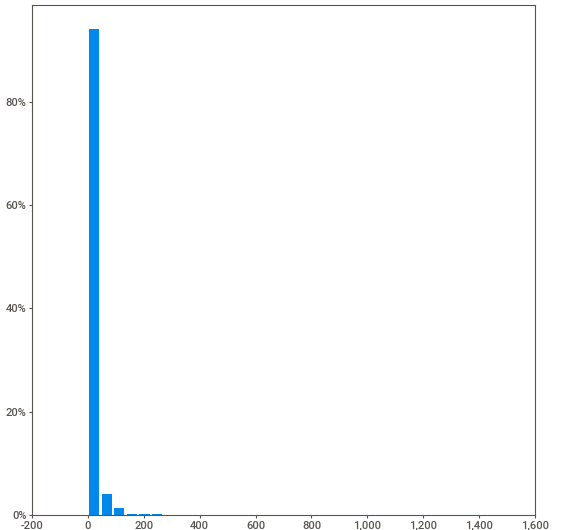
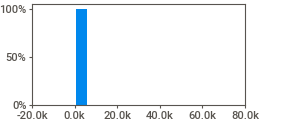
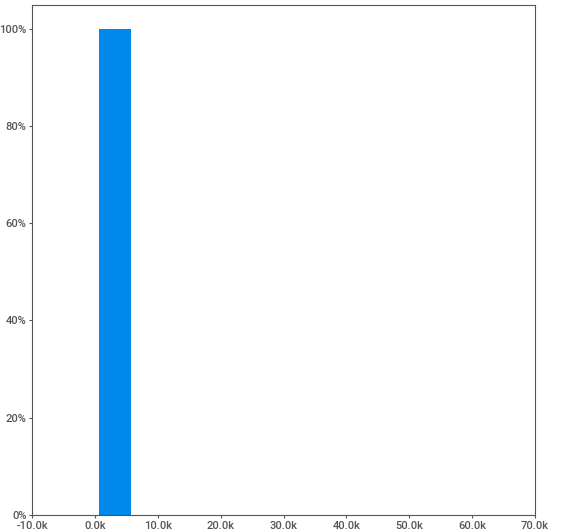
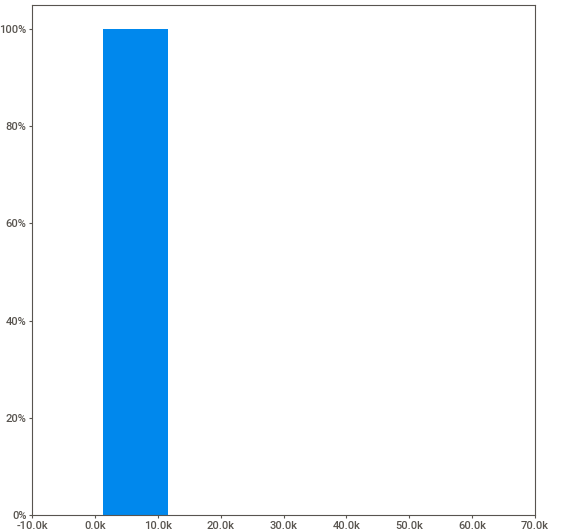
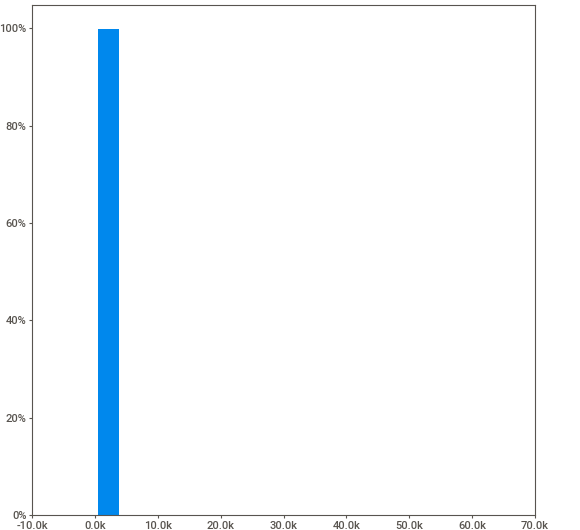
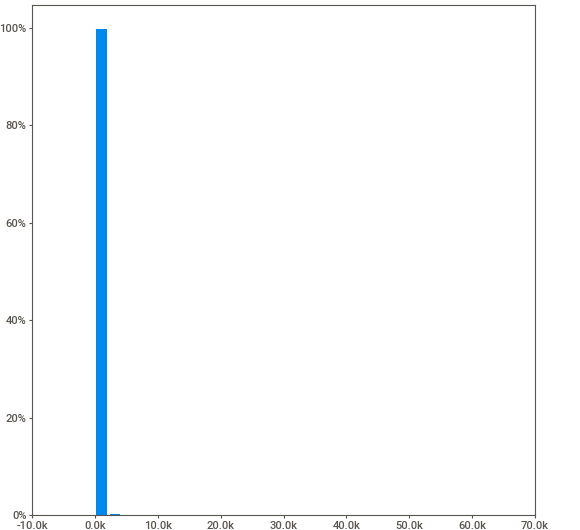
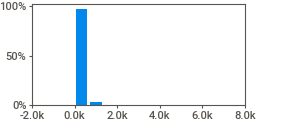
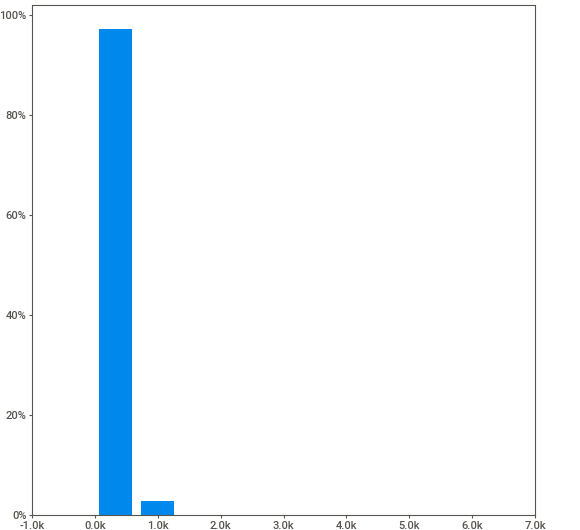
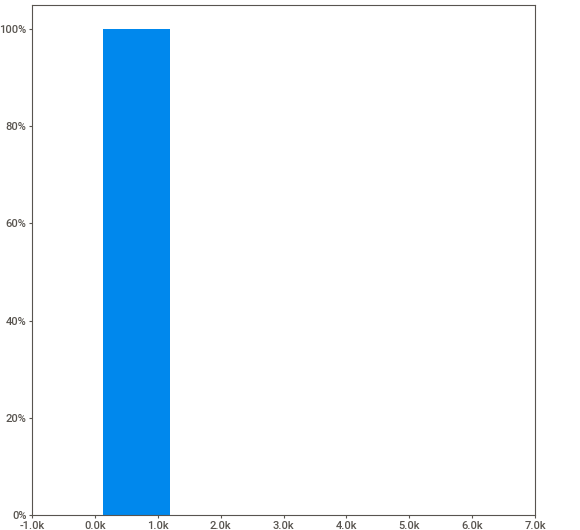
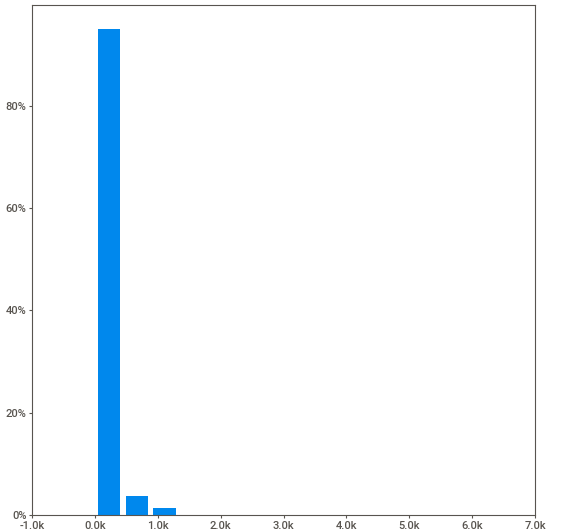
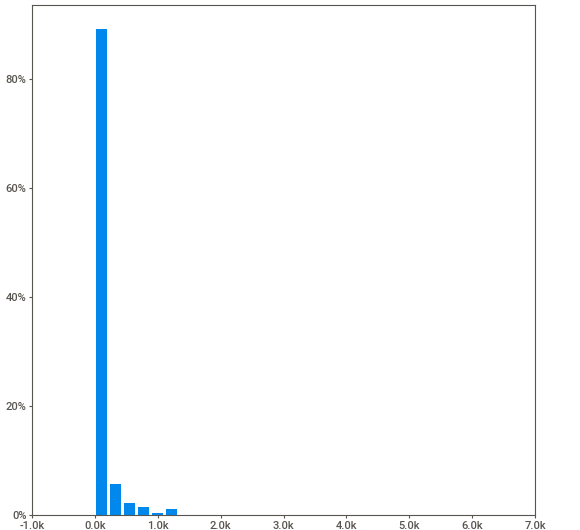
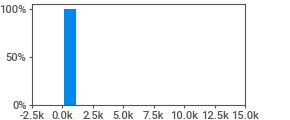
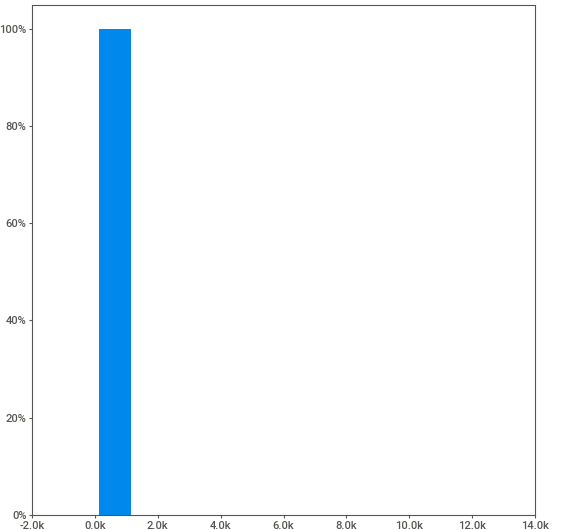
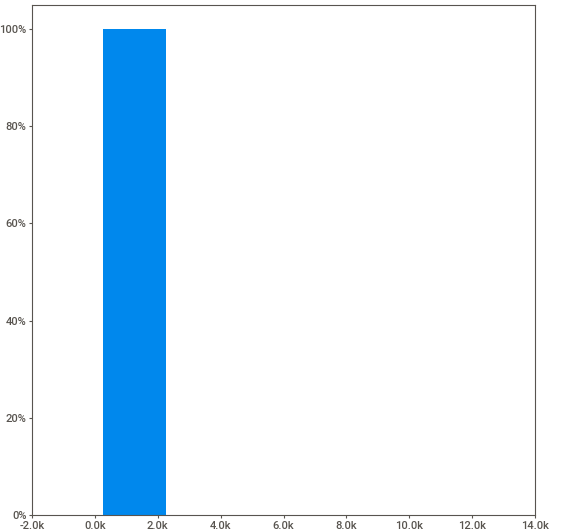
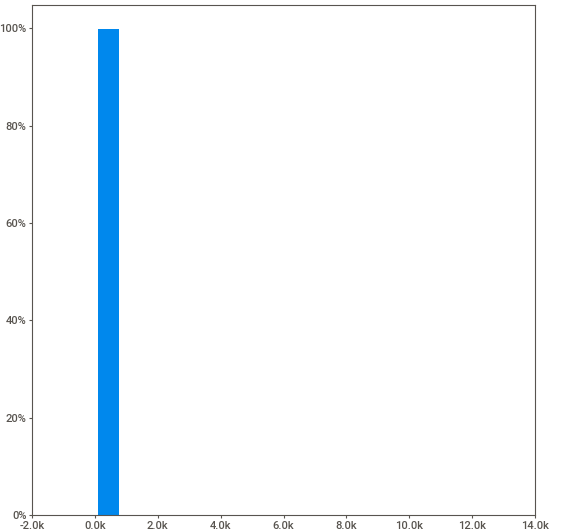
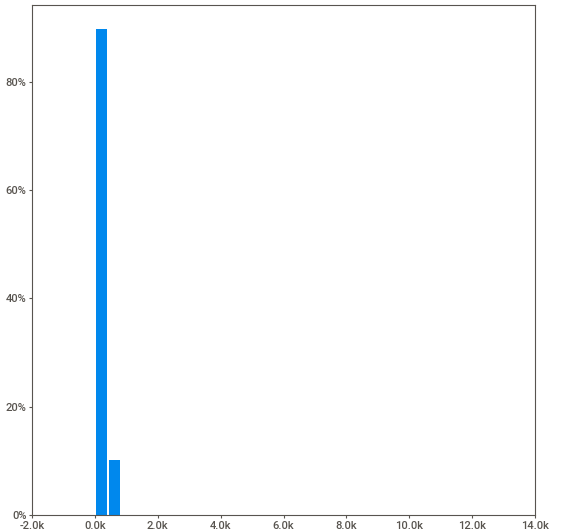
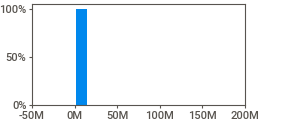
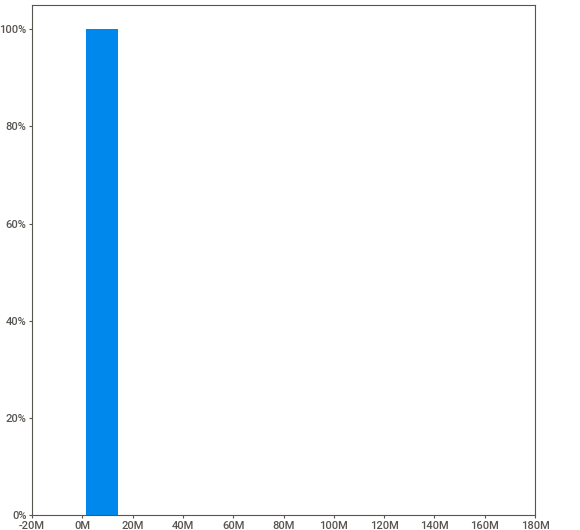
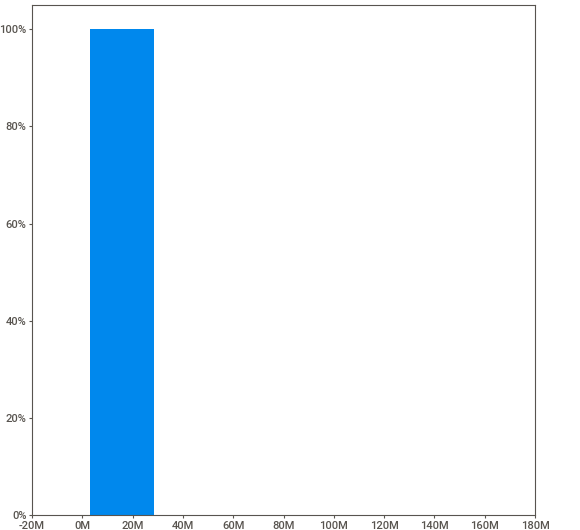
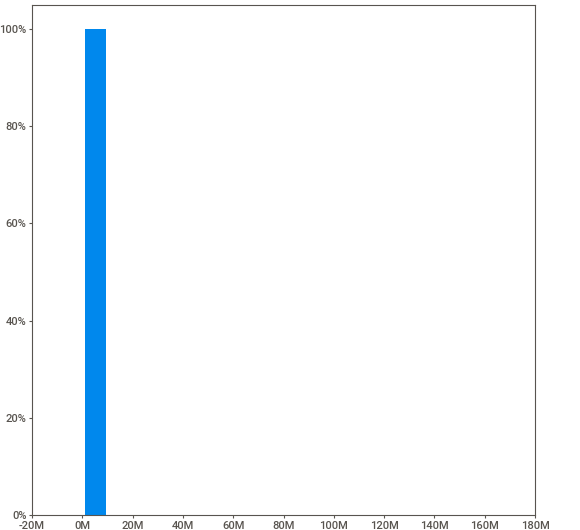
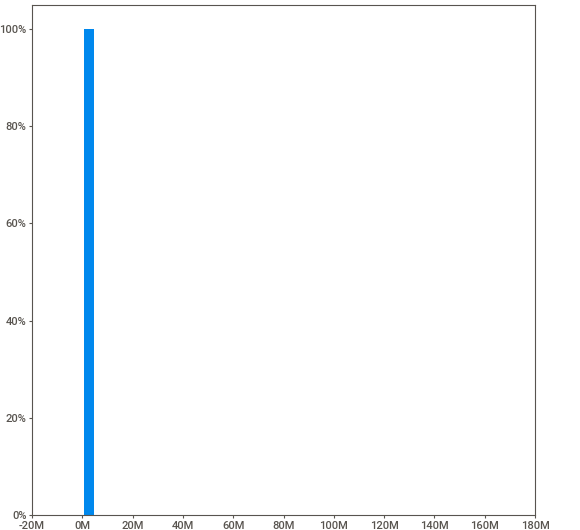
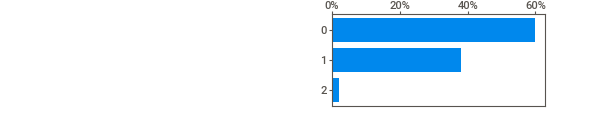
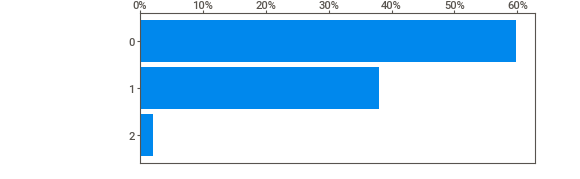
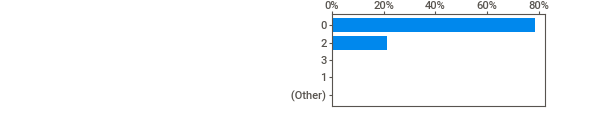
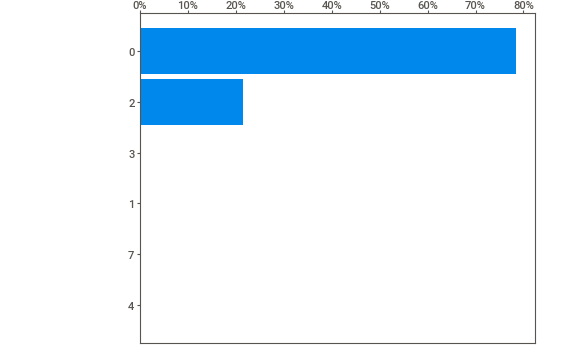
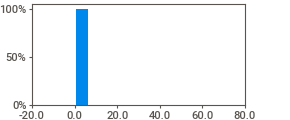
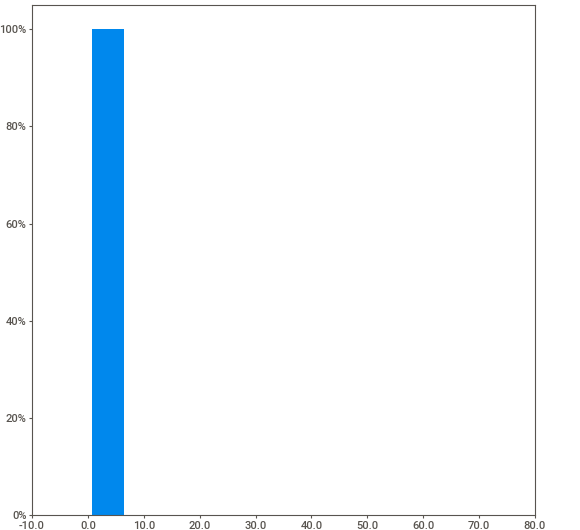
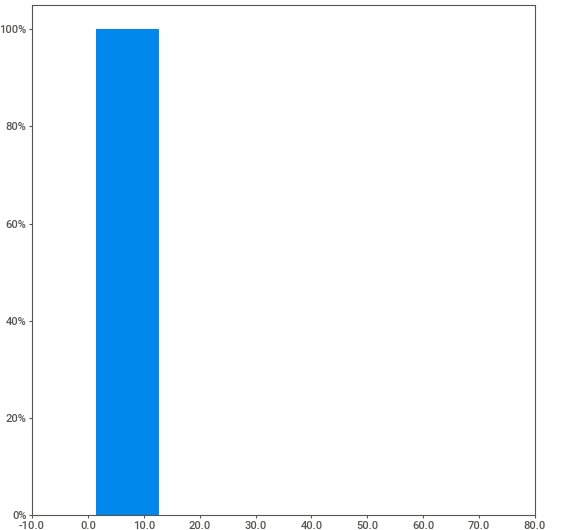
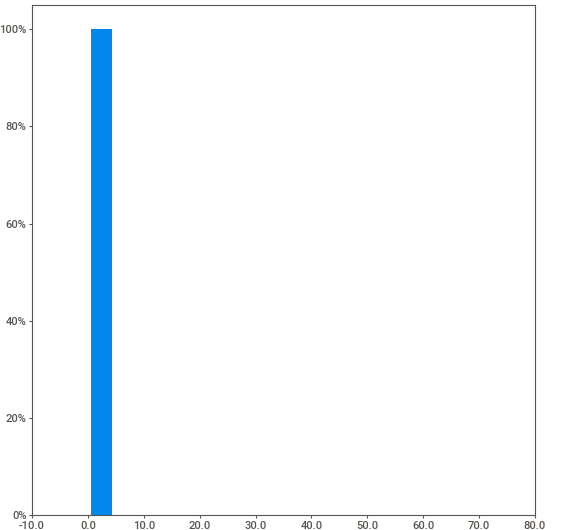
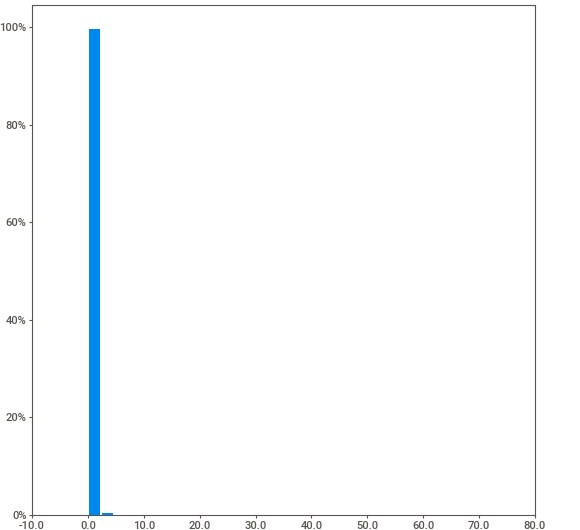
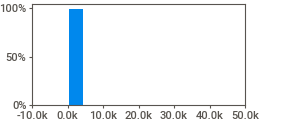
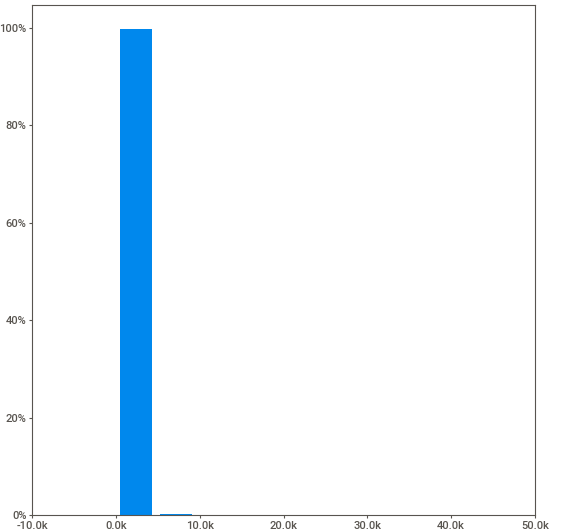
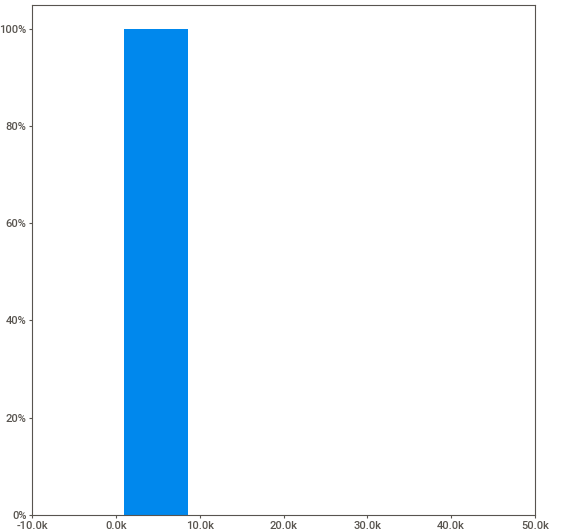
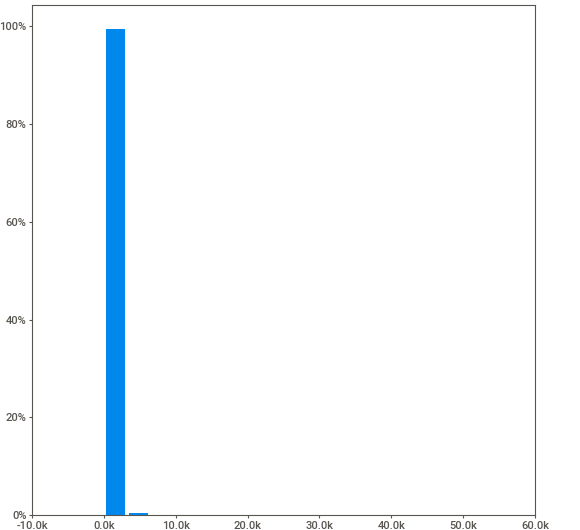
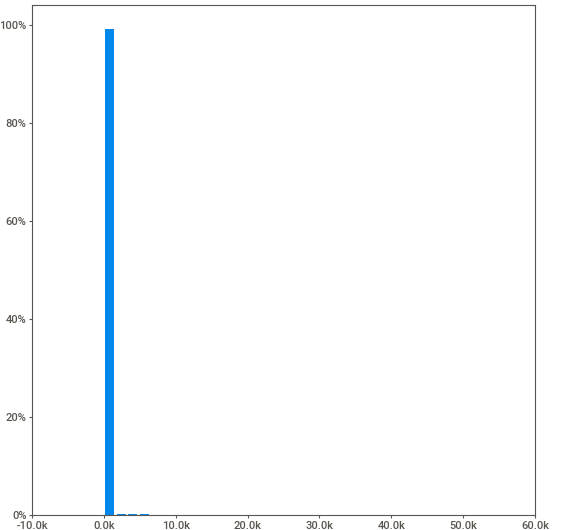
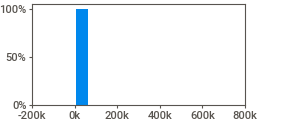
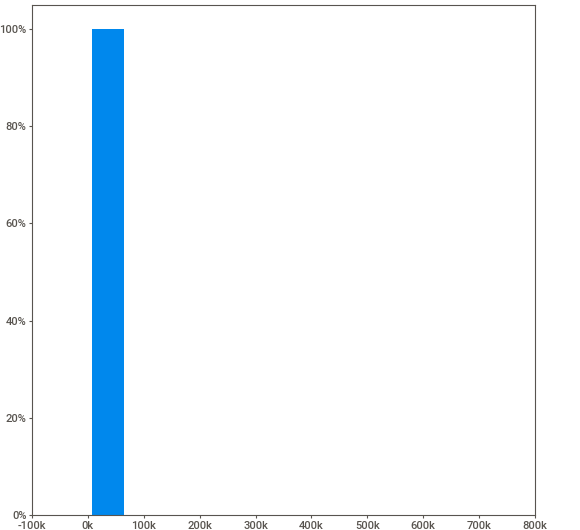
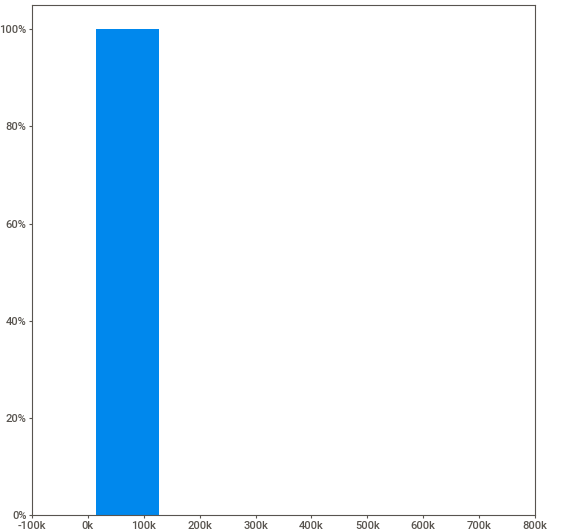
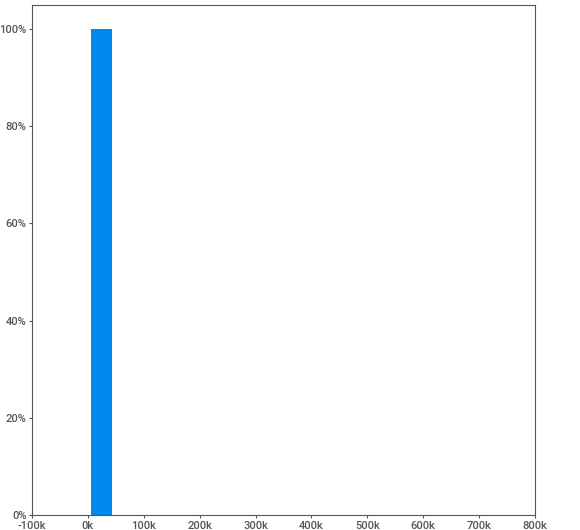
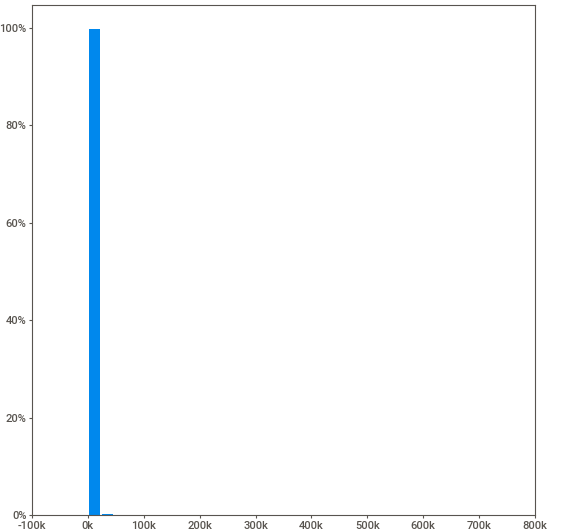
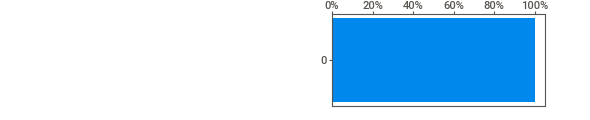
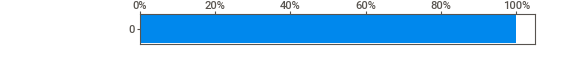
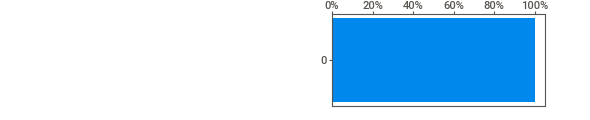
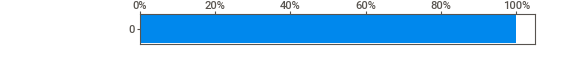
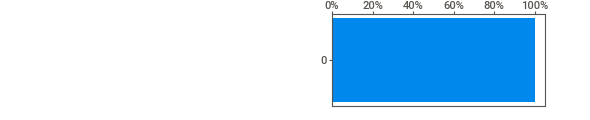
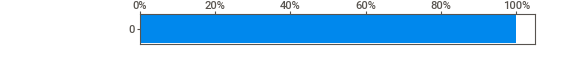
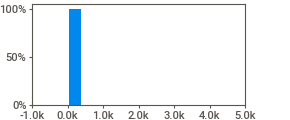
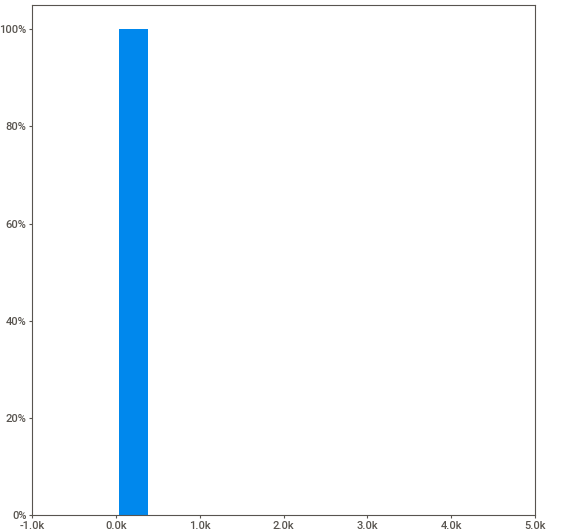
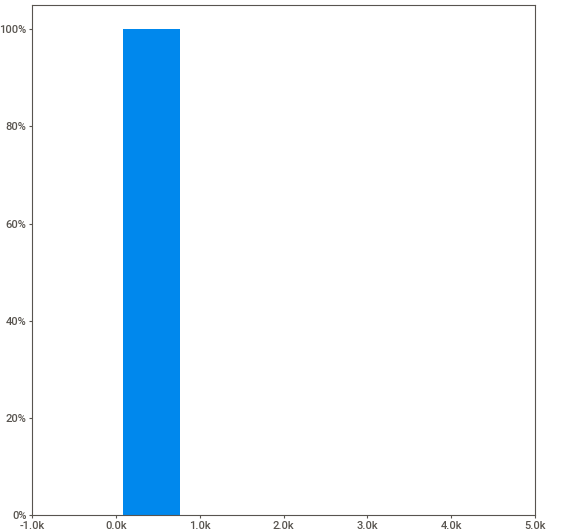
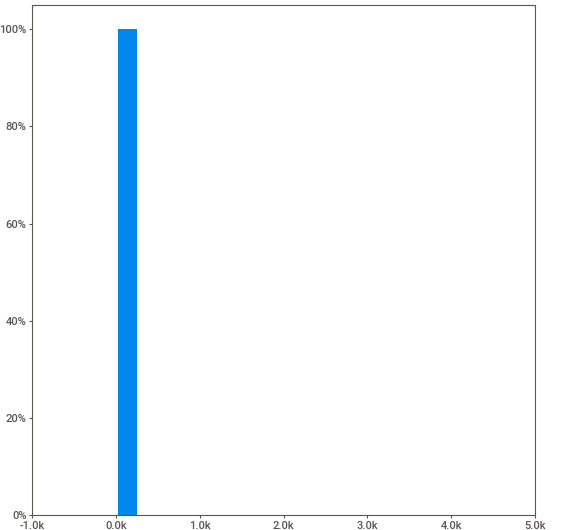
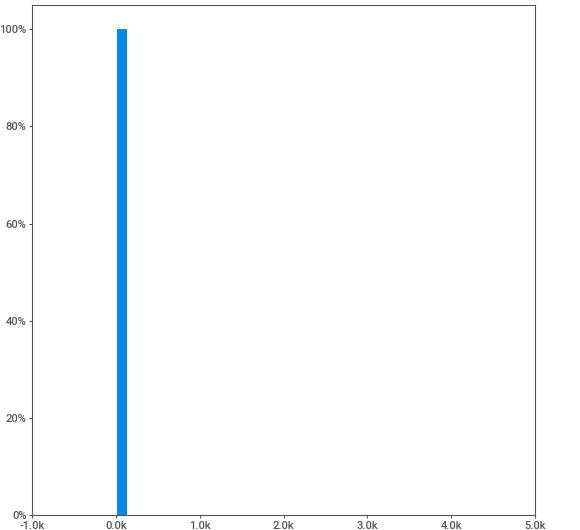
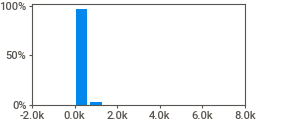
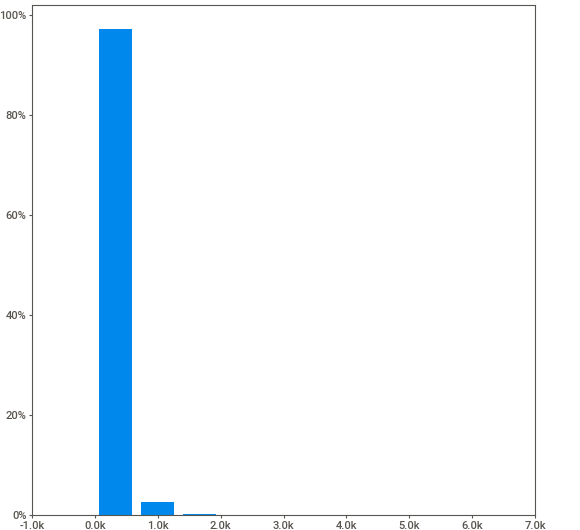
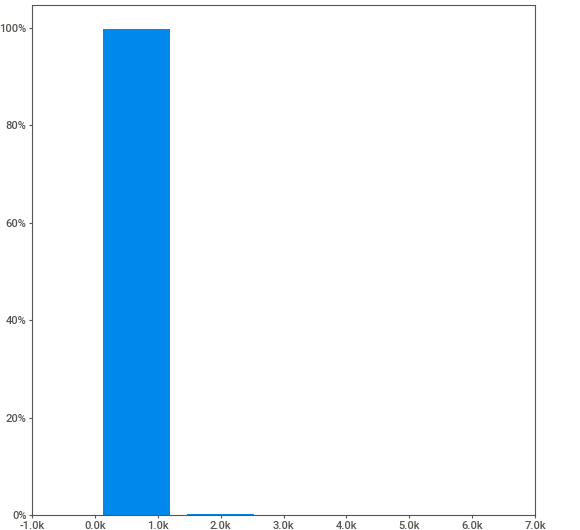
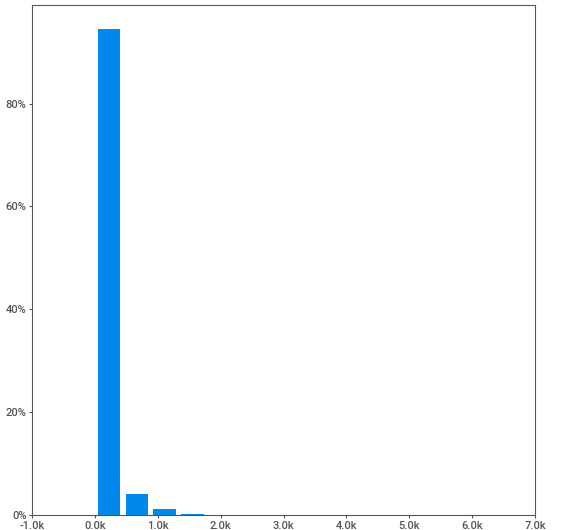
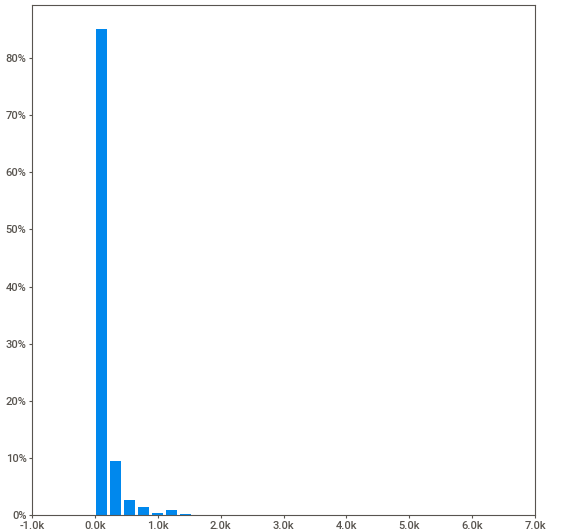
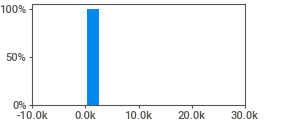
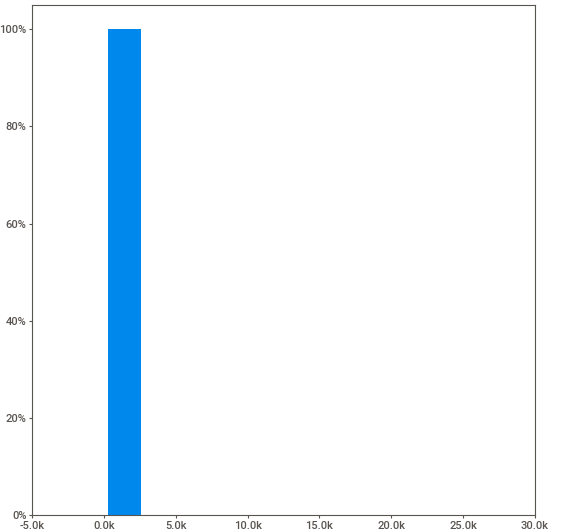
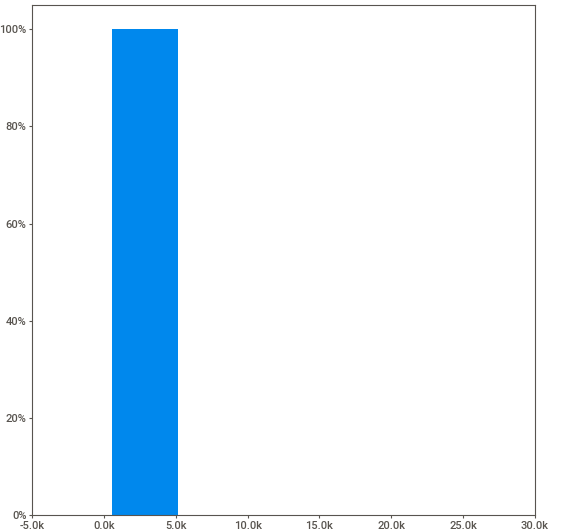
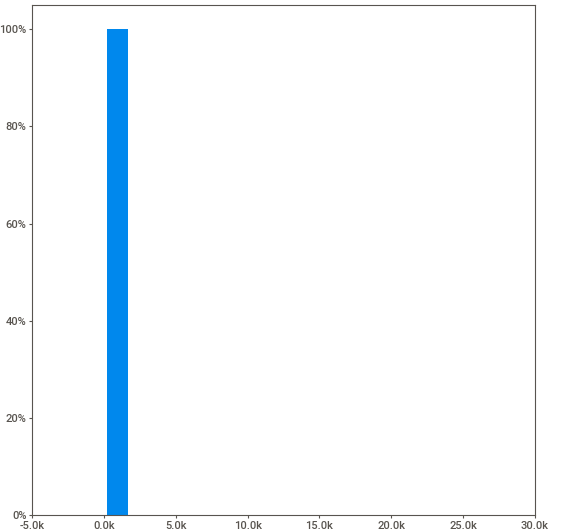
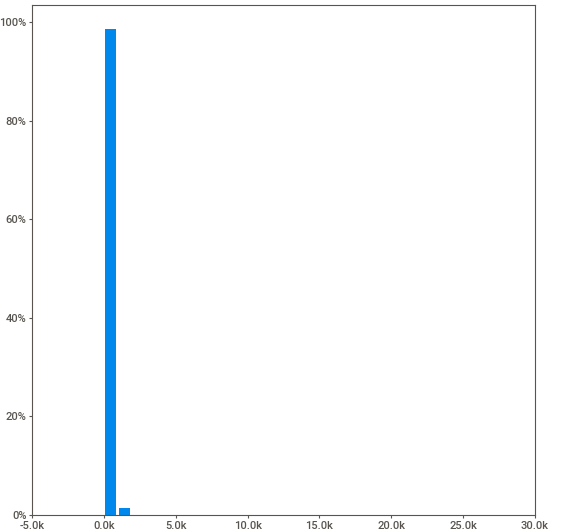
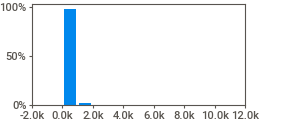
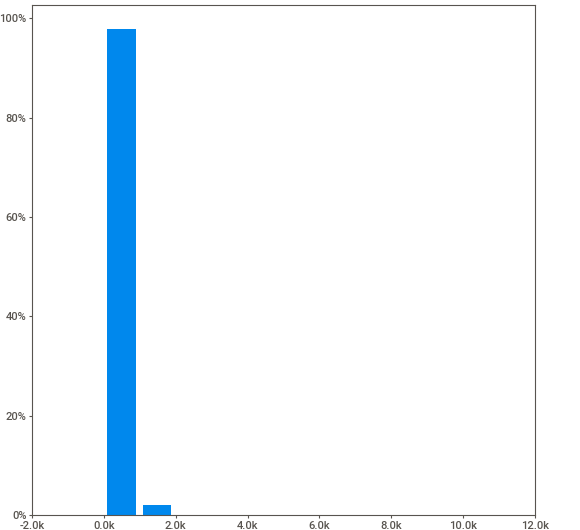
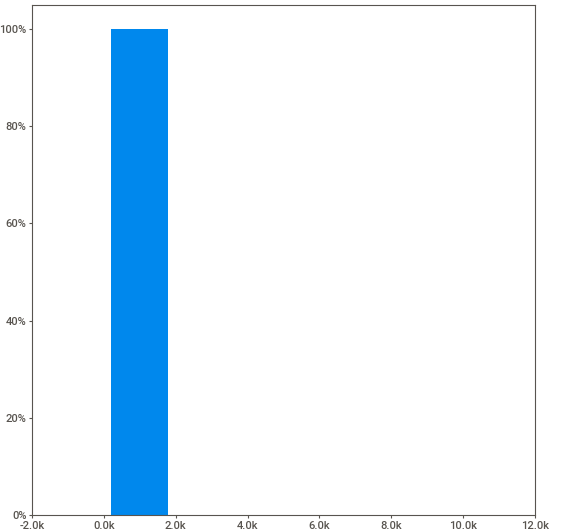
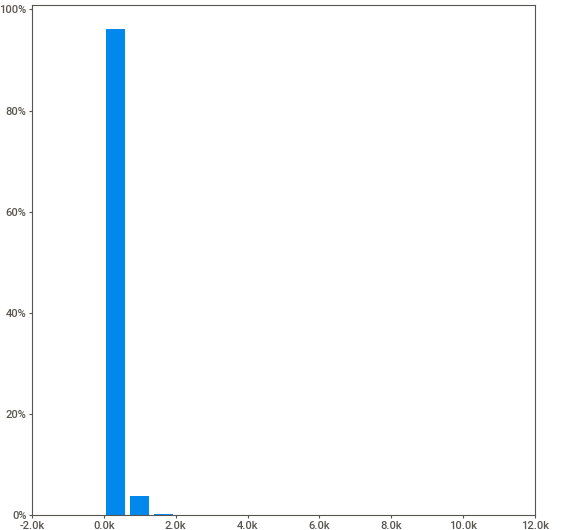
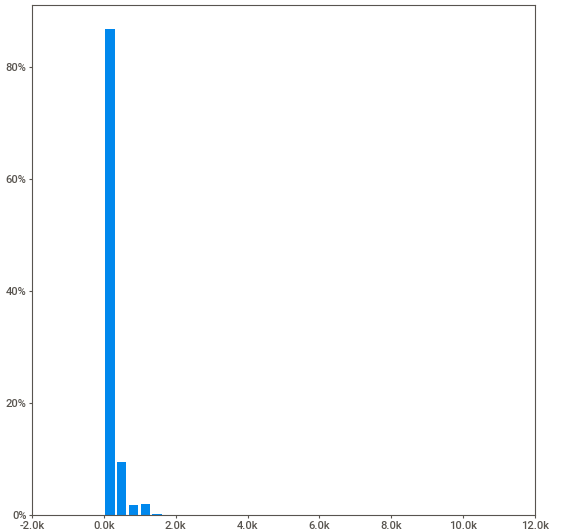
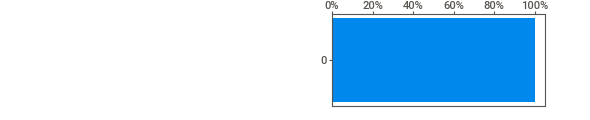
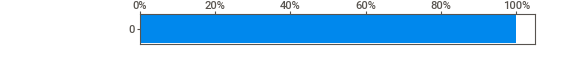
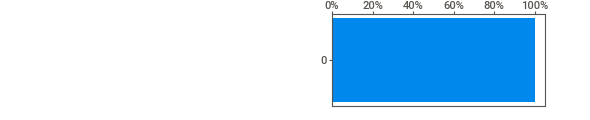
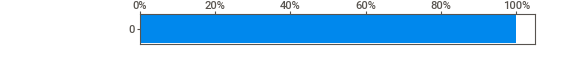
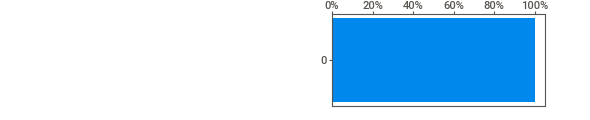
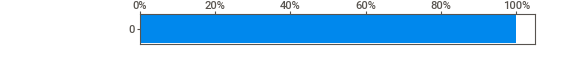
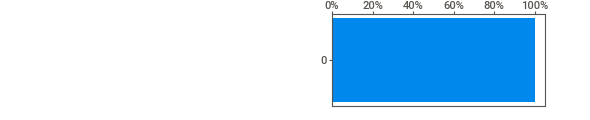
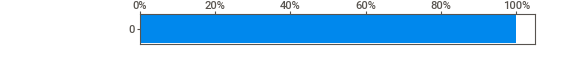
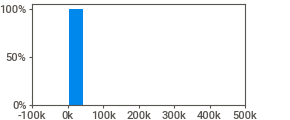
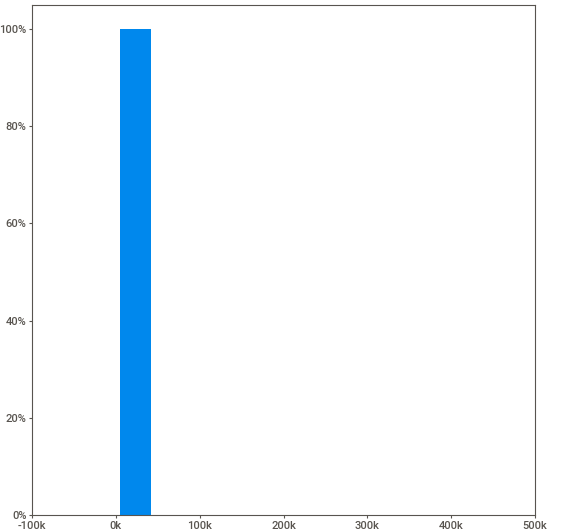
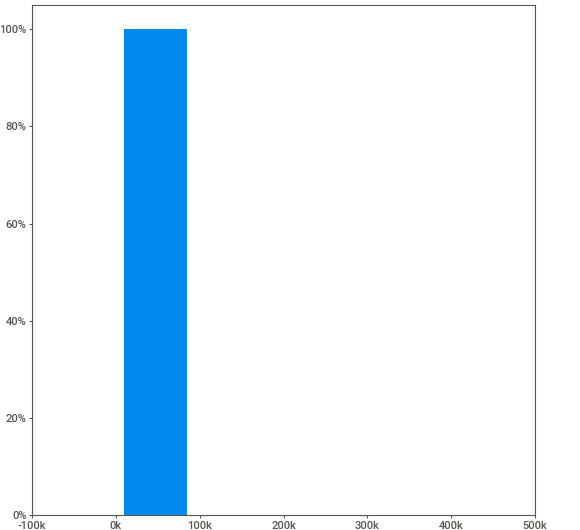
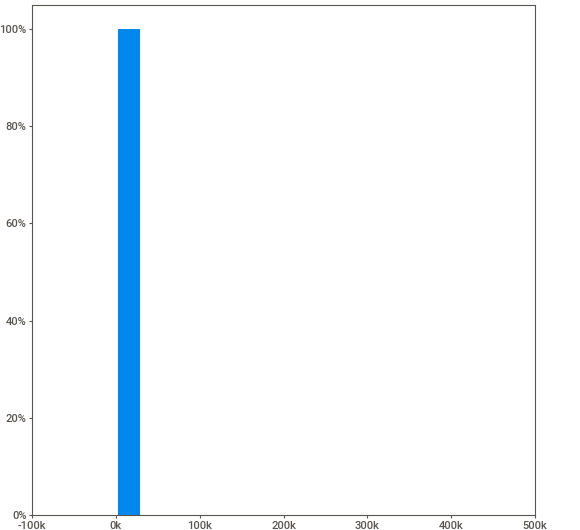
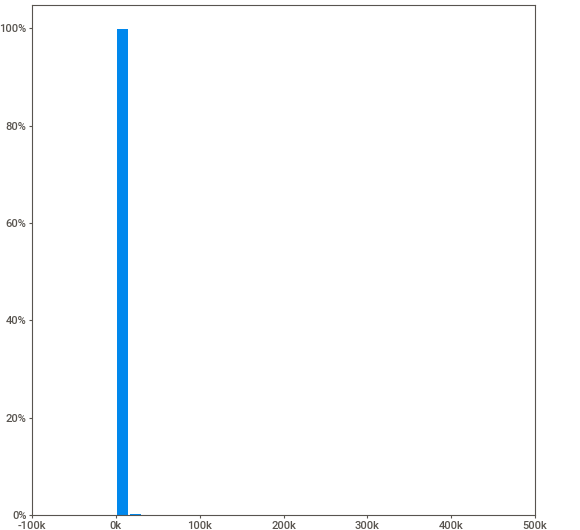
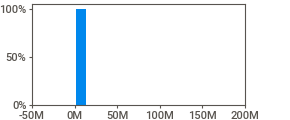
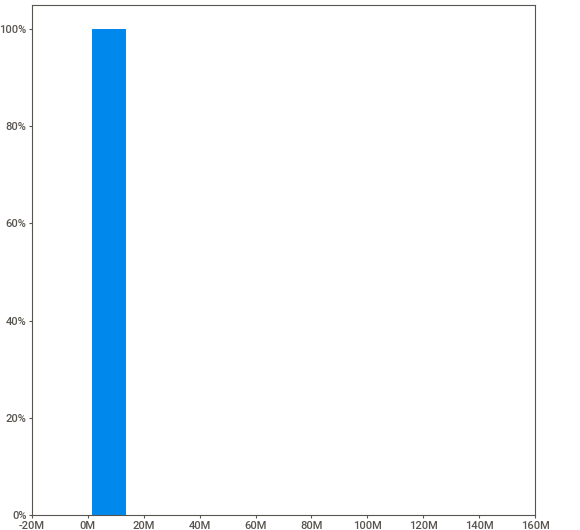
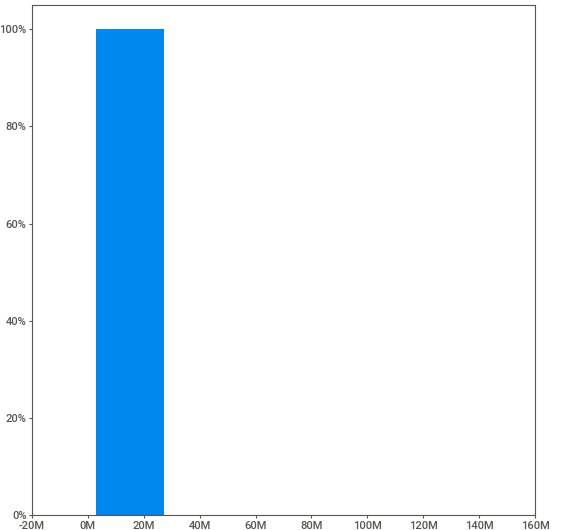
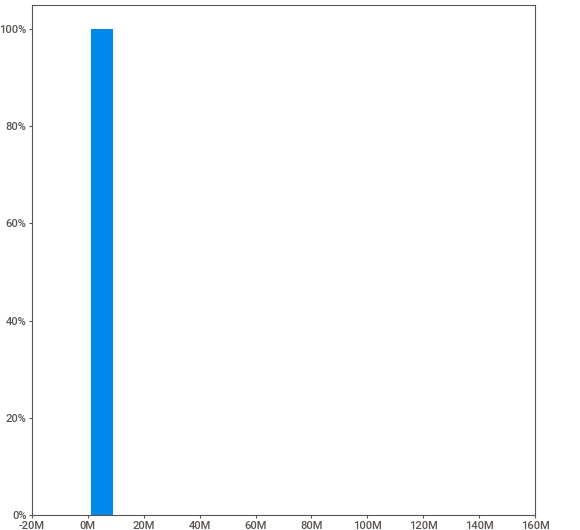
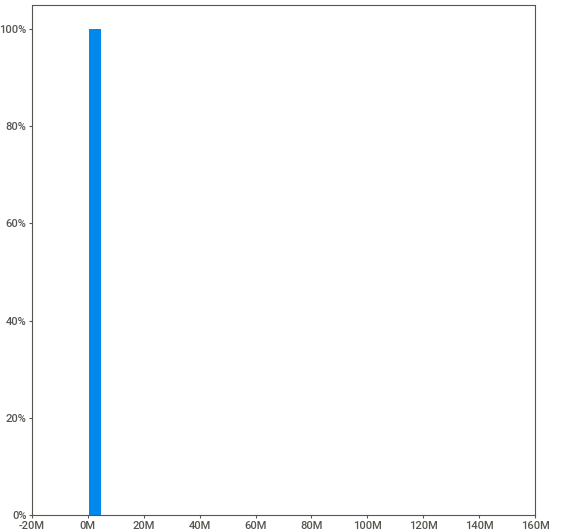
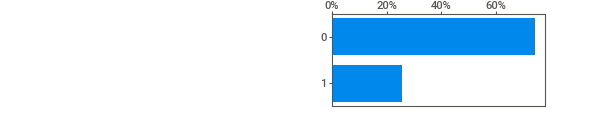
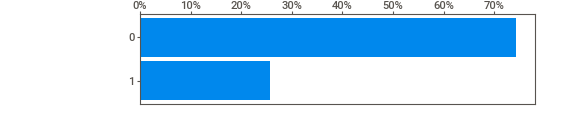
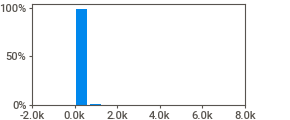
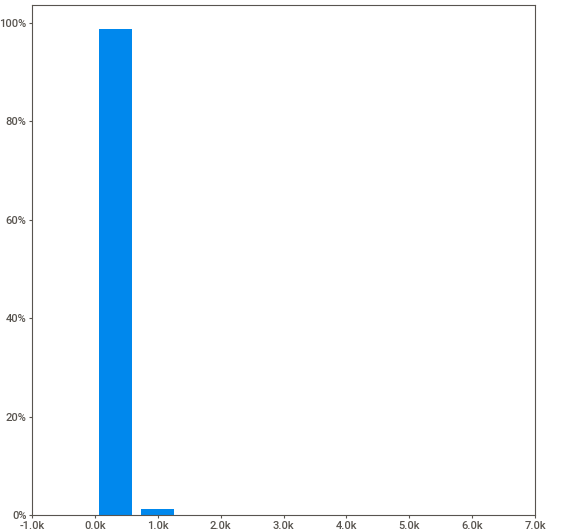
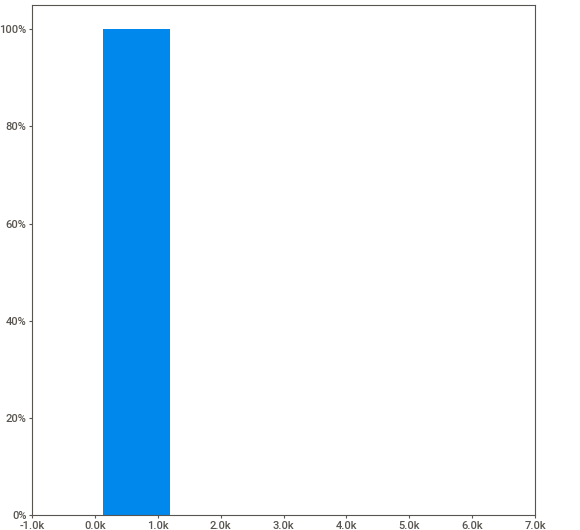
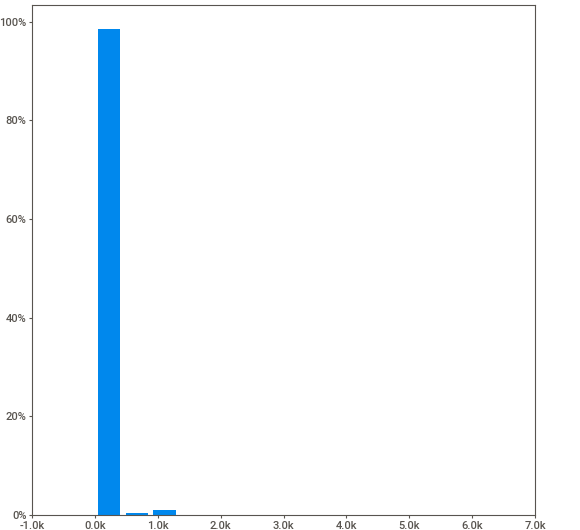
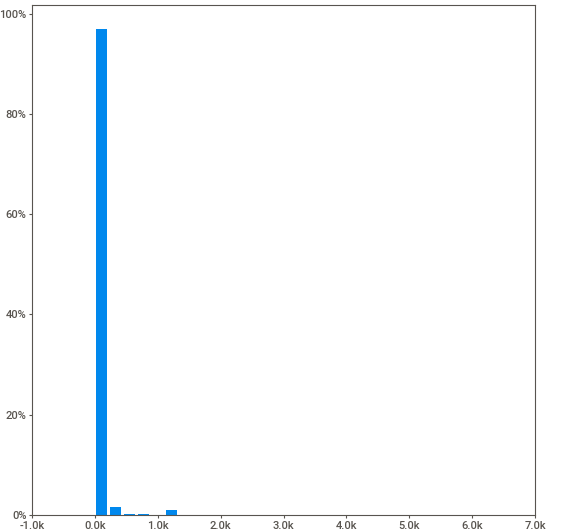
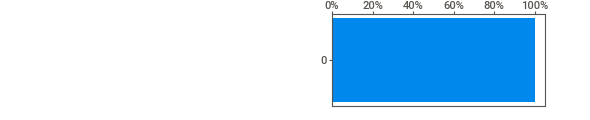
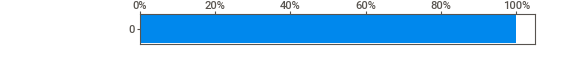
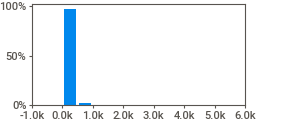
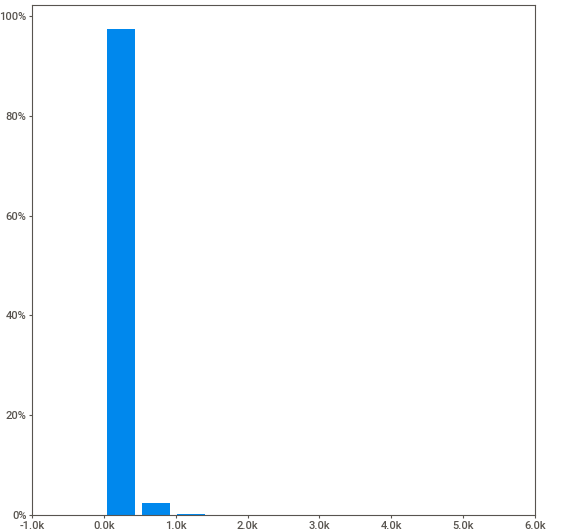
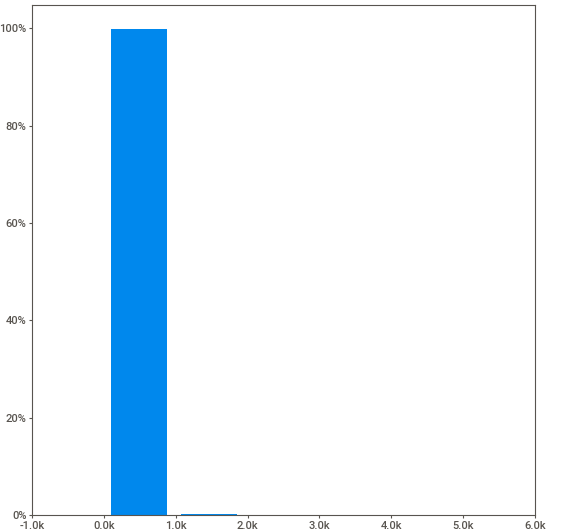
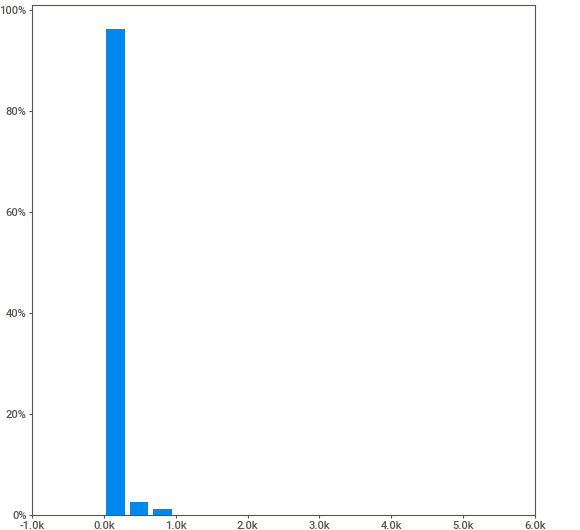
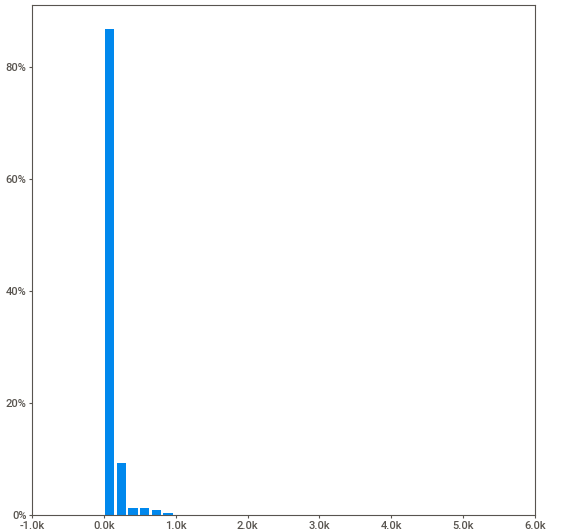
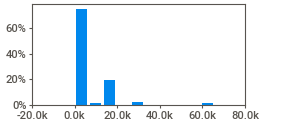
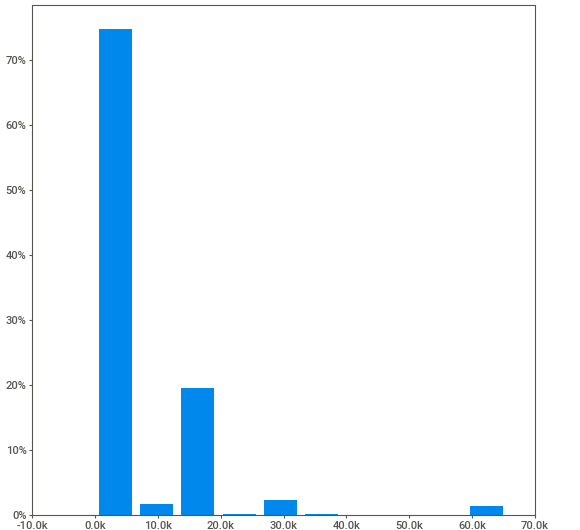
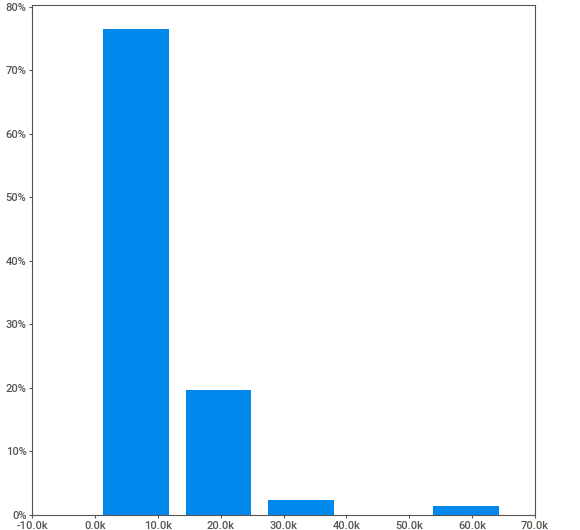
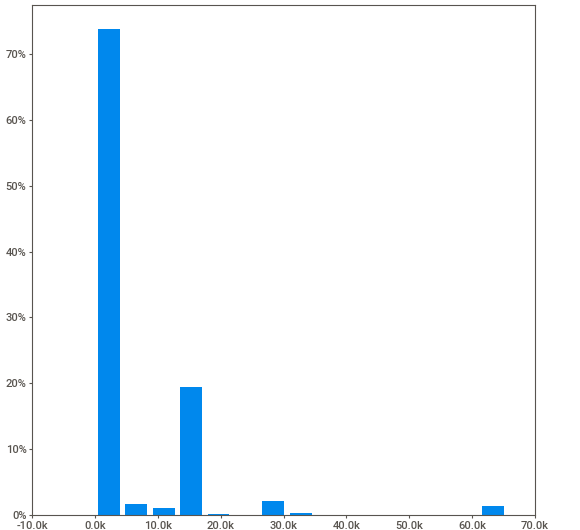
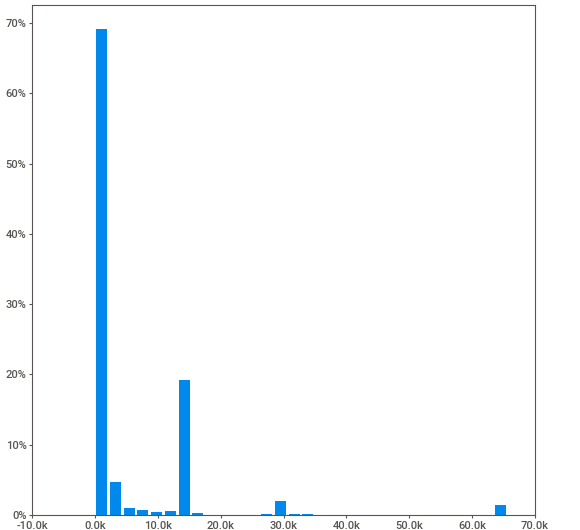
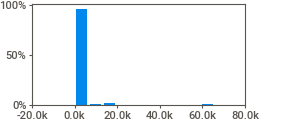
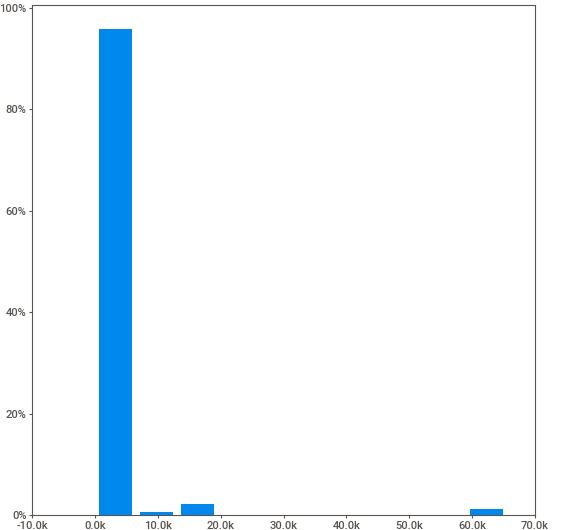
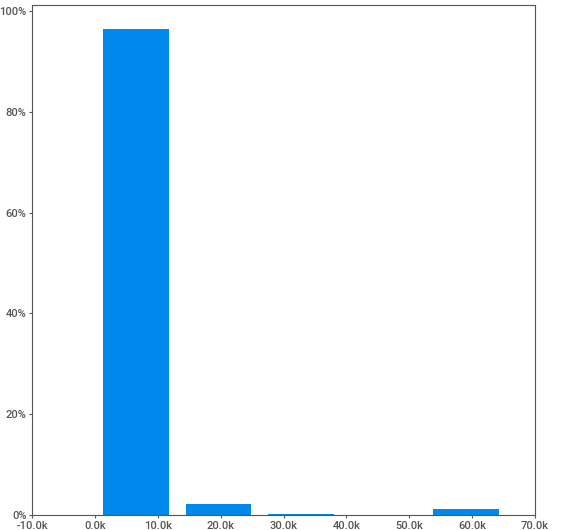
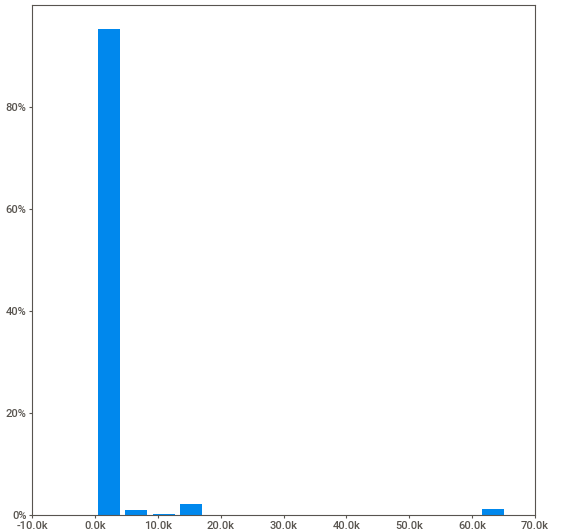
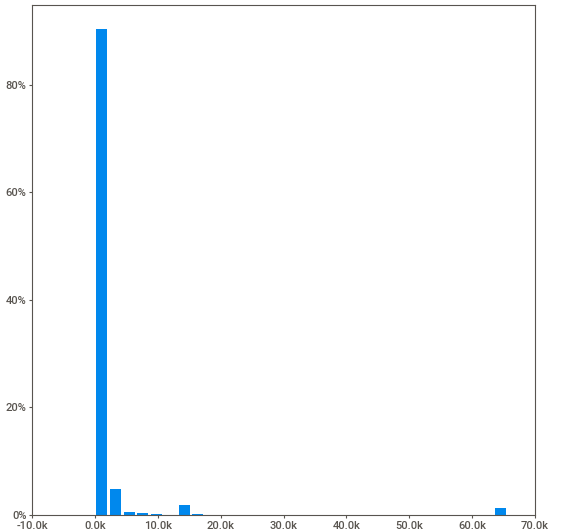
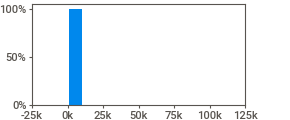
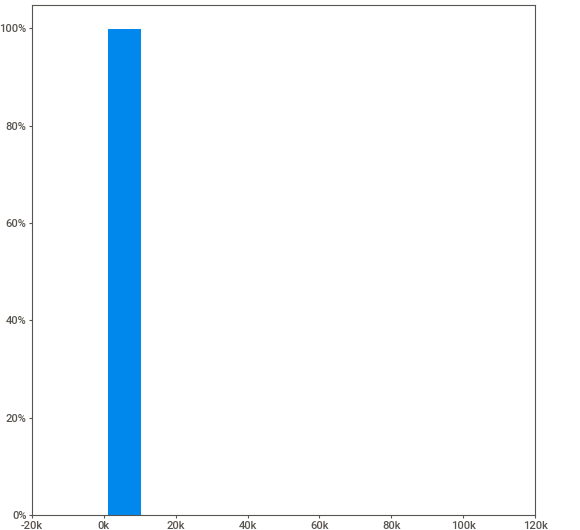
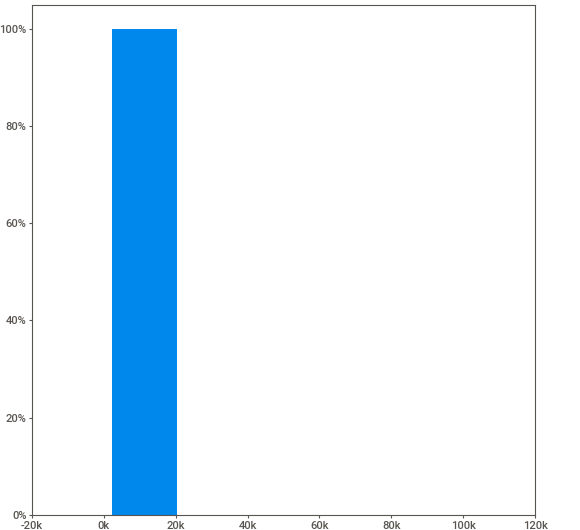
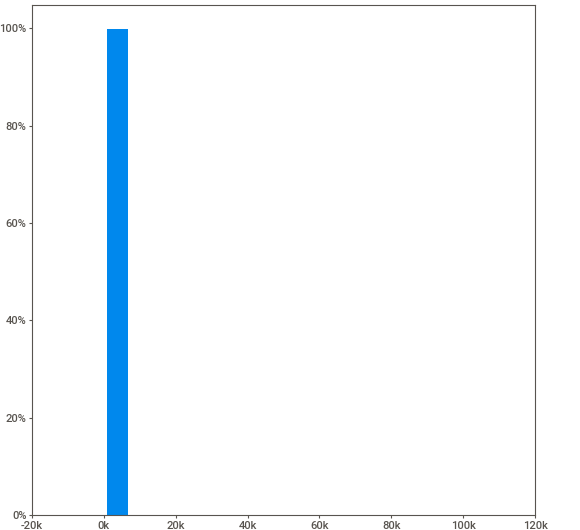
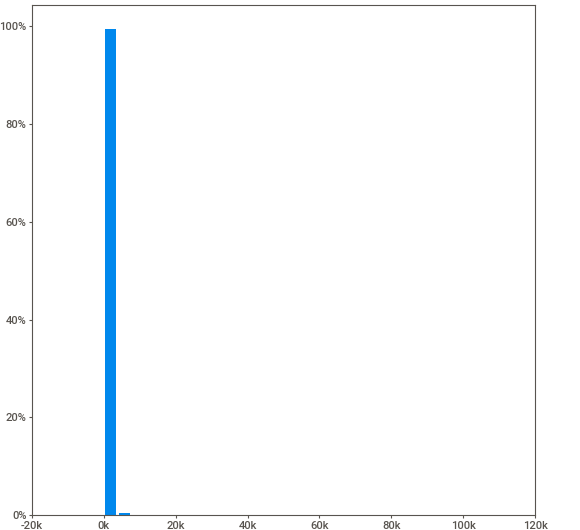
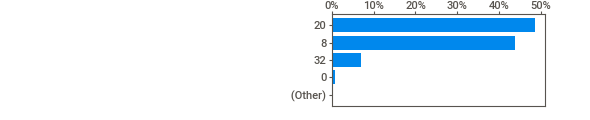
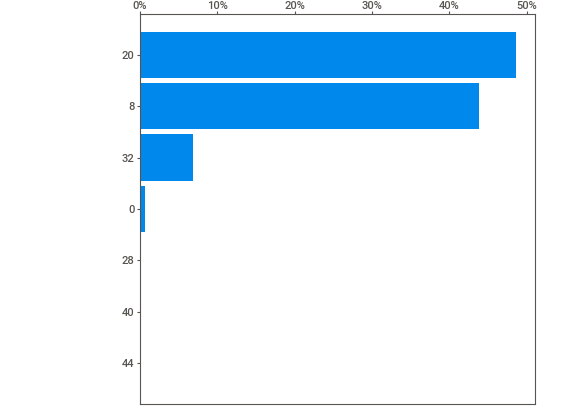
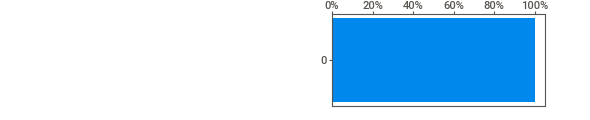
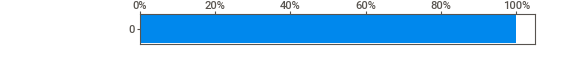
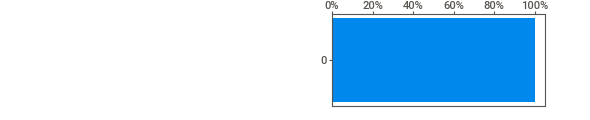
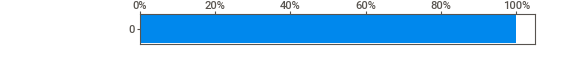
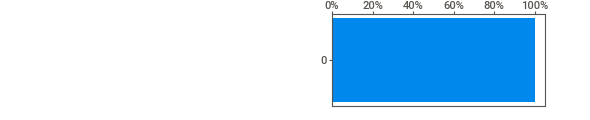
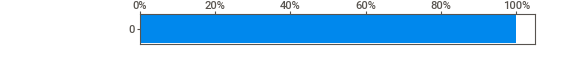
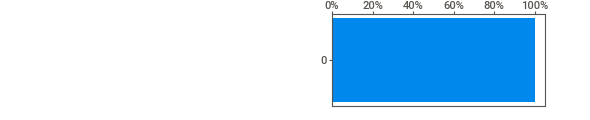
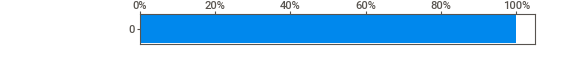
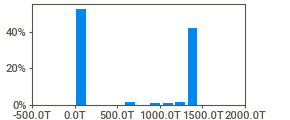
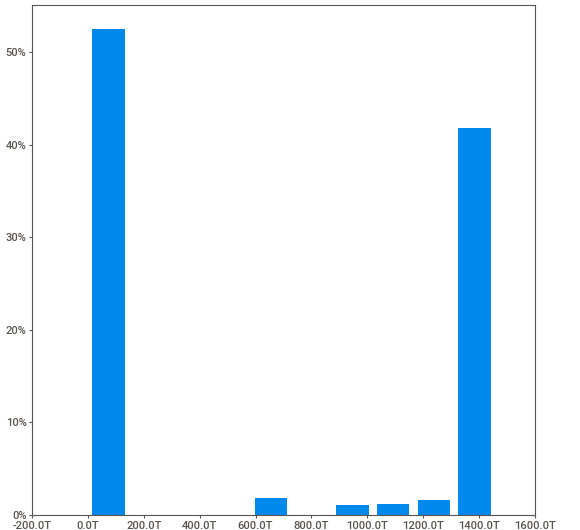
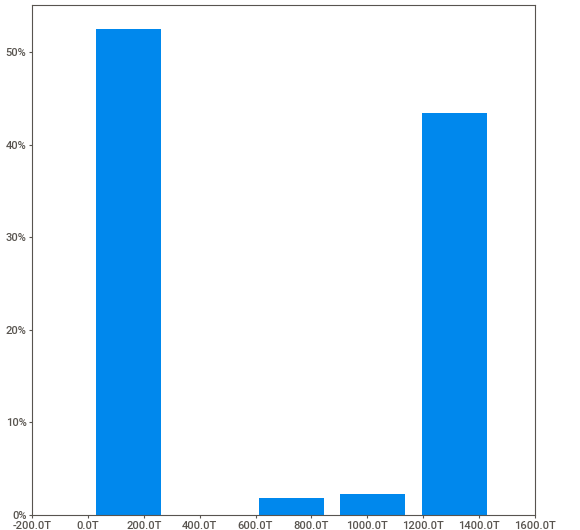
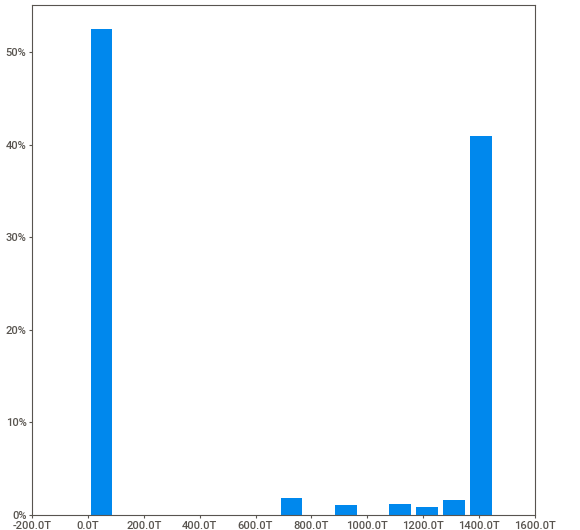
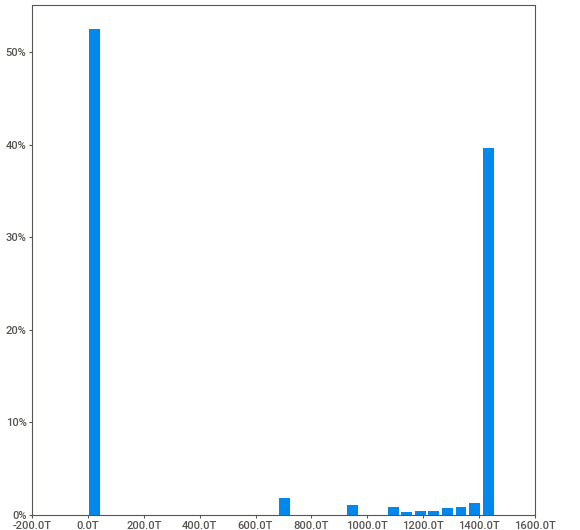
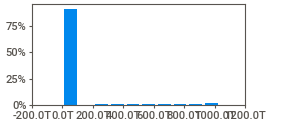
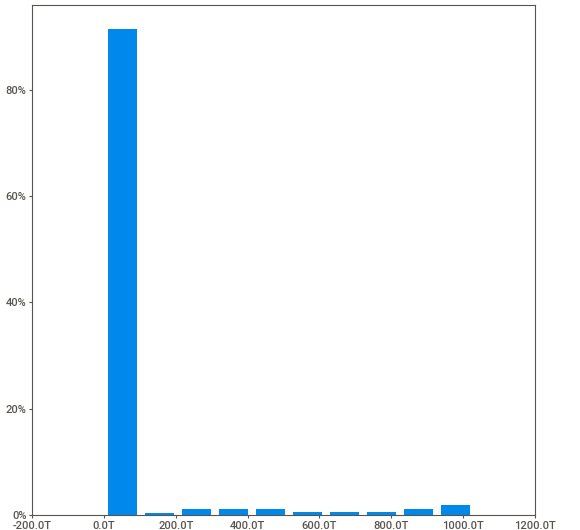
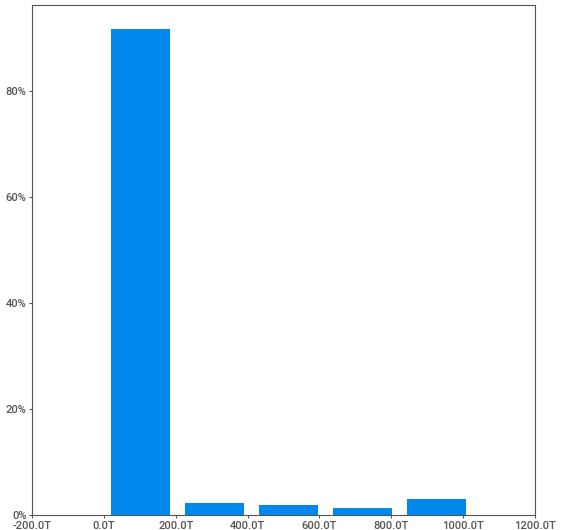
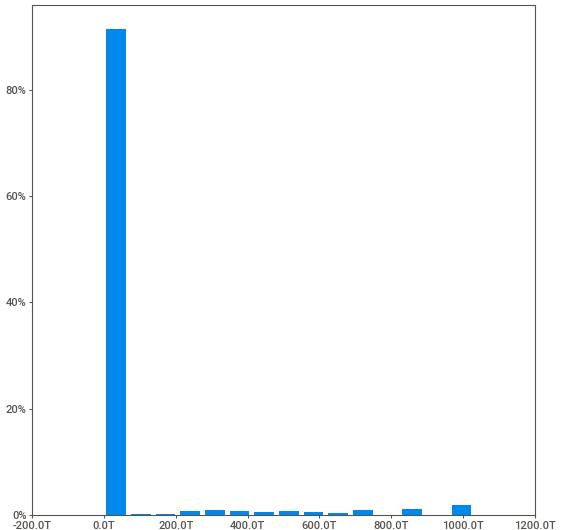
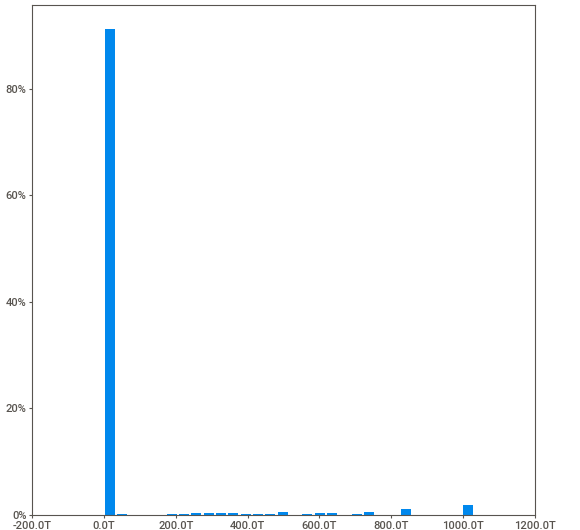
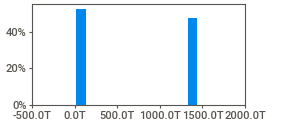
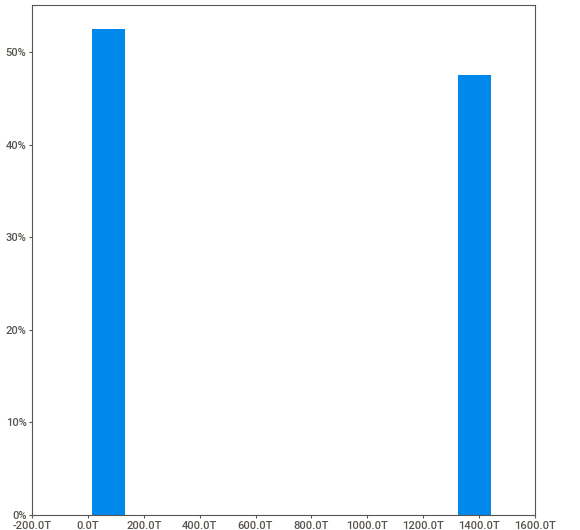
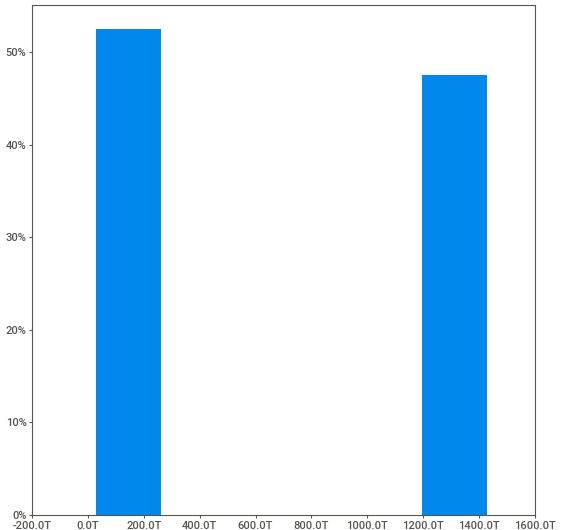
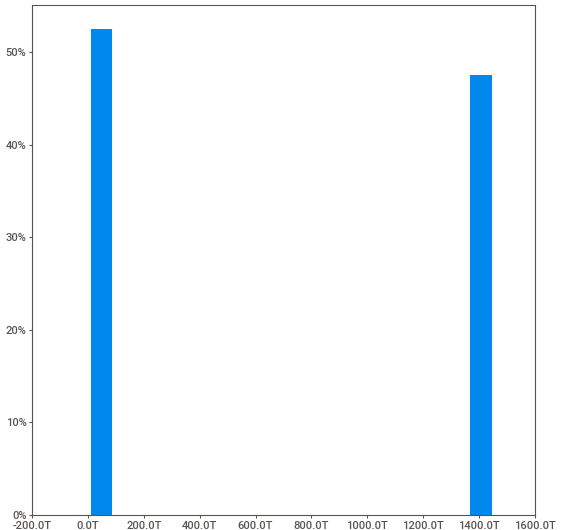
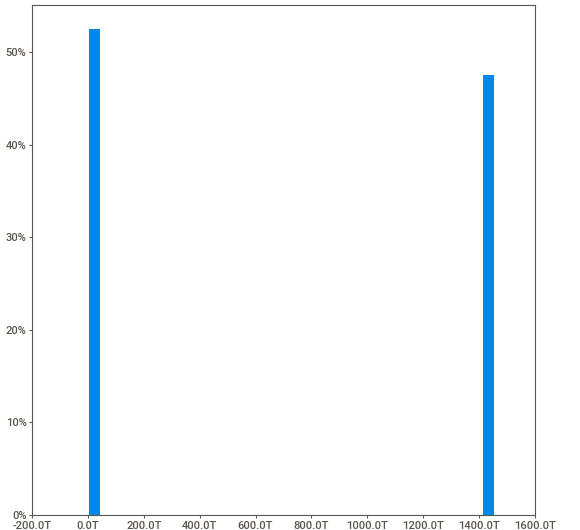
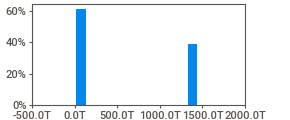
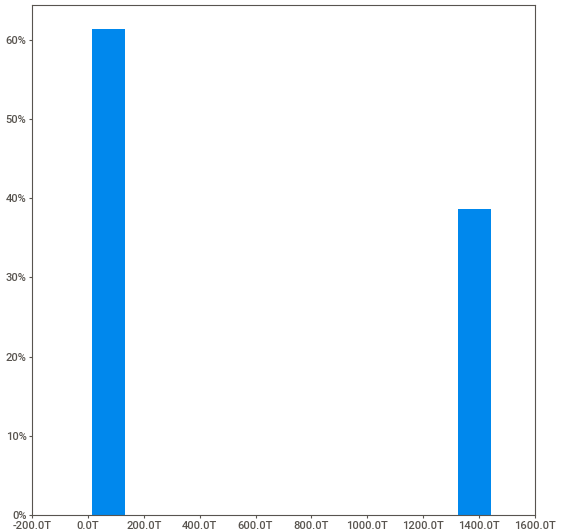
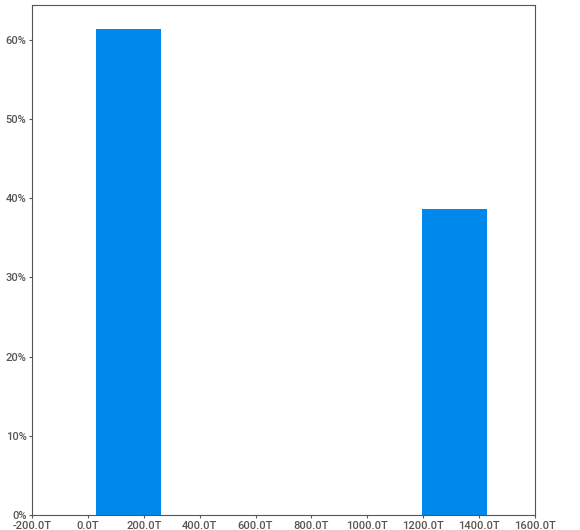
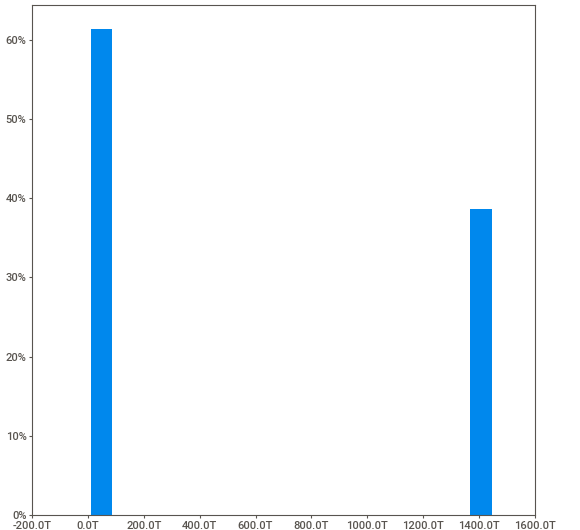
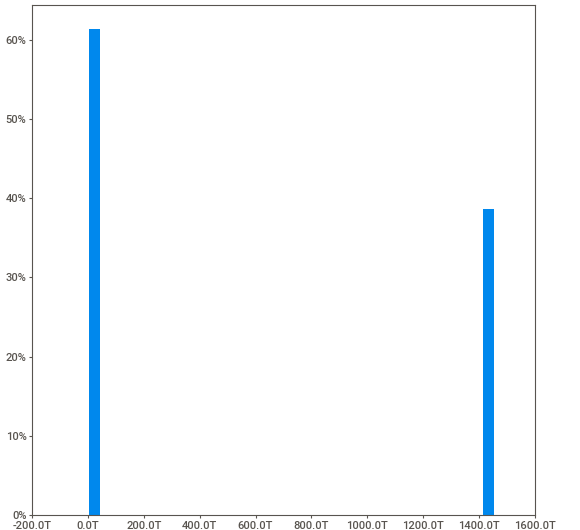
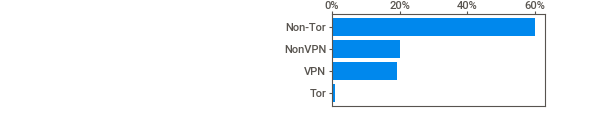
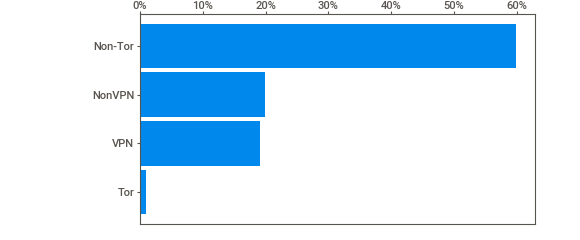
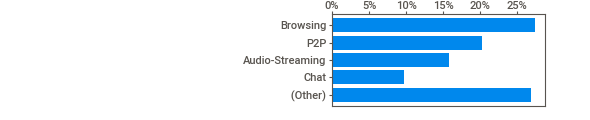
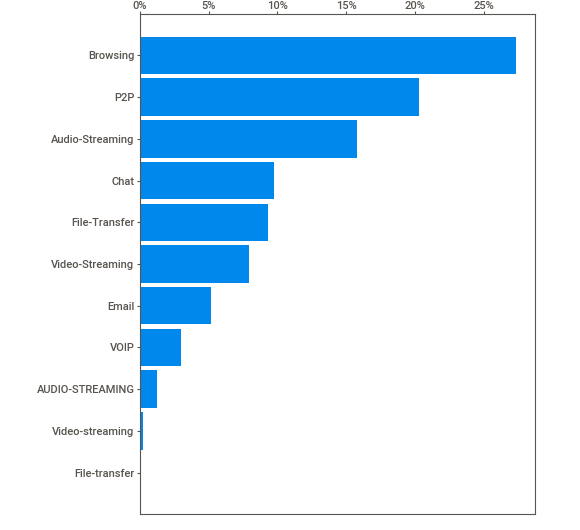
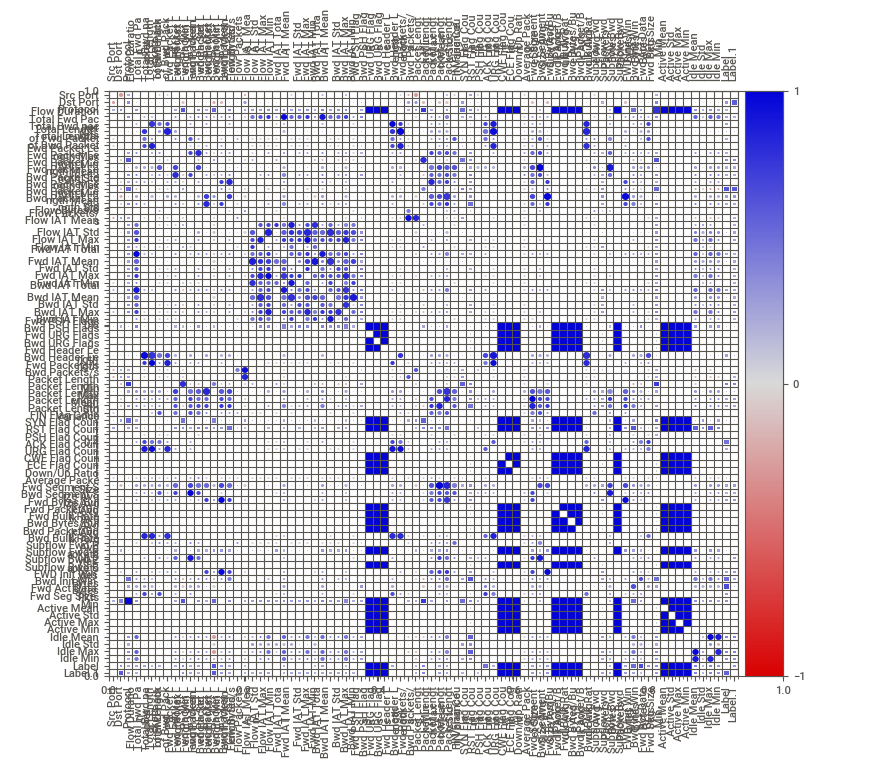
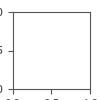

In [ ]:
import sweetviz as sv
my_report = sv.analyze(data)
my_report.show_notebook()

In [ ]:
data.nunique()

,0
Flow ID,79113
Src IP,4018
Src Port,34524
Dst IP,7553
Dst Port,13312
...,...
Idle Std,51094
Idle Max,58226
Idle Min,58169
traffic,4


In [ ]:
data['traffic'].unique()

array(['Non-Tor', 'NonVPN', 'Tor', 'VPN'], dtype=object)

In [ ]:
data['traffic'].value_counts()

,count
traffic,
Non-Tor,71603
NonVPN,23861
VPN,22919
Tor,1179


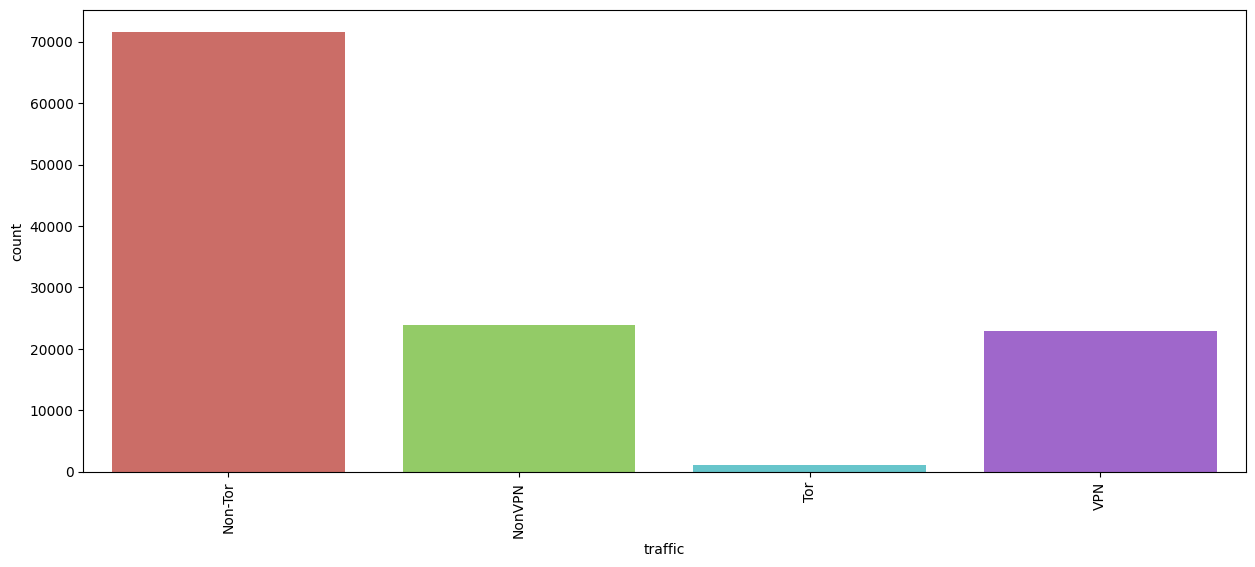

In [ ]:
plt.figure(figsize=(15,6))
sns.countplot(x='traffic', data=data, palette='hls')
plt.xticks(rotation=90)
plt.show()

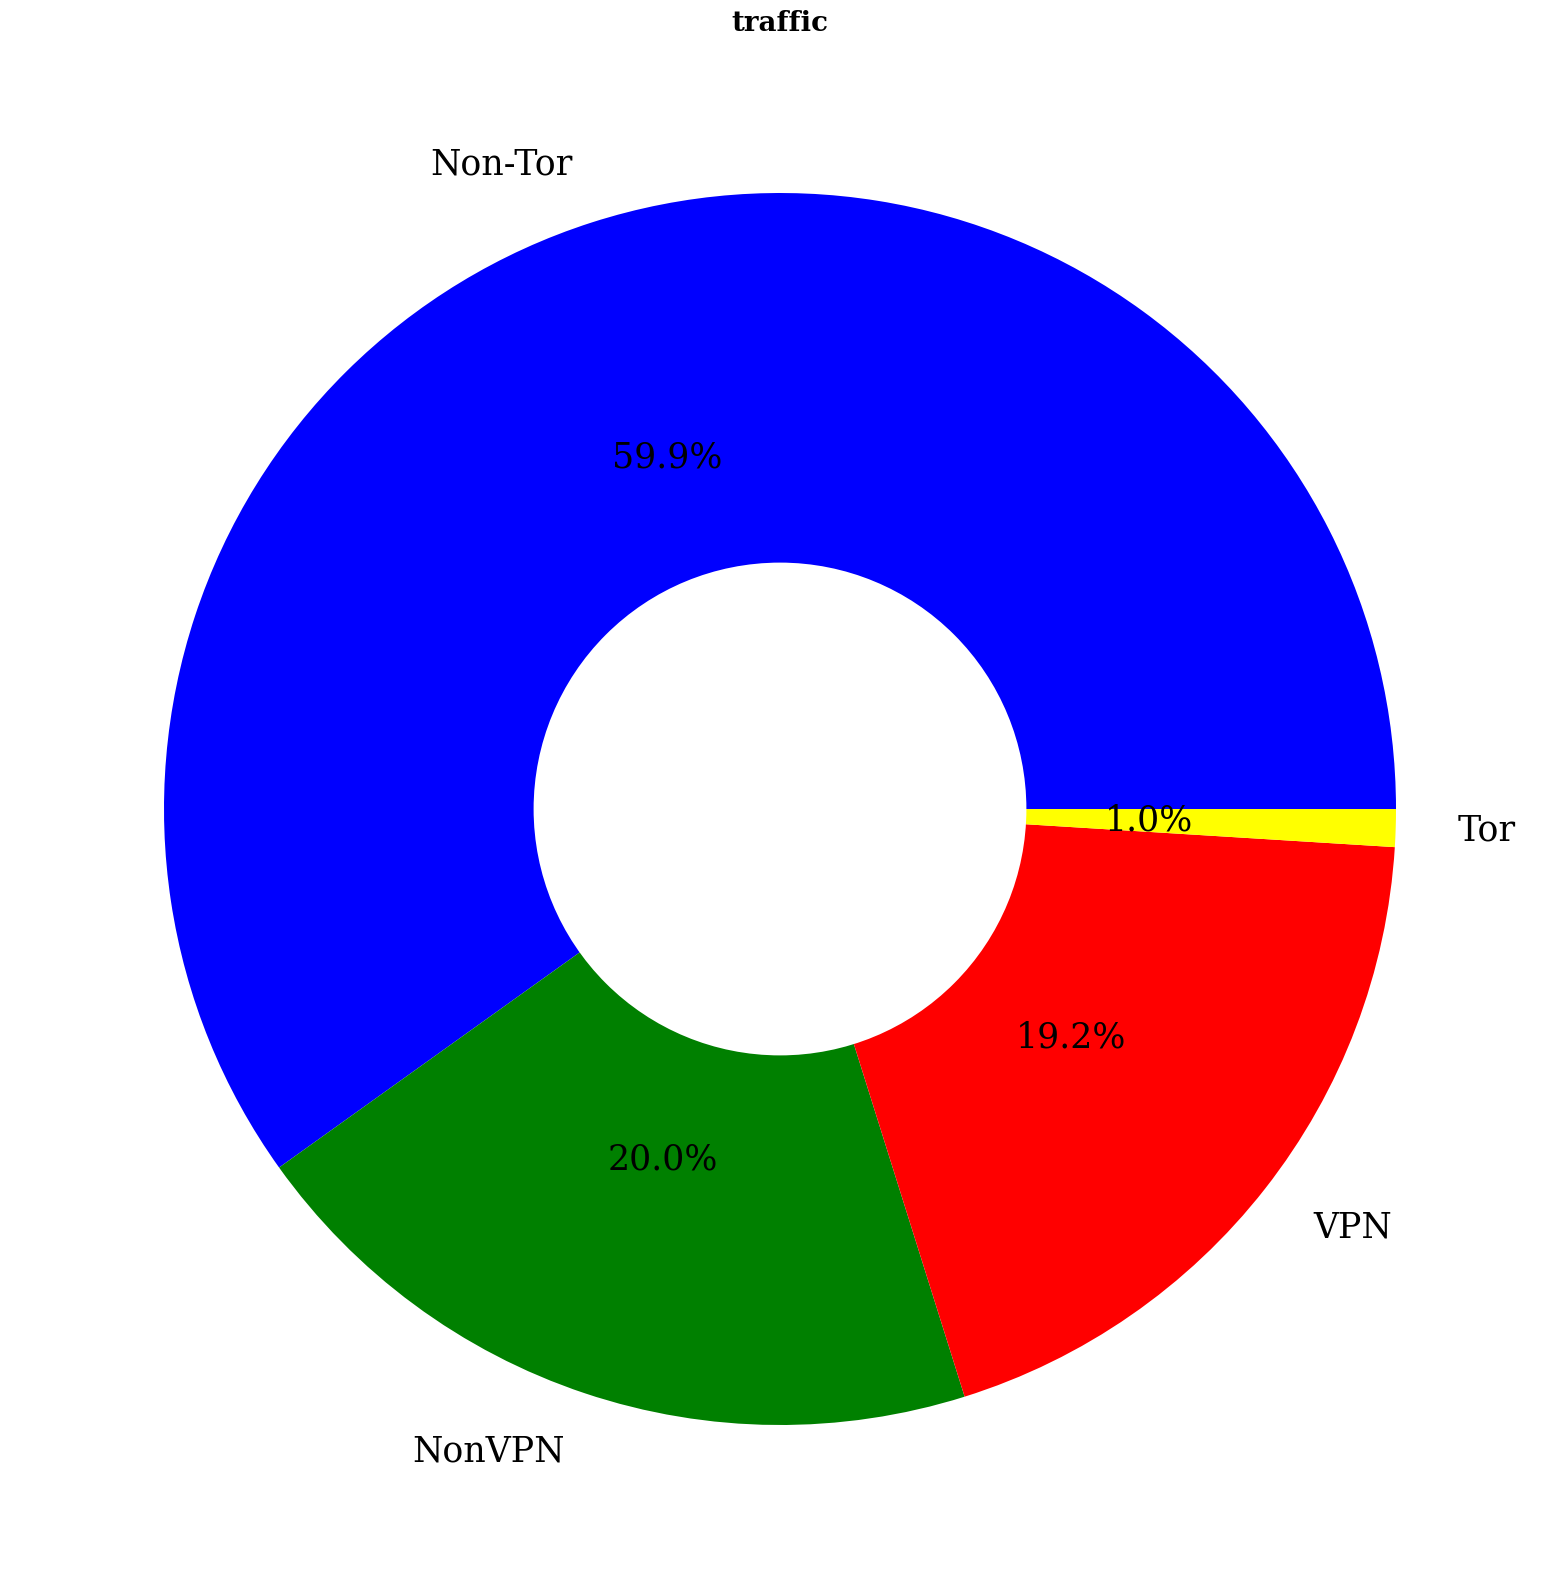

In [ ]:
label_data=data['traffic'].value_counts()
explode=(0.0,0.0,0.0,0.0)
plt.figure(figsize=(30,20))
patches, texts, pts= plt.pie(label_data,
                               labels=label_data.index,
                               colors=['blue','green','red','yellow'],
                               autopct='%1.1f%%',
                               textprops={'fontsize':25,
                                          'color':'black',
                                          'family':'serif'})
#plt.setp(pcts, color='black')
hfont={'fontname':'serif', 'weight':'bold'}
plt.title('traffic', size=20, **hfont)
centre_circle=plt.Circle((0,0),0.40, fc='white')
fig = plt.gcf()
fig.gca().add_artist(centre_circle)
plt.show()

In [ ]:
data['application'].unique()

array(['AUDIO-STREAMING', 'Chat', 'Audio-Streaming', 'Browsing', 'Email',
       'File-Transfer', 'File-transfer', 'P2P', 'Video-Streaming',
       'Video-streaming', 'VOIP'], dtype=object)

In [ ]:
## we need to do some labels correction
data['application'].loc[data['application'] == 'AUDIO-STREAMING'] = 'Audio-Streaming'
data['application'].loc[data['application'] == 'File-transfer'] = 'File-Transfer'
data['application'].loc[data['application'] == 'Video-streaming'] = 'Video-Streaming'


In [ ]:
data['application'].unique()

array(['Audio-Streaming', 'Chat', 'Browsing', 'Email', 'File-Transfer',
       'P2P', 'Video-Streaming', 'VOIP'], dtype=object)

In [ ]:
data['application'].value_counts()

,count
application,
Browsing,32714
P2P,24260
Audio-Streaming,20335
Chat,11623
File-Transfer,11173
Video-Streaming,9748
Email,6143
VOIP,3566


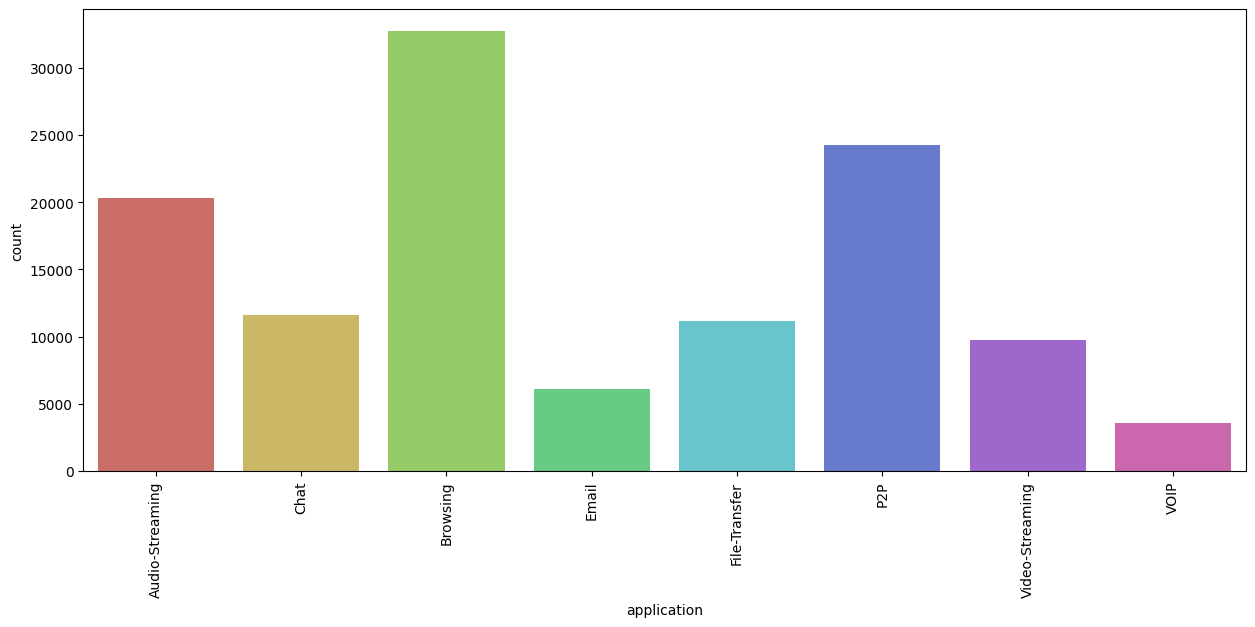

In [ ]:
plt.figure(figsize=(15,6))
sns.countplot(x='application', data=data, palette='hls')
plt.xticks(rotation=90)
plt.show()

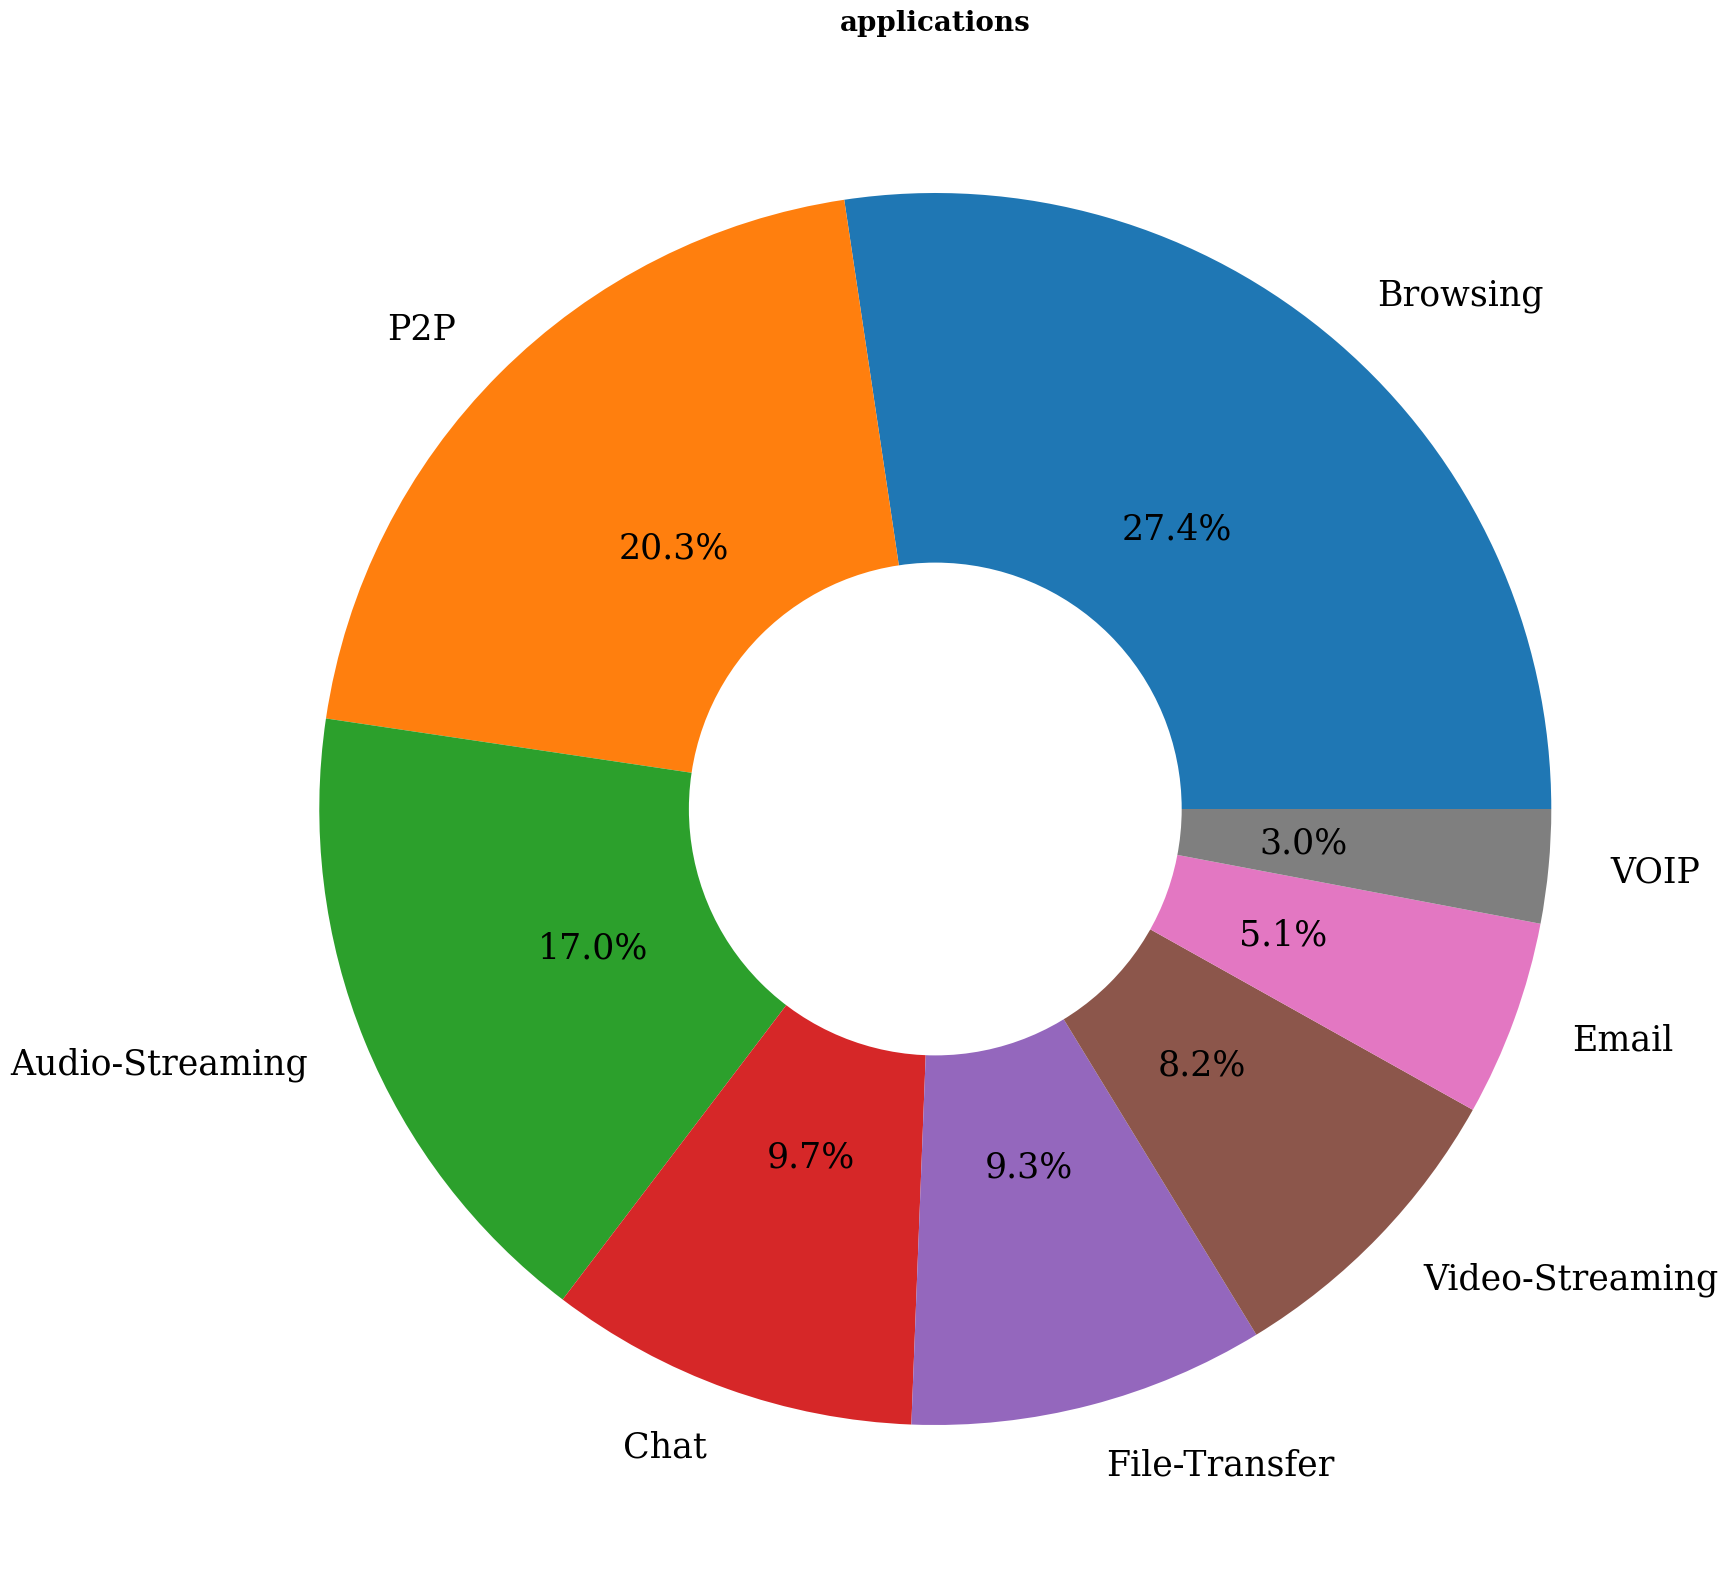

In [ ]:
label_data=data['application'].value_counts()
explode=(0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0)
plt.figure(figsize=(30,20))
patches, texts, pts= plt.pie(label_data,
                               labels=label_data.index,
                               autopct='%1.1f%%',
                               textprops={'fontsize':25,
                                          'color':'black',
                                          'family':'serif'})
#plt.setp(pcts, color='black')
hfont={'fontname':'serif', 'weight':'bold'}
plt.title('applications', size=20, **hfont)
centre_circle=plt.Circle((0,0),0.40, fc='white')
fig = plt.gcf()
fig.gca().add_artist(centre_circle)
plt.show()

### inference
There is no balancing in the data.Thus the data should be balanced.But first it is needed to preform feature selection then Data balancing

## Recap
* There is a huge imbalance concenring the two labels
* The data should be balanced

## Label encoding

In [ ]:
application_types = data['application'].unique().tolist()
traffic_types = data['traffic'].unique().tolist()

In [ ]:
for i in range(len(application_types)):
    data['application'].loc[data['application'] == application_types[i]] = i


In [ ]:
for i in range(len(traffic_types)):
    data['traffic'].loc[data['traffic'] == traffic_types[i]] = i

In [ ]:
data['traffic'].unique()

array([0, 1, 2, 3], dtype=object)

In [ ]:
data['application'].unique()

array([0, 1, 2, 3, 4, 5, 6, 7], dtype=object)

In [ ]:
traffic_labels = { 'Traffic_type': traffic_types,
                  'Labels' : data['traffic'].unique().tolist()
                 }
traffic_labels = pd.DataFrame(traffic_labels)

In [ ]:
traffic_labels

,Traffic_type,Labels
0,Non-Tor,0
1,NonVPN,1
2,Tor,2
3,VPN,3


In [ ]:
application_labels = { 'Application_type': application_types,
                  'Labels' : data['application'].unique().tolist()
                 }
application_labels = pd.DataFrame(application_labels)

In [ ]:
application_labels

,Application_type,Labels
0,Audio-Streaming,0
1,Chat,1
2,Browsing,2
3,Email,3
4,File-Transfer,4
5,P2P,5
6,Video-Streaming,6
7,VOIP,7


In [ ]:
# IP adresses numeric encoding
def IPtoNumeric(ip):
    packed_ip = socket.inet_aton(ip)
    ip_int = struct.unpack('!L', packed_ip)[0]
    return ip_int

In [ ]:
srcIP = data["Src IP"]
numericSrcIP = srcIP.map(IPtoNumeric)
dstIP = data['Dst IP']
numericDstIP = dstIP.map(IPtoNumeric)

In [ ]:
data["Src IP"] = numericSrcIP
data["Dst IP"] = numericDstIP

In [ ]:
data.head()

,Flow ID,Src IP,Src Port,Dst IP,Dst Port,Protocol,Timestamp,Flow Duration,Total Fwd Packet,Total Bwd packets,...,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min,traffic,application
0,10.152.152.11-216.58.220.99-57158-443-6,177772555,57158,3627736163,443,6,24/07/2015 04:09:48 PM,229,1,1,...,0,0,0,0,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0,0
1,10.152.152.11-216.58.220.99-57159-443-6,177772555,57159,3627736163,443,6,24/07/2015 04:09:48 PM,407,1,1,...,0,0,0,0,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0,0
2,10.152.152.11-216.58.220.99-57160-443-6,177772555,57160,3627736163,443,6,24/07/2015 04:09:48 PM,431,1,1,...,0,0,0,0,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0,0
3,10.152.152.11-74.125.136.120-49134-443-6,177772555,49134,1249740920,443,6,24/07/2015 04:09:48 PM,359,1,1,...,0,0,0,0,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0,0
4,10.152.152.11-173.194.65.127-34697-19305-6,177772555,34697,2915189119,19305,6,24/07/2015 04:09:45 PM,10778451,591,400,...,0,0,0,0,1.437765e+15,3.117718e+06,1.437765e+15,1.437765e+15,0,0


In [ ]:
data.to_csv('cleaned_data.csv',index = False)

## Spliting the data

In [ ]:
input_data = data.drop(['traffic','application','Flow ID', 'Timestamp'], axis=1)
application_label =  pd.to_numeric(data['application'], errors='coerce')

# Split data for the application label
X_train, X_test, y_train, y_test = train_test_split(
  input_data,application_label , random_state=104,test_size=0.2, shuffle=True)


In [ ]:
print('Xtrain_application shape : {} '.format(X_train.shape))
print('Xtest_application shape : {} '.format(X_test.shape))
print('ytrain_application shape : {} '.format(y_train.shape))
print('ytest_application shape : {} '.format(y_test.shape))

Xtrain_application shape : (95649, 81) 
Xtest_application shape : (23913, 81) 
ytrain_application shape : (95649,) 
ytest_application shape : (23913,) 


In [ ]:
scaler = StandardScaler()

Xtrain_application_scaled = scaler.fit_transform(X_train)
Xtest_application_scaled = scaler.transform(X_test)

In [ ]:
# Save the training & testing data in CSV

train_data = pd.concat([pd.DataFrame(X_train), pd.DataFrame(y_train)], axis=1)
test_data = pd.concat([pd.DataFrame(X_test), pd.DataFrame(y_test)], axis=1)

train_data.to_csv('train_data.csv', index=False)
test_data.to_csv('test_data.csv', index=False)

# __Data Blancing Using SMOTE & ADASYN__

## __The summury of the work:__
- Performing Data Blancing Using SMOTE.
- Performing Data Blancing Using ADASYN.
- Save each generated dataset in a csv file for machine learning models.
- Tested the models on the generated datasets(Random Forest, XGBoosting, KNN).
- Visualizing the results for each balancing technique and each model.



## Load the cleaned dataset_

In [ ]:
darknet_data = pd.read_csv('./train_data.csv')
test_dataset = pd.read_csv('./test_data.csv')
darknet_data.head()

,Src IP,Src Port,Dst IP,Dst Port,Protocol,Flow Duration,Total Fwd Packet,Total Bwd packets,Total Length of Fwd Packet,Total Length of Bwd Packet,...,Fwd Seg Size Min,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min,application
0,177772555,55271,911788725,80,6,3305684,2,0,0,0,...,20,0,0,0,0,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,4
1,177772555,60762,177772554,53,17,296336,2,2,84,100,...,8,0,0,0,0,1.456254e+15,2.094959e+05,1.456254e+15,1.456254e+15,2
2,177772555,46659,2915203898,443,6,92059237,19,19,1324,4657,...,20,0,0,0,0,1.436451e+15,1.819340e+07,1.436452e+15,1.436451e+15,1
3,2211115158,55441,1796661528,443,6,4,2,0,31,0,...,32,0,0,0,0,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,6
4,177772555,35385,2211115011,53,17,204997,2,2,72,88,...,8,0,0,0,0,1.436805e+15,7.494625e+03,1.436805e+15,1.436805e+15,3


### as we can notice here the data is imbalanced, we'll use those techniques to balance the training dataset:
- SMOTE
- ADASYN

## we perfrom these three techniques by using 30k per class strategy

## __SMOTE Technique:__

## Diffrenet used strategies:

In [ ]:
sampling_strategy_30k = {0: 30000,
                         1: 30000,
                         2: 30000,
                         3: 30000,
                         4: 30000,
                         5: 30000,
                         6: 30000,
                         7: 30000, }

In [ ]:
def perform_smote(X, y, sampling_strategy=None, random_state=42):
    """
    Generate synthetic data to balance a binary or multi-class classification problem using SMOTE.
    Returns:
    numpy.ndarray: Array of shape (num_samples_new, num_features) containing the generated data.
    numpy.ndarray: Array of shape (num_samples_new,) containing the corresponding labels.
    """

    # Apply SMOTE
    smote = SMOTE(sampling_strategy=sampling_strategy,
                  random_state=random_state)
    X_resampled, y_resampled = smote.fit_resample(X, y)

    return X_resampled, y_resampled


X = darknet_data.drop(['application'], axis=1)
y = darknet_data['application']


X_resampled, y_resampled = perform_smote(
    X, y, sampling_strategy=sampling_strategy_30k, random_state=42)

darknet_data_smote_30k_per_class = pd.concat(
    [X_resampled, y_resampled], axis=1)

### Let's begin with training the models on the generated dataset to test the performance of the models on the generated dataset by using the classification report and the confusion matrix by using the following models:
### - _Random Forest_
### - _XGBoosting_
### - _KNN_
### - _Linear Discriminant Analysis_
### - _LightGBM_

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import train_test_split
import lightgbm
from sklearn.metrics import classification_report
from sklearn.metrics import roc_curve, auc
from imblearn.over_sampling import ADASYN
from imblearn.combine import SMOTEENN
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

In [ ]:
DATA_GENERATED = [darknet_data_smote_30k_per_class]

classifiers = {
    'Random Forest': RandomForestClassifier(),
    'XGBoost': XGBClassifier(),
    'LDA': LinearDiscriminantAnalysis(),
    'KNN': KNeighborsClassifier(),
    'LightGBM': lightgbm.LGBMClassifier()
}

cols_to_drop = []


In [ ]:
X_test__ = test_dataset.drop(['application'], axis=1)
y_test__ = test_dataset['application']

In [ ]:
def train_test_model(dataset, model, target_variable, cols_to_delete_):
    """
    Parameters:
    dataset (pandas.DataFrame): The dataset to be used for training and testing the model.
    model (sklearn estimator): The machine learning model to be trained and evaluated.
    target_variable (str): The name of the target variable column in the dataset.

    Returns:
    dict: A dictionary containing the evaluation metrics (accuracy, precision, recall, f1-score) on the test data.
    """

    # Split dataset into train and test sets
    X = dataset.drop(columns=[target_variable])
    y = dataset[target_variable]
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42)

    # Train model on training data
    model.fit(X_train, y_train)

    # Predict on test data
    y_pred = model.predict(X_test__)

    # Calculate evaluation metrics on test data
    classification_report__ = classification_report(y_test__, y_pred)
    confusion_matrix__ = confusion_matrix(y_test__, y_pred)

    print(classification_report__)
    sns.heatmap(confusion_matrix__, annot=True, fmt='d')
    plt.show()

Training and evaluating Random Forest model...
              precision    recall  f1-score   support

           0       0.92      0.90      0.91      4091
           1       0.87      0.76      0.81      2385
           2       0.95      0.96      0.95      6556
           3       0.70      0.80      0.75      1164
           4       0.90      0.87      0.89      2247
           5       0.99      0.99      0.99      4826
           6       0.77      0.81      0.79      1926
           7       0.70      0.82      0.75       718

    accuracy                           0.90     23913
   macro avg       0.85      0.86      0.86     23913
weighted avg       0.91      0.90      0.90     23913



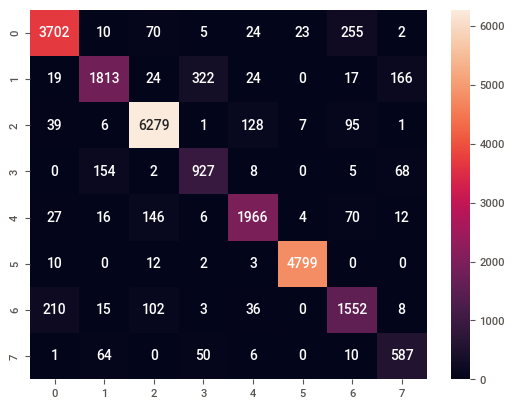


Training and evaluating XGBoost model...
              precision    recall  f1-score   support

           0       0.96      0.88      0.92      4091
           1       0.93      0.73      0.82      2385
           2       0.96      0.97      0.96      6556
           3       0.72      0.86      0.78      1164
           4       0.93      0.89      0.91      2247
           5       1.00      0.99      1.00      4826
           6       0.75      0.90      0.82      1926
           7       0.68      0.93      0.79       718

    accuracy                           0.92     23913
   macro avg       0.87      0.90      0.87     23913
weighted avg       0.92      0.92      0.92     23913



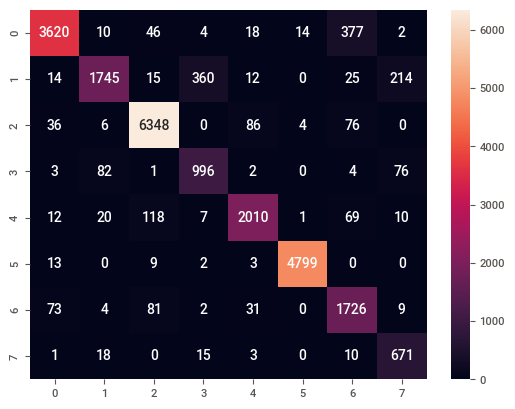


Training and evaluating LDA model...
              precision    recall  f1-score   support

           0       0.64      0.58      0.61      4091
           1       0.39      0.13      0.19      2385
           2       0.69      0.77      0.73      6556
           3       0.20      0.21      0.20      1164
           4       0.44      0.33      0.37      2247
           5       0.77      0.78      0.78      4826
           6       0.34      0.37      0.35      1926
           7       0.25      0.76      0.37       718

    accuracy                           0.58     23913
   macro avg       0.47      0.49      0.45     23913
weighted avg       0.58      0.58      0.57     23913



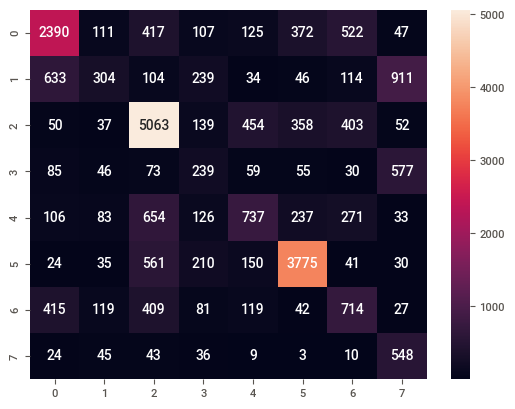


Training and evaluating KNN model...
              precision    recall  f1-score   support

           0       0.91      0.87      0.89      4091
           1       0.85      0.74      0.79      2385
           2       0.94      0.91      0.92      6556
           3       0.66      0.79      0.72      1164
           4       0.81      0.84      0.82      2247
           5       0.97      0.97      0.97      4826
           6       0.72      0.80      0.76      1926
           7       0.64      0.79      0.71       718

    accuracy                           0.87     23913
   macro avg       0.81      0.84      0.82     23913
weighted avg       0.88      0.87      0.87     23913



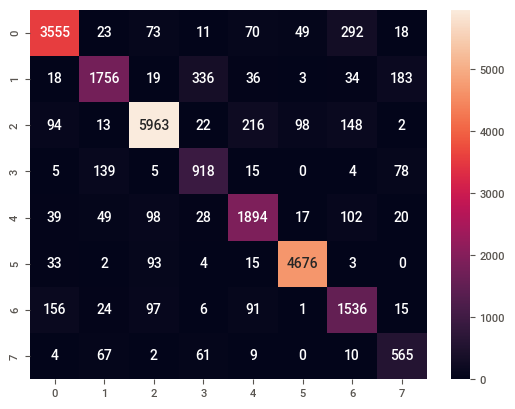


Training and evaluating LightGBM model...
[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.213545 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 14855
[LightGBM] [Info] Number of data points in the train set: 192000, number of used features: 66
[LightGBM] [Info] Start training from score -2.077319
[LightGBM] [Info] Start training from score -2.081151
[LightGBM] [Info] Start training from score -2.079650
[LightGBM] [Info] Start training from score -2.073418
[LightGBM] [Info] Start training from score -2.078942
[LightGBM] [Info] Start training from score -2.078276
[LightGBM] [Info] Start training from score -2.084580
[LightGBM] [Info] Start training from score -2.082237
              precision    recall  f1-score   support

           0       0.96      0.88      0.92      4091
           1       0.94      0.72      0.82  

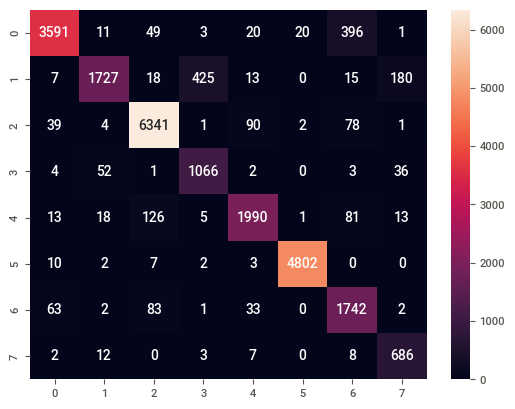

In [ ]:
for model_name, model in classifiers.items():
    print(f'Training and evaluating {model_name} model...')
    train_test_model(darknet_data_smote_30k_per_class,
                     model, 'application', cols_to_drop)
    print('')

## __ADASYN Technique__

In [ ]:
def perform_adasyn(X, y, sampling_strategy=None, random_state=42):
    """
    Returns:
    numpy.ndarray: Array of shape (num_samples_new, num_features) containing the generated data.
    numpy.ndarray: Array of shape (num_samples_new,) containing the corresponding labels.
    """

    # Apply ADASYN
    adasyn = ADASYN(sampling_strategy=sampling_strategy,
                    random_state=random_state)
    X_resampled, y_resampled = adasyn.fit_resample(X, y)

    return X_resampled, y_resampled


X = darknet_data.drop(['application'], axis=1)
y = darknet_data['application']



X_resampled, y_resampled = perform_adasyn(
    X, y, sampling_strategy=sampling_strategy_30k, random_state=42)

darknet_data_adasyn_30k_per_class = pd.concat(
    [X_resampled, y_resampled], axis=1)

Training and evaluating Random Forest model...
              precision    recall  f1-score   support

           0       0.91      0.91      0.91      4091
           1       0.86      0.75      0.81      2385
           2       0.95      0.95      0.95      6556
           3       0.70      0.79      0.74      1164
           4       0.88      0.87      0.87      2247
           5       0.99      0.99      0.99      4826
           6       0.78      0.79      0.78      1926
           7       0.67      0.80      0.73       718

    accuracy                           0.90     23913
   macro avg       0.84      0.86      0.85     23913
weighted avg       0.90      0.90      0.90     23913



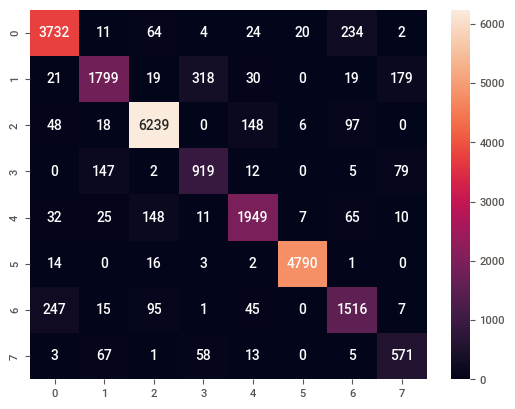


Training and evaluating XGBoost model...
              precision    recall  f1-score   support

           0       0.93      0.90      0.92      4091
           1       0.94      0.70      0.80      2385
           2       0.97      0.95      0.96      6556
           3       0.70      0.86      0.77      1164
           4       0.89      0.90      0.89      2247
           5       1.00      0.99      0.99      4826
           6       0.75      0.86      0.80      1926
           7       0.64      0.94      0.76       718

    accuracy                           0.91     23913
   macro avg       0.85      0.89      0.86     23913
weighted avg       0.92      0.91      0.91     23913



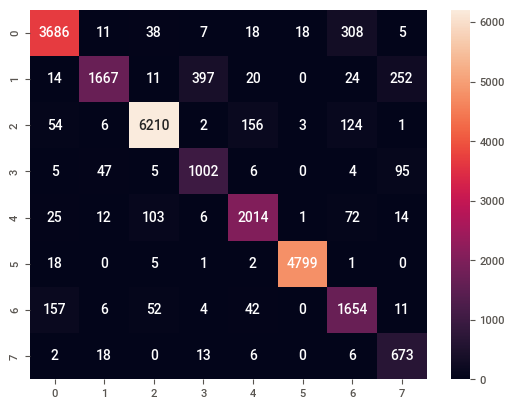


Training and evaluating LDA model...
              precision    recall  f1-score   support

           0       0.61      0.54      0.57      4091
           1       0.32      0.10      0.15      2385
           2       0.65      0.64      0.64      6556
           3       0.29      0.52      0.37      1164
           4       0.26      0.39      0.31      2247
           5       0.76      0.80      0.78      4826
           6       0.38      0.46      0.42      1926
           7       0.17      0.07      0.10       718

    accuracy                           0.54     23913
   macro avg       0.43      0.44      0.42     23913
weighted avg       0.54      0.54      0.53     23913



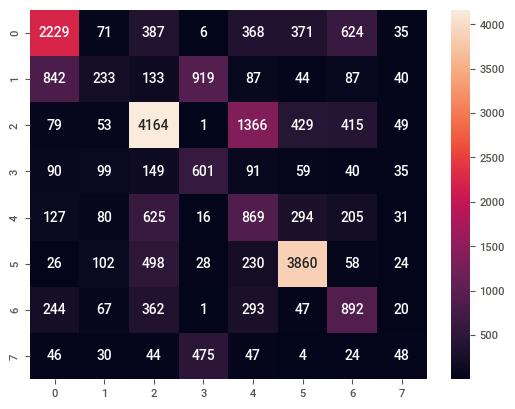


Training and evaluating KNN model...
              precision    recall  f1-score   support

           0       0.88      0.88      0.88      4091
           1       0.84      0.74      0.78      2385
           2       0.95      0.88      0.92      6556
           3       0.68      0.80      0.73      1164
           4       0.77      0.84      0.81      2247
           5       0.97      0.98      0.97      4826
           6       0.71      0.78      0.74      1926
           7       0.63      0.78      0.69       718

    accuracy                           0.87     23913
   macro avg       0.80      0.83      0.82     23913
weighted avg       0.87      0.87      0.87     23913



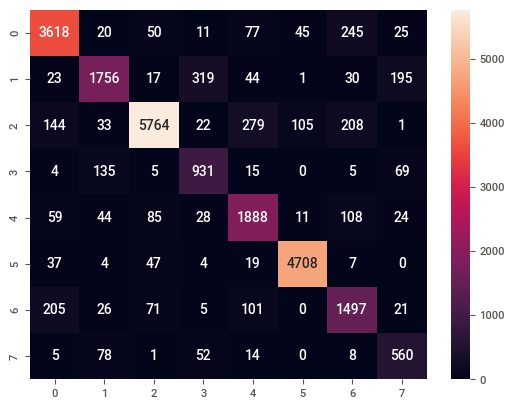


Training and evaluating LightGBM model...
[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.069971 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 14823
[LightGBM] [Info] Number of data points in the train set: 190952, number of used features: 66
[LightGBM] [Info] Start training from score -2.068691
[LightGBM] [Info] Start training from score -2.069893
[LightGBM] [Info] Start training from score -2.086041
[LightGBM] [Info] Start training from score -2.075720
[LightGBM] [Info] Start training from score -2.083766
[LightGBM] [Info] Start training from score -2.079777
[LightGBM] [Info] Start training from score -2.102496
[LightGBM] [Info] Start training from score -2.069603
              precision    recall  f1-score   support

           0       0.94      0.89  

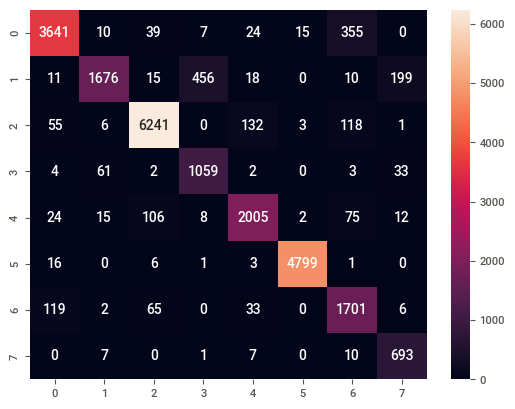

In [ ]:
for model_name, model in classifiers.items():
    print(f'Training and evaluating {model_name} model...')
    train_test_model(darknet_data_adasyn_30k_per_class,
                     model, 'application', cols_to_drop)
    print('')


In [ ]:
darknet_data_smote_30k_per_class.to_csv('balancedAppDarknet.csv', index=False)

## __Conclusion:__

- Based on the experiments we conducted on the dataset, we have found that both the SMOTE and ADASYN techniques are effective in generating balanced datasets for machine learning models. However, we have decided to use the SMOTE technique over ADASYN for this particular dataset because it performed better on other models such as XGBoost when we used a 30k strategy.


- _XGBClassifier_: F1-score: 0.89, overall accuracy: 0.91, precision: 0.87, recall: 0.89

- The Random Forest was the best model for this dataset , for the other algorithms(Xgboosting, KNN, LDA, LightGBM) we are going to try them later.

- We plan to explore the potential of GANs and VAEs in our project, but we have decided to prioritize other techniques at the moment. Therefore, we will try GANs and VAEs at a later stage.

## Feature Selection:

### Feature selection is an important step in data preprocessing that involves selecting a subset of relevant features or variables from a larger set of features.we will eliminate features that can be noisy  with misleading data, this process is crucial in reducing the complexity of a machine learning model and improving its performance.

### importing training and test datasets:

In [ ]:
dfTrain = pd.read_csv("./balancedAppDarknet.csv")
dfValidate = pd.read_csv("./test_data.csv")

In [ ]:
print(dfTrain.shape,dfValidate.shape)

(240000, 82) (23913, 82)


In [ ]:
dfTrain.columns.to_list()

['Src IP',
 'Src Port',
 'Dst IP',
 'Dst Port',
 'Protocol',
 'Flow Duration',
 'Total Fwd Packet',
 'Total Bwd packets',
 'Total Length of Fwd Packet',
 'Total Length of Bwd Packet',
 'Fwd Packet Length Max',
 'Fwd Packet Length Min',
 'Fwd Packet Length Mean',
 'Fwd Packet Length Std',
 'Bwd Packet Length Max',
 'Bwd Packet Length Min',
 'Bwd Packet Length Mean',
 'Bwd Packet Length Std',
 'Flow Bytes/s',
 'Flow Packets/s',
 'Flow IAT Mean',
 'Flow IAT Std',
 'Flow IAT Max',
 'Flow IAT Min',
 'Fwd IAT Total',
 'Fwd IAT Mean',
 'Fwd IAT Std',
 'Fwd IAT Max',
 'Fwd IAT Min',
 'Bwd IAT Total',
 'Bwd IAT Mean',
 'Bwd IAT Std',
 'Bwd IAT Max',
 'Bwd IAT Min',
 'Fwd PSH Flags',
 'Bwd PSH Flags',
 'Fwd URG Flags',
 'Bwd URG Flags',
 'Fwd Header Length',
 'Bwd Header Length',
 'Fwd Packets/s',
 'Bwd Packets/s',
 'Packet Length Min',
 'Packet Length Max',
 'Packet Length Mean',
 'Packet Length Std',
 'Packet Length Variance',
 'FIN Flag Count',
 'SYN Flag Count',
 'RST Flag Count',
 'PSH Flag

In [ ]:
X_train = dfTrain.drop("application",axis=1)
y_train = dfTrain.loc[:,["application"]]
X_validate = dfValidate.drop("application",axis=1)
y_validate = dfValidate.loc[:,["application"]]

In [ ]:
rfc = RandomForestClassifier(n_estimators=100, random_state=42)
rfc.fit(X_train, y_train)

y_pred = rfc.predict(X_validate)
accuracy = accuracy_score(y_validate, y_pred)
print(f"Accuracy before applying feature selection: {accuracy}")
F1_Score = f1_score(y_validate,y_pred,average='weighted')
print(f"F1-score before applying feature selection: {F1_Score}")
Precision_Score = precision_score(y_validate,y_pred,average='weighted')
print(f"precision-score before applying feature selection: {Precision_Score}")
Recall_Score = recall_score(y_validate,y_pred,average='weighted')
print(f"recall-score before applying feature selection: {Recall_Score}")
Confusion_Matrix = confusion_matrix(y_validate,y_pred)
print(f"confusion-matrix before applying feature selection:\n {Confusion_Matrix}")

Accuracy before applying feature selection: 0.9066616484757245
F1-score before applying feature selection: 0.9069033319131317
precision-score before applying feature selection: 0.9085202144126376
recall-score before applying feature selection: 0.9066616484757245
confusion-matrix before applying feature selection:
 [[3718   10   64    3   26   25  243    2]
 [  21 1819   28  321   17    2   17  160]
 [  39    6 6306    0  119    6   78    2]
 [   0  153    2  928   10    0    4   67]
 [  22   17  144    6 1970    6   72   10]
 [   8    0   12    3    1 4802    0    0]
 [ 207   14  105    2   41    0 1549    8]
 [   2   65    0   48    6    0    8  589]]


# droping constant features :
### Dropping constant features from a dataset can lead to faster computation time, reduce overfitting, improve accuracy, and improve interpretability of the model.
### unvariant features  leads the model to "think" that there are no differences between classes when we are trying to make him distinguish between them :

In [ ]:
num_unique = dfTrain.nunique()

In [ ]:
columns_to_drop = num_unique[num_unique <= 1].index

dfTrain=dfTrain.drop(columns_to_drop, axis=1)
dfValidate=dfValidate.drop(columns_to_drop, axis=1)

In [ ]:
print(dfTrain.shape,dfValidate.shape)

(240000, 67) (23913, 67)


### Inspecting performance after dropping constant features :

In [ ]:
X_train = dfTrain.drop("application",axis=1)
X_validate = dfValidate.drop("application",axis=1)
rfc = RandomForestClassifier(n_estimators=100, random_state=42)
rfc.fit(X_train, y_train)

y_pred = rfc.predict(X_validate)
accuracy = accuracy_score(y_validate, y_pred)
print(f"Accuracy after droping constant columns: {accuracy}")
F1_Score = f1_score(y_validate,y_pred,average='weighted')
print(f"F1-score after droping constant columns: {F1_Score}")
Precision_Score = precision_score(y_validate,y_pred,average='weighted')
print(f"precision-score after droping constant columns: {Precision_Score}")
Recall_Score = recall_score(y_validate,y_pred,average='weighted')
print(f"recall-score after droping constant columns: {Recall_Score}")
Confusion_Matrix = confusion_matrix(y_validate,y_pred)
print(f"confusion-matrix after droping constant columns:\n {Confusion_Matrix}")

Accuracy after droping constant columns: 0.9072052858277924
F1-score after droping constant columns: 0.9074669271675793
precision-score after droping constant columns: 0.9091015438439605
recall-score after droping constant columns: 0.9072052858277924
confusion-matrix after droping constant columns:
 [[3722   12   63    5   24   25  238    2]
 [  19 1816   24  327   18    2   16  163]
 [  35    6 6312    0  123    8   70    2]
 [   0  153    2  931    9    0    5   64]
 [  27   20  141    7 1971    5   67    9]
 [   8    0   11    3    2 4802    0    0]
 [ 202   16  105    2   39    0 1555    7]
 [   1   66    0   53    4    0    9  585]]


### Dropping one of all mutually highly correlated features to avoid issues with multicollinearity :

In [ ]:
corr_matrix = dfTrain.corr().abs()

high_corr_mask = corr_matrix > 0.8

high_corr_features = []
for i in range(len(high_corr_mask.columns)):
    for j in range(i):
        if high_corr_mask.iloc[i, j]:
            colname1 = high_corr_mask.columns[i]
            colname2 = high_corr_mask.columns[j]
            high_corr_features.append((colname1, colname2))

print(high_corr_features)

[('Total Bwd packets', 'Total Fwd Packet'), ('Total Length of Bwd Packet', 'Total Bwd packets'), ('Flow IAT Max', 'Flow IAT Std'), ('Fwd IAT Total', 'Flow Duration'), ('Fwd IAT Mean', 'Flow IAT Mean'), ('Fwd IAT Max', 'Flow IAT Std'), ('Fwd IAT Max', 'Flow IAT Max'), ('Fwd IAT Min', 'Flow IAT Mean'), ('Fwd IAT Min', 'Fwd IAT Mean'), ('Bwd IAT Total', 'Flow Duration'), ('Bwd IAT Total', 'Fwd IAT Total'), ('Bwd IAT Max', 'Flow IAT Max'), ('Bwd IAT Min', 'Bwd IAT Mean'), ('Fwd Header Length', 'Total Fwd Packet'), ('Fwd Header Length', 'Total Bwd packets'), ('Bwd Header Length', 'Total Fwd Packet'), ('Bwd Header Length', 'Total Bwd packets'), ('Bwd Header Length', 'Total Length of Bwd Packet'), ('Bwd Header Length', 'Fwd Header Length'), ('Fwd Packets/s', 'Flow Packets/s'), ('Packet Length Min', 'Fwd Packet Length Min'), ('Packet Length Max', 'Bwd Packet Length Max'), ('Packet Length Std', 'Packet Length Mean'), ('ACK Flag Count', 'Total Fwd Packet'), ('ACK Flag Count', 'Total Bwd packets'

### To choose what column to drop , we will use feature importance provided by a random forest classifier , the one assigned to the lowest importance by the classifier will be dropped :

In [ ]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)

feature_importance = dict(zip(X_train.columns, rf.feature_importances_))

In [ ]:
for corr_feature in high_corr_features:
    feature1, feature2 = corr_feature
    if feature_importance[feature1] > feature_importance[feature2]:
        drop_feature = feature2
    else:
        drop_feature = feature1

    if drop_feature in dfTrain.columns.to_list():
        dfTrain.drop(columns=[drop_feature], inplace=True)
        dfValidate.drop(columns=[drop_feature], inplace=True)


In [ ]:
print(dfTrain.shape,dfValidate.shape)

(240000, 41) (23913, 41)


### Inspecting performance after dropping one of all mutually highly correlated columns :

In [ ]:
X_train = dfTrain.drop("application",axis=1)
X_validate = dfValidate.drop("application",axis=1)
rfc = RandomForestClassifier(n_estimators=100, random_state=42)
rfc.fit(X_train, y_train)

y_pred = rfc.predict(X_validate)
accuracy = accuracy_score(y_validate, y_pred)
print(f"Accuracy after Dropping one of all mutually highly correlated features: {accuracy}")
F1_Score = f1_score(y_validate,y_pred,average='weighted')
print(f"F1-score after Dropping one of all mutually highly correlated features: {F1_Score}")
Precision_Score = precision_score(y_validate,y_pred,average='weighted')
print(f"precision-score after Dropping one of all mutually highly correlated features: {Precision_Score}")
Recall_Score = recall_score(y_validate,y_pred,average='weighted')
print(f"recall-score after Dropping one of all mutually highly correlated features: {Recall_Score}")
Confusion_Matrix = confusion_matrix(y_validate,y_pred)
print(f"confusion-matrix after Dropping one of all mutually highly correlated features:\n {Confusion_Matrix}")

Accuracy after Dropping one of all mutually highly correlated features: 0.9065780119600217
F1-score after Dropping one of all mutually highly correlated features: 0.906958189453666
precision-score after Dropping one of all mutually highly correlated features: 0.9089330411777893
recall-score after Dropping one of all mutually highly correlated features: 0.9065780119600217
confusion-matrix after Dropping one of all mutually highly correlated features:
 [[3703    9   59    2   26   27  262    3]
 [  18 1824   20  306   21    1   23  172]
 [  34    9 6292    0  128    7   86    0]
 [   0  138    2  948    5    0    5   66]
 [  26   20  140    8 1967    4   72   10]
 [  10    0   16    2    3 4795    0    0]
 [ 217   12   97    2   44    0 1546    8]
 [   0   56    0   41    7    0   10  604]]


# recursif feature eliminator (RFE):
### RFE is considered a brute force technique ,  at every step , the RFE drops a feature and calculates the efficiency of a model passed to the "estimator" argument ,in our case the random forest classifier , if it increases , it will moves to the next iteration , otherwise , it will restore it and drops an other feature until there is only a defined number of features passed to the "n_features_to_select" argument, the number of features to drop at each step is passed to the "step" argument , in our case we define it as 1.

In [ ]:
from sklearn.feature_selection import RFE
from sklearn.ensemble import RandomForestClassifier

clf = RandomForestClassifier()

rfe = RFE(estimator=clf, n_features_to_select=25, step=1)

rfe.fit(X_train, y_train)

RFE_selected_features = X_train.columns[rfe.support_]

In [ ]:
RFE_selected_features= RFE_selected_features.to_list()
RFE_selected_features

['Src IP',
 'Src Port',
 'Dst IP',
 'Dst Port',
 'Flow Duration',
 'Total Length of Fwd Packet',
 'Fwd Packet Length Max',
 'Bwd Packet Length Min',
 'Bwd Packet Length Mean',
 'Flow Bytes/s',
 'Flow Packets/s',
 'Flow IAT Mean',
 'Flow IAT Max',
 'Flow IAT Min',
 'Bwd Header Length',
 'Bwd Packets/s',
 'Packet Length Min',
 'Packet Length Max',
 'Packet Length Variance',
 'Average Packet Size',
 'Fwd Segment Size Avg',
 'FWD Init Win Bytes',
 'Bwd Init Win Bytes',
 'Fwd Seg Size Min',
 'Idle Max']

In [ ]:
dfTrainRFE = dfTrain[RFE_selected_features]
dfRFE = dfValidate[RFE_selected_features]

print(dfTrainRFE.shape,dfRFE.shape)

(240000, 25) (23913, 25)


In [ ]:
def inspect_perf_gain(X_train,X_validate,target,technique):
    try:
        X_train = X_train.drop(columns=[target])
    except KeyError:
        pass
    try:
        X_validate = X_validate.drop(columns=[target])
    except KeyError:
        pass
    rfc = RandomForestClassifier(n_estimators=100, random_state=42)
    rfc.fit(X_train, y_train)

    y_pred = rfc.predict(X_validate)
    accuracy = accuracy_score(y_validate, y_pred)
    print(f"Accuracy with using {technique} technique: {accuracy}")
    F1_Score = f1_score(y_validate,y_pred,average='weighted')
    print(f"F1-score with using {technique} technique: {F1_Score}")
    Precision_Score = precision_score(y_validate,y_pred,average='weighted')
    print(f"precision-score with using {technique} technique: {Precision_Score}")
    Recall_Score = recall_score(y_validate,y_pred,average='weighted')
    print(f"recall-score with using {technique} technique: {Recall_Score}")
    Confusion_Matrix = confusion_matrix(y_validate,y_pred)
    print(f"confusion-matrix with using {technique} technique:\n {Confusion_Matrix}")

### Inspecting performance with features selected by the RFE :

In [ ]:
inspect_perf_gain(dfTrainRFE,dfRFE,"application","RFE")

Accuracy with using RFE technique: 0.9100907456195375
F1-score with using RFE technique: 0.9104850803391702
precision-score with using RFE technique: 0.9124105074851548
recall-score with using RFE technique: 0.9100907456195375
confusion-matrix with using RFE technique:
 [[3718   10   57    2   19   25  258    2]
 [  16 1839   18  295   18    1   21  177]
 [  32    8 6308    0  116    7   84    1]
 [   0  127    1  964    4    0    5   63]
 [  24   19  132    7 1985    4   68    8]
 [  10    0   16    2    3 4794    1    0]
 [ 211   13   99    2   37    0 1556    8]
 [   0   63    0   37    6    0   13  599]]


# Random forest Feature importance :
### here we will only keep features assigned by a high feature importance by a random forest classifier

In [ ]:
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)

feature_importance = dict(zip(X_train.columns, rf.feature_importances_))

In [ ]:
RFC_selected_features = [i[0] for i in sorted(feature_importance.items(), key=lambda x:x[1])[::-1]][:25]

In [ ]:
RFC_selected_features

['Idle Max',
 'Src IP',
 'Dst Port',
 'Src Port',
 'Flow IAT Min',
 'Flow IAT Mean',
 'Flow IAT Max',
 'Flow Packets/s',
 'Flow Duration',
 'Dst IP',
 'Flow Bytes/s',
 'Bwd Packets/s',
 'FWD Init Win Bytes',
 'Bwd Init Win Bytes',
 'Bwd Header Length',
 'Average Packet Size',
 'Fwd Seg Size Min',
 'Packet Length Min',
 'Bwd Packet Length Mean',
 'Fwd Segment Size Avg',
 'Bwd Packet Length Min',
 'Fwd Packet Length Max',
 'Packet Length Max',
 'Total Length of Fwd Packet',
 'Packet Length Variance']

In [ ]:
dfTrainRFC = dfTrain[RFC_selected_features]
dfRFC = dfValidate[RFC_selected_features]

print(dfTrainRFC.shape,dfRFC.shape)

(240000, 25) (23913, 25)


In [ ]:
inspect_perf_gain(dfTrainRFC,dfRFC,"application","feature importance")

Accuracy with using feature importance technique: 0.909588926525321
F1-score with using feature importance technique: 0.9099256794681609
precision-score with using feature importance technique: 0.9117411569119777
recall-score with using feature importance technique: 0.909588926525321
confusion-matrix with using feature importance technique:
 [[3725   10   53    2   20   29  250    2]
 [  15 1837   20  290   18    1   23  181]
 [  35   11 6299    0  117    7   86    1]
 [   0  129    1  964    4    0    5   61]
 [  27   20  133    6 1983    3   67    8]
 [  12    0   15    2    3 4794    0    0]
 [ 217   13   97    3   43    0 1546    7]
 [   0   61    0   36    7    0   11  603]]


# CHI2 features dependency:
### The basic idea behind chi-square-based feature selection is to measure the independence between each feature and the target variable. The intuition is that if a feature is independent of the target variable, it's unlikely to be useful for predicting the target. Conversely, if a feature is dependent on the target variable, it may be a good predictor.

In [ ]:
from sklearn.feature_selection import chi2

kbest = SelectKBest(score_func=chi2, k=25)

kbest.fit(np.abs(X_train), y_train)

CHI2_selected_features = X_train.columns[kbest.get_support()]

In [ ]:
CHI2_selected_features= CHI2_selected_features.to_list()
CHI2_selected_features

['Src IP',
 'Src Port',
 'Dst IP',
 'Dst Port',
 'Flow Duration',
 'Total Length of Fwd Packet',
 'Flow Bytes/s',
 'Flow Packets/s',
 'Flow IAT Mean',
 'Flow IAT Max',
 'Flow IAT Min',
 'Fwd IAT Std',
 'Bwd IAT Mean',
 'Bwd IAT Std',
 'Bwd Header Length',
 'Bwd Packets/s',
 'Packet Length Max',
 'Packet Length Variance',
 'PSH Flag Count',
 'Bwd Bulk Rate Avg',
 'FWD Init Win Bytes',
 'Bwd Init Win Bytes',
 'Fwd Act Data Pkts',
 'Idle Std',
 'Idle Max']

In [ ]:
dfTrainCHI2 = dfTrain[CHI2_selected_features]
dfCHI2 = dfValidate[CHI2_selected_features]

print(dfTrainCHI2.shape,dfCHI2.shape)

(240000, 25) (23913, 25)


### Inspecting performance with features selected by CHI2 :

In [ ]:
inspect_perf_gain(dfTrainCHI2,dfCHI2,"application","CHI2")

Accuracy with using CHI2 technique: 0.90682892150713
F1-score with using CHI2 technique: 0.9074486439454709
precision-score with using CHI2 technique: 0.9095581427719668
recall-score with using CHI2 technique: 0.90682892150713
confusion-matrix with using CHI2 technique:
 [[3691    9   57    3   26   25  279    1]
 [  15 1834   19  300   21    1   25  170]
 [  28   12 6255    1  138    7  115    0]
 [   0  136    1  958    4    0    4   61]
 [  27   21  116    7 1995    5   68    8]
 [  12    0   17    2    3 4791    1    0]
 [ 208   16   85    1   47    0 1561    8]
 [   0   64    0   35    6    0   13  600]]


# Analysis of Variance (ANOVA):
### ANOVA works by comparing the amount of variation between the groups to the amount of variation within the groups, and uses the F-test to determine whether the differences between the groups are statistically significant.

In [ ]:
from sklearn.feature_selection import f_classif

kbest = SelectKBest(score_func=f_classif, k=25)


kbest.fit(X_train, y_train)


ANOVA_selected_features = X_train.columns[kbest.get_support()]

In [ ]:
ANOVA_selected_features= ANOVA_selected_features.to_list()
ANOVA_selected_features

['Src IP',
 'Src Port',
 'Dst IP',
 'Dst Port',
 'Fwd Packet Length Std',
 'Bwd Packet Length Min',
 'Bwd Packet Length Mean',
 'Bwd Packet Length Std',
 'Flow Packets/s',
 'Flow IAT Max',
 'Fwd IAT Std',
 'Bwd IAT Mean',
 'Bwd IAT Std',
 'Fwd PSH Flags',
 'Bwd Packets/s',
 'Packet Length Min',
 'Packet Length Max',
 'FIN Flag Count',
 'SYN Flag Count',
 'Average Packet Size',
 'Fwd Segment Size Avg',
 'Subflow Fwd Packets',
 'FWD Init Win Bytes',
 'Fwd Seg Size Min',
 'Idle Max']

In [ ]:
dfTrainANOVA = dfTrain[ANOVA_selected_features]
dfANOVA = dfValidate[ANOVA_selected_features]

print(dfTrainANOVA.shape,dfANOVA.shape)

(240000, 25) (23913, 25)


### Inspecting performance with features selected by ANOVA :

In [ ]:
inspect_perf_gain(dfTrainANOVA,dfANOVA,"application","ANOVA")

Accuracy with using ANOVA technique: 0.9135616610212018
F1-score with using ANOVA technique: 0.9138702633177834
precision-score with using ANOVA technique: 0.9156160545705121
recall-score with using ANOVA technique: 0.9135616610212018
confusion-matrix with using ANOVA technique:
 [[3729    7   60    2   18   25  249    1]
 [  13 1867   18  267   16    2   17  185]
 [  41    9 6314    1  112    4   75    0]
 [   0  113    1  988    3    0    3   56]
 [  24   17  135    6 1989    3   63   10]
 [  14    0   14    2    1 4795    0    0]
 [ 210   11  100    2   36    0 1562    5]
 [   0   67    0   33    4    0   12  602]]


# Genetic Algorithms (GA):
### Genetic algorithms mimic the process of natural selection and genetics to search for optimal solutions in a vast solution space. They operate on a population of candidate solutions (individuals), iteratively evolving them over generations.

In [ ]:
from sklearn_genetic import GAFeatureSelectionCV

#Define the GA feature selection
ga = GAFeatureSelectionCV(
    estimator=RandomForestClassifier(random_state=42),
    cv=1,
    population_size=20,
    generations=10,
    n_jobs=-1,
    scoring='accuracy',
    verbose=True
)

#Fit the GA to the data
ga.fit(X_train, y_train)

#Get the selected features
selected_features_ga = X.columns[ga.best_features_]
print("Selected features (GA):", selected_features_ga)

gen	nevals	fitness 	fitness_std	fitness_max	fitness_min
0  	20    	0.875411	0.046249   	0.937363   	0.800312   


In [ ]:
dfTrainGA = dfTrain[selected_features_ga]
dfGA = dfValidate[selected_features_ga]

print(dfTrainGA.shape,dfGA.shape)

### Inspecting performance with features selected by GA :

In [ ]:
inspect_perf_gain(dfTrainGA,dfGA,"application","GA")

In [ ]:
best_features_so_far = ['Src IP',
 'Src Port',
 'Dst IP',
 'Dst Port',
 'Fwd Packet Length Std',
 'Bwd Packet Length Min',
 'Bwd Packet Length Mean',
 'Bwd Packet Length Std',
 'Flow Packets/s',
 'Flow IAT Max',
 'Fwd IAT Std',
 'Bwd IAT Mean',
 'Bwd IAT Std',
 'Fwd PSH Flags',
 'Bwd Packets/s',
 'Packet Length Min',
 'Packet Length Max',
 'FIN Flag Count',
 'SYN Flag Count',
 'Average Packet Size',
 'Fwd Segment Size Avg',
 'Subflow Fwd Packets',
 'FWD Init Win Bytes',
 'Fwd Seg Size Min',
 'Idle Max','application']

In [ ]:
# save the traindataframe for selected features
dfTrain[best_features_so_far].to_csv('final_train.csv', index=False)
dfValidate[best_features_so_far].to_csv('final_test.csv', index=False)

In [ ]:
# download the dataset
from google.colab import files
files.download('final_train.csv')
files.download('final_test.csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## to summerize , in this section we used different techniques to select features such as:
* Domaine knowledge &rarr; F1-score :0.8967646886391679

* brute experimentation:

    - Recursif feature eliminator (RFE) &rarr; F1-score : 0.89949676619698
    
* model based techniques:

    - Random forest feature importance &rarr; F1-score : 0.8998763512630937
    
* statistical methods:

    - Mutual information gain (MIG) &rarr; F1-score : 0.8993236312996562
    
    - Correlation &rarr; F1-score : 0.8977920397591332
    
    - dropping unvariant features &rarr; F1-score : 0.8977920397591332
    
    - The chi-square feature dependency (CHI2) &rarr; F1-score : 0.8972462576382563
    
    - intersection set of features &rarr; F1-score : 0.8953174957655806
    
    - Analysis of variance (ANOVA) &rarr; F1-score : 0.9065364978405293


## we can remark that the best performance so far is obtained with the features selected by ANOVA , thus , those features are the ones we will work with in the rest of this journey .


# __Model Training (ML Algorithms)__

In [ ]:
dataset = pd.read_csv("final_train.csv")
testdata = pd.read_csv("final_test.csv")

X_train = dataset.drop("application",axis=1)
y_train = dataset['application']

X_test = testdata.drop("application",axis=1)
y_test = testdata['application']

current classifier: Logistic
{'Accuracy': 0.26684230334964243, 'Balanced Accuracy': 0.2460382016307341, 'Precision': 0.27432584423239265, 'Recall': 0.26684230334964243, 'F1-Score': 0.25240317221097713, 'Matthews Correlation Coefficient (MCC)': 0.15522035520173164, "Cohen's Kappa": 0.14720863640897053, 'Jaccard Score': 0.1579896094014287, 'Training Time': 79.22659730911255, 'Adaptability': 0.26684230334964243}
current classifier: RandomForest
{'Accuracy': 0.9147325722410404, 'Balanced Accuracy': 0.8812155186163628, 'Precision': 0.9166771971768287, 'Recall': 0.9147325722410404, 'F1-Score': 0.9150068273486179, 'Matthews Correlation Coefficient (MCC)': 0.8969710897755373, "Cohen's Kappa": 0.8968380961187383, 'Jaccard Score': 0.8503312254003524, 'Training Time': 190.99413442611694, 'Adaptability': 0.9147325722410404}
current classifier: AdaBoost
{'Accuracy': 0.6225902228913144, 'Balanced Accuracy': 0.5324537826683331, 'Precision': 0.6503823122107141, 'Recall': 0.6225902228913144, 'F1-Score'

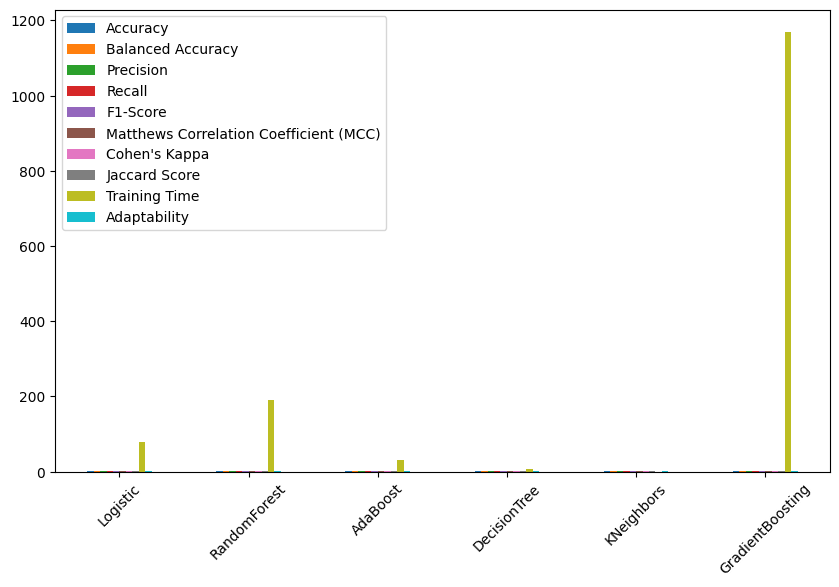

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
import time
from sklearn.ensemble import AdaBoostClassifier, GradientBoostingClassifier, RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn import svm
from sklearn.metrics import balanced_accuracy_score, cohen_kappa_score, jaccard_score, matthews_corrcoef, auc


def eval_model(y_true: np.ndarray, y_pred: np.ndarray) -> float:
    return{
        "Accuracy": accuracy_score(y_true, y_pred),
        "Balanced Accuracy": balanced_accuracy_score(y_true, y_pred),
        "Precision": precision_score(y_true, y_pred, average='weighted', zero_division=0),
        "Recall": recall_score(y_true, y_pred, average='weighted', zero_division=0),
        "F1-Score": f1_score(y_true, y_pred, average='weighted'),
        "Matthews Correlation Coefficient (MCC)": matthews_corrcoef(y_true, y_pred),
        "Cohen's Kappa": cohen_kappa_score(y_true, y_pred),
        "Jaccard Score": jaccard_score(y_true, y_pred, average='weighted')    }

def train_model(model, X_train: pd.DataFrame, y_train: pd.Series, X_test: pd.DataFrame, y_test: pd.Series) -> dict:
    start_time = time.time()
    model.fit(X_train, y_train)
    end_time = time.time()
    y_pred = model.predict(X_test)
    eval_metrics = eval_model(y_test, y_pred)
    eval_metrics["Training Time"] = end_time - start_time
    eval_metrics["Adaptability"] = model.score(X_test, y_test)
    return eval_metrics

models = [#svm.SVC(kernel='rbf'),
          LogisticRegression(max_iter = 1000),
          RandomForestClassifier(n_estimators=200, random_state=0),
          AdaBoostClassifier(random_state = 0),
          DecisionTreeClassifier(random_state=0),
          KNeighborsClassifier(),
          GradientBoostingClassifier(random_state=0)]

classifiers = [#'RadialSVM',
               'Logistic',  'RandomForest',
               'AdaBoost',  'DecisionTree',
               'KNeighbors','GradientBoosting']

def main_train(X_train,X_test,Y_train,Y_test):
    j = 0
    metrics = {}
    for i in models:
        print(f'current classifier: {classifiers[j]}')
        model_results = train_model(i,X_train,Y_train,X_test,Y_test)
        print(model_results)
        metrics[classifiers[j]] = model_results
        j = j+1
    return metrics

metrics = main_train(X_train,X_test,y_train,y_test)
metrics = pd.DataFrame(metrics)
metrics.to_excel('metrics.xlsx')

# plot results
fig, ax = plt.subplots(figsize=(10, 6))
metrics.T.plot(kind='bar', ax=ax)
plt.xticks(rotation=45)
plt.show()

# download metrics.xlsx
from google.colab import files
files.download('metrics.xlsx')

# __Model Training (Neural Networks FF)__




In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
from sklearn.metrics import accuracy_score, balanced_accuracy_score, precision_score, recall_score, f1_score, matthews_corrcoef, cohen_kappa_score, jaccard_score, roc_auc_score
import time
import pandas as pd
from torch.utils.data import DataLoader, TensorDataset

# Define evaluation metrics
def eval_model(y_true: np.ndarray, y_pred: np.ndarray) -> dict:
    return {
        "Accuracy": accuracy_score(y_true, y_pred),
        "Balanced Accuracy": balanced_accuracy_score(y_true, y_pred),
        "Precision": precision_score(y_true, y_pred, average='weighted', zero_division=0),
        "Recall": recall_score(y_true, y_pred, average='weighted', zero_division=0),
        "F1-Score": f1_score(y_true, y_pred, average='weighted'),
        "Matthews Correlation Coefficient (MCC)": matthews_corrcoef(y_true, y_pred),
        "Cohen's Kappa": cohen_kappa_score(y_true, y_pred),
        "Jaccard Score": jaccard_score(y_true, y_pred, average='weighted'),
    }

# Define the neural network model
class NeuralNetwork(nn.Module):
    def __init__(self, input_size, num_classes):
        super(NeuralNetwork, self).__init__()
        self.fc1 = nn.Linear(input_size, 128)
        self.relu = nn.ReLU()
        self.fc2 = nn.Linear(128, 64)
        self.fc3 = nn.Linear(64, num_classes)
        self.softmax = nn.Softmax(dim=1)

    def forward(self, x):
        x = self.fc1(x)
        x = self.relu(x)
        x = self.fc2(x)
        x = self.relu(x)
        x = self.fc3(x)
        x = self.softmax(x)
        return x

# Training loop
def train_loop(model, dataloader, criterion, optimizer, device):
    model.train()
    running_loss = 0.0
    for inputs, targets in dataloader:
        inputs, targets = inputs.to(device), targets.to(device)

        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, targets)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()
    return running_loss / len(dataloader)

# Testing loop
def test_loop(model, dataloader, device):
    model.eval()
    all_preds = []
    all_targets = []
    with torch.no_grad():
        for inputs, targets in dataloader:
            inputs, targets = inputs.to(device), targets.to(device)
            outputs = model(inputs)
            _, preds = torch.max(outputs, 1)
            all_preds.extend(preds.cpu().numpy())
            all_targets.extend(targets.cpu().numpy())
    return np.array(all_targets), np.array(all_preds)

# Train and evaluate function
def train_model(X_train: pd.DataFrame, y_train: pd.Series, X_test: pd.DataFrame, y_test: pd.Series) -> dict:
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

    # Prepare data
    X_train_tensor = torch.tensor(X_train.values, dtype=torch.float32)
    y_train_tensor = torch.tensor(y_train.values, dtype=torch.long)
    X_test_tensor = torch.tensor(X_test.values, dtype=torch.float32)
    y_test_tensor = torch.tensor(y_test.values, dtype=torch.long)

    train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
    test_dataset = TensorDataset(X_test_tensor, y_test_tensor)

    train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
    test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

    # Model setup
    input_size = X_train.shape[1]
    num_classes = len(y_train.unique())
    model = NeuralNetwork(input_size=X_train.shape[1],num_classes=len(y_train.unique())).to(device)

    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=0.001)

    # Training
    start_time = time.time()
    for epoch in range(10):
        train_loss = train_loop(model, train_loader, criterion, optimizer, device)
    end_time = time.time()

    # Testing
    y_true, y_pred = test_loop(model, test_loader, device)

    # Evaluation metrics
    eval_metrics = eval_model(y_true, y_pred)
    eval_metrics["Training Time"] = end_time - start_time

    return eval_metrics

# funcaton calls
metrics = train_model(X_train, y_train, X_test, y_test)

In [ ]:
metrics = pd.DataFrame(metrics, index=[0])
metrics.to_excel('metrics_nn.xlsx')

# download metrics_nn.xlsx
from google.colab import files
files.download('metrics_nn.xlsx')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

# __Model Training (Convolutional neural network CNN)__




In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
from sklearn.metrics import accuracy_score, balanced_accuracy_score, precision_score, recall_score, f1_score, matthews_corrcoef, cohen_kappa_score, jaccard_score
import time
import pandas as pd
from torch.utils.data import DataLoader, TensorDataset

# Define evaluation metrics
def eval_model(y_true: np.ndarray, y_pred: np.ndarray) -> dict:
    return {
        "Accuracy": accuracy_score(y_true, y_pred),
        "Balanced Accuracy": balanced_accuracy_score(y_true, y_pred),
        "Precision": precision_score(y_true, y_pred, average='weighted', zero_division=0),
        "Recall": recall_score(y_true, y_pred, average='weighted', zero_division=0),
        "F1-Score": f1_score(y_true, y_pred, average='weighted'),
        "Matthews Correlation Coefficient (MCC)": matthews_corrcoef(y_true, y_pred),
        "Cohen's Kappa": cohen_kappa_score(y_true, y_pred),
        "Jaccard Score": jaccard_score(y_true, y_pred, average='weighted'),
    }

# Define the CNN model
class CNN(nn.Module):
    def __init__(self, input_channels, num_classes):
        super(CNN, self).__init__()
        self.conv1 = nn.Conv2d(input_channels, 32, kernel_size=3, stride=1, padding=1)
        self.relu = nn.ReLU()
        self.pool = nn.MaxPool2d(kernel_size=2, stride=2)
        self.conv2 = nn.Conv2d(32, 64, kernel_size=3, stride=1, padding=1)
        self.fc1 = nn.Linear(64, 128)
        self.fc2 = nn.Linear(128, num_classes)
        self.softmax = nn.Softmax(dim=1)

    def forward(self, x):
        x = self.conv1(x)
        x = self.relu(x)
        x = self.pool(x)
        x = self.conv2(x)
        x = self.relu(x)
        x = self.pool(x)
        x = x.view(x.size(0), -1)
        x = self.fc1(x)
        x = self.relu(x)
        x = self.fc2(x)
        x = self.softmax(x)
        return x

# Training loop
def train_loop(model, dataloader, criterion, optimizer, device):
    model.train()
    running_loss = 0.0
    for inputs, targets in dataloader:
        inputs, targets = inputs.to(device), targets.to(device)

        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, targets)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()
    return running_loss / len(dataloader)

# Testing loop
def test_loop(model, dataloader, device):
    model.eval()
    all_preds = []
    all_targets = []
    with torch.no_grad():
        for inputs, targets in dataloader:
            inputs, targets = inputs.to(device), targets.to(device)
            outputs = model(inputs)
            _, preds = torch.max(outputs, 1)
            all_preds.extend(preds.cpu().numpy())
            all_targets.extend(targets.cpu().numpy())
    return np.array(all_targets), np.array(all_preds)

# Train and evaluate function
def train_model(X_train: pd.DataFrame, y_train: pd.Series, X_test: pd.DataFrame, y_test: pd.Series) -> dict:
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

    # Reshape data to match CNN input
    X_train_tensor = torch.tensor(X_train.values, dtype=torch.float32).view(-1, 1, 5, 5)
    y_train_tensor = torch.tensor(y_train.values, dtype=torch.long)
    X_test_tensor = torch.tensor(X_test.values, dtype=torch.float32).view(-1, 1, 5, 5)
    y_test_tensor = torch.tensor(y_test.values, dtype=torch.long)

    train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
    test_dataset = TensorDataset(X_test_tensor, y_test_tensor)

    train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
    test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

    # Model setup
    input_channels = 1  # grayscale images
    num_classes = len(y_train.unique())
    model = CNN(input_channels, num_classes).to(device)

    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=0.001)

    # Training
    start_time = time.time()
    for epoch in range(10):
        train_loss = train_loop(model, train_loader, criterion, optimizer, device)
    end_time = time.time()

    # Testing
    y_true, y_pred = test_loop(model, test_loader, device)

    # Evaluation metrics
    eval_metrics = eval_model(y_true, y_pred)
    eval_metrics["Training Time"] = end_time - start_time

    return eval_metrics

metrics = train_model(X_train, y_train, X_test, y_test)
metrics = pd.DataFrame(metrics, index=[0])
metrics.to_excel('metrics_cnn.xlsx')

# download metrics_cnn
from google.colab import files
files.download('metrics_cnn.xlsx')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

# __Model Training (Recurrent neural network RNN)__




In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
from sklearn.metrics import accuracy_score, balanced_accuracy_score, precision_score, recall_score, f1_score, matthews_corrcoef, cohen_kappa_score, jaccard_score
import time
import pandas as pd
from torch.utils.data import DataLoader, TensorDataset

# Define evaluation metrics
def eval_model(y_true: np.ndarray, y_pred: np.ndarray) -> dict:
    return {
        "Accuracy": accuracy_score(y_true, y_pred),
        "Balanced Accuracy": balanced_accuracy_score(y_true, y_pred),
        "Precision": precision_score(y_true, y_pred, average='weighted', zero_division=0),
        "Recall": recall_score(y_true, y_pred, average='weighted', zero_division=0),
        "F1-Score": f1_score(y_true, y_pred, average='weighted'),
        "Matthews Correlation Coefficient (MCC)": matthews_corrcoef(y_true, y_pred),
        "Cohen's Kappa": cohen_kappa_score(y_true, y_pred),
        "Jaccard Score": jaccard_score(y_true, y_pred, average='weighted'),
    }

# Define the LSTM model
class LSTMModel(nn.Module):
    def __init__(self, input_size, hidden_size, num_layers, num_classes):
        super(LSTMModel, self).__init__()
        self.lstm = nn.LSTM(input_size, hidden_size, num_layers, batch_first=True)
        self.fc = nn.Linear(hidden_size, num_classes)

    def forward(self, x):
        h_0 = torch.zeros(self.lstm.num_layers, x.size(0), self.lstm.hidden_size).to(x.device)
        c_0 = torch.zeros(self.lstm.num_layers, x.size(0), self.lstm.hidden_size).to(x.device)
        out, _ = self.lstm(x, (h_0, c_0))
        out = self.fc(out[:, -1, :])
        return out

# Training loop
def train_loop(model, dataloader, criterion, optimizer, device):
    model.train()
    running_loss = 0.0
    for inputs, targets in dataloader:
        inputs, targets = inputs.to(device), targets.to(device)

        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, targets)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()
    return running_loss / len(dataloader)

# Testing loop
def test_loop(model, dataloader, device):
    model.eval()
    all_preds = []
    all_targets = []
    with torch.no_grad():
        for inputs, targets in dataloader:
            inputs, targets = inputs.to(device), targets.to(device)
            outputs = model(inputs)
            _, preds = torch.max(outputs, 1)
            all_preds.extend(preds.cpu().numpy())
            all_targets.extend(targets.cpu().numpy())
    return np.array(all_targets), np.array(all_preds)

# Train and evaluate function
def train_model(X_train: pd.DataFrame, y_train: pd.Series, X_test: pd.DataFrame, y_test: pd.Series) -> dict:
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

    # Reshape data to match LSTM input
    X_train_tensor = torch.tensor(X_train.values, dtype=torch.float32).view(-1, X_train.shape[1], 1)  # [batch_size, seq_len, input_size]
    y_train_tensor = torch.tensor(y_train.values, dtype=torch.long)
    X_test_tensor = torch.tensor(X_test.values, dtype=torch.float32).view(-1, X_test.shape[1], 1)
    y_test_tensor = torch.tensor(y_test.values, dtype=torch.long)

    train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
    test_dataset = TensorDataset(X_test_tensor, y_test_tensor)

    train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
    test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

    # Model setup
    input_size = 1  # Single feature input per timestep
    hidden_size = 64
    num_layers = 2
    num_classes = len(y_train.unique())
    model = LSTMModel(input_size, hidden_size, num_layers, num_classes).to(device)

    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=0.001)

    # Training
    start_time = time.time()
    for epoch in range(10):
        train_loss = train_loop(model, train_loader, criterion, optimizer, device)
    end_time = time.time()

    # Testing
    y_true, y_pred = test_loop(model, test_loader, device)

    # Evaluation metrics
    eval_metrics = eval_model(y_true, y_pred)
    eval_metrics["Training Time"] = end_time - start_time

    return eval_metrics

# funcation calls
metrics = train_model(X_train, y_train, X_test, y_test)


In [ ]:
metrics = pd.DataFrame(metrics, index=[0])
metrics.to_excel('metrics_rnn.xlsx')

# download metrics_rnn
from google.colab import files
files.download('metrics_rnn.xlsx')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
def get_model_complexity(model):
    complexity_metrics = {}

    if hasattr(model, 'n_features_in_'):
        complexity_metrics['n_features'] = model.n_features_in_

    if isinstance(model, LogisticRegression):
        complexity_metrics['penalty'] = model.penalty  # type of regularization
        complexity_metrics['C'] = model.C  # inverse of regularization strength
        complexity_metrics['max_iter'] = model.max_iter  # maximum iterations
        complexity_metrics['n_iter'] = model.n_iter_  # actual number of iterations
        if hasattr(model, 'coef_'):
            complexity_metrics['non_zero_coefficients'] = np.count_nonzero(model.coef_)  # number of non-zero coefficients
            complexity_metrics['model_sparsity'] = 1 - (np.count_nonzero(model.coef_) / model.coef_.size)  # model sparsity

    elif isinstance(model, svm.SVC):
        complexity_metrics['kernel_type'] = model.kernel
        complexity_metrics['C'] = model.C
        if model.kernel == 'rbf':
            complexity_metrics['gamma'] = model.gamma
        elif model.kernel == 'poly':
            complexity_metrics['degree'] = model.degree
        complexity_metrics['n_support_vectors'] = model.n_support_

    elif isinstance(model, RandomForestClassifier):
        complexity_metrics['n_estimators'] = model.n_estimators
        complexity_metrics['max_depth'] = model.max_depth

    elif isinstance(model, GradientBoostingClassifier):
        complexity_metrics['n_estimators'] = model.n_estimators
        complexity_metrics['max_depth'] = model.max_depth

    elif isinstance(model, DecisionTreeClassifier):
        complexity_metrics['max_depth'] = model.max_depth
        complexity_metrics['n_nodes'] = model.tree_.node_count

    elif isinstance(model, KNeighborsClassifier):
        complexity_metrics['n_neighbors'] = model.n_neighbors

    return complexity_metrics


In [ ]:
j = 0
metrics = {}
for i in models:
    print(f'current classifier: {classifiers[j]}')
    model_results = get_model_complexity(i)
    print(model_results)
    metrics[classifiers[j]] = model_results
    j = j+1

print(metrics)

current classifier: Logistic
{'n_features': 25, 'penalty': 'l2', 'C': 1.0, 'max_iter': 1000, 'n_iter': array([573], dtype=int32), 'non_zero_coefficients': 200, 'model_sparsity': 0.0}
current classifier: RandomForest
{'n_features': 25, 'n_estimators': 200, 'max_depth': None}
current classifier: AdaBoost
{'n_features': 25}
current classifier: DecisionTree
{'n_features': 25, 'max_depth': None, 'n_nodes': 29209}
current classifier: KNeighbors
{'n_features': 25, 'n_neighbors': 5}
current classifier: GradientBoosting
{'n_features': 25, 'n_estimators': 100, 'max_depth': 3}
{'Logistic': {'n_features': 25, 'penalty': 'l2', 'C': 1.0, 'max_iter': 1000, 'n_iter': array([573], dtype=int32), 'non_zero_coefficients': 200, 'model_sparsity': 0.0}, 'RandomForest': {'n_features': 25, 'n_estimators': 200, 'max_depth': None}, 'AdaBoost': {'n_features': 25}, 'DecisionTree': {'n_features': 25, 'max_depth': None, 'n_nodes': 29209}, 'KNeighbors': {'n_features': 25, 'n_neighbors': 5}, 'GradientBoosting': {'n_fe

In [ ]:
#save metrics in excel
metrics = pd.DataFrame(metrics).T
metrics.to_excel('complexity.xlsx')

# download metrics
from google.colab import files
files.download('complexity.xlsx')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>